<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E8%87%AA%E7%84%B6%E8%A8%80%E8%AA%9E%E5%87%A6%E7%90%86%E2%91%A1%E9%A1%9E%E4%BC%BC%E6%96%87%E6%9B%B8%E3%81%AE%E6%A4%9C%E7%B4%A2_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=#0e89b2>0. ライブラリのインポート</font>

In [ ]:
#必要なライブラリのインストール
!pip install -q janome
!pip install gensim
!pip install japanize_matplotlib
!pip install -q wordcloud
!apt-get -y -qq install fonts-ipafont-gothic
!pip install markovify

In [ ]:
#データ分析ライブラリ
import numpy as np
import pandas as pd

#データ可視化ライブラリ
import matplotlib.pyplot as plt
import japanize_matplotlib

#機械学習ライブラリ
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

#自然言語処理ライブラリ
from janome.tokenizer import Tokenizer
from wordcloud import WordCloud
from gensim.models.word2vec import Word2Vec
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import markovify

#その他
from google.colab import files
from glob import iglob
from tqdm import tqdm

%matplotlib inline

# <font color=#0e89b2>1. 単語と単語の類似度を計算する</font>

## <font color=#0e89b2>1.1 Word2Vecとは？</font>

先ほどもお話したように、<br>
機械学習モデルは数学モデルなので、自然言語をそのまま理解することが出来ません。<br>
<br>
ですので、<font color=#f27405>機械学習モデルで自然言語を扱う際には、色々な工夫が必要</font>になります。<br>
<br>
ここではその一つの方法<font color=#f27405>Word2Vec</font>について学んでいきましょう。<br>
Word2vecとは、文章中の単語を「数値ベクトル」に変換して、その意味を把握する手法です。<br>
<br>
以下の例のように、加算・減算ができるということで大きな注目を集めました。
```
king - man + woman = queen
```

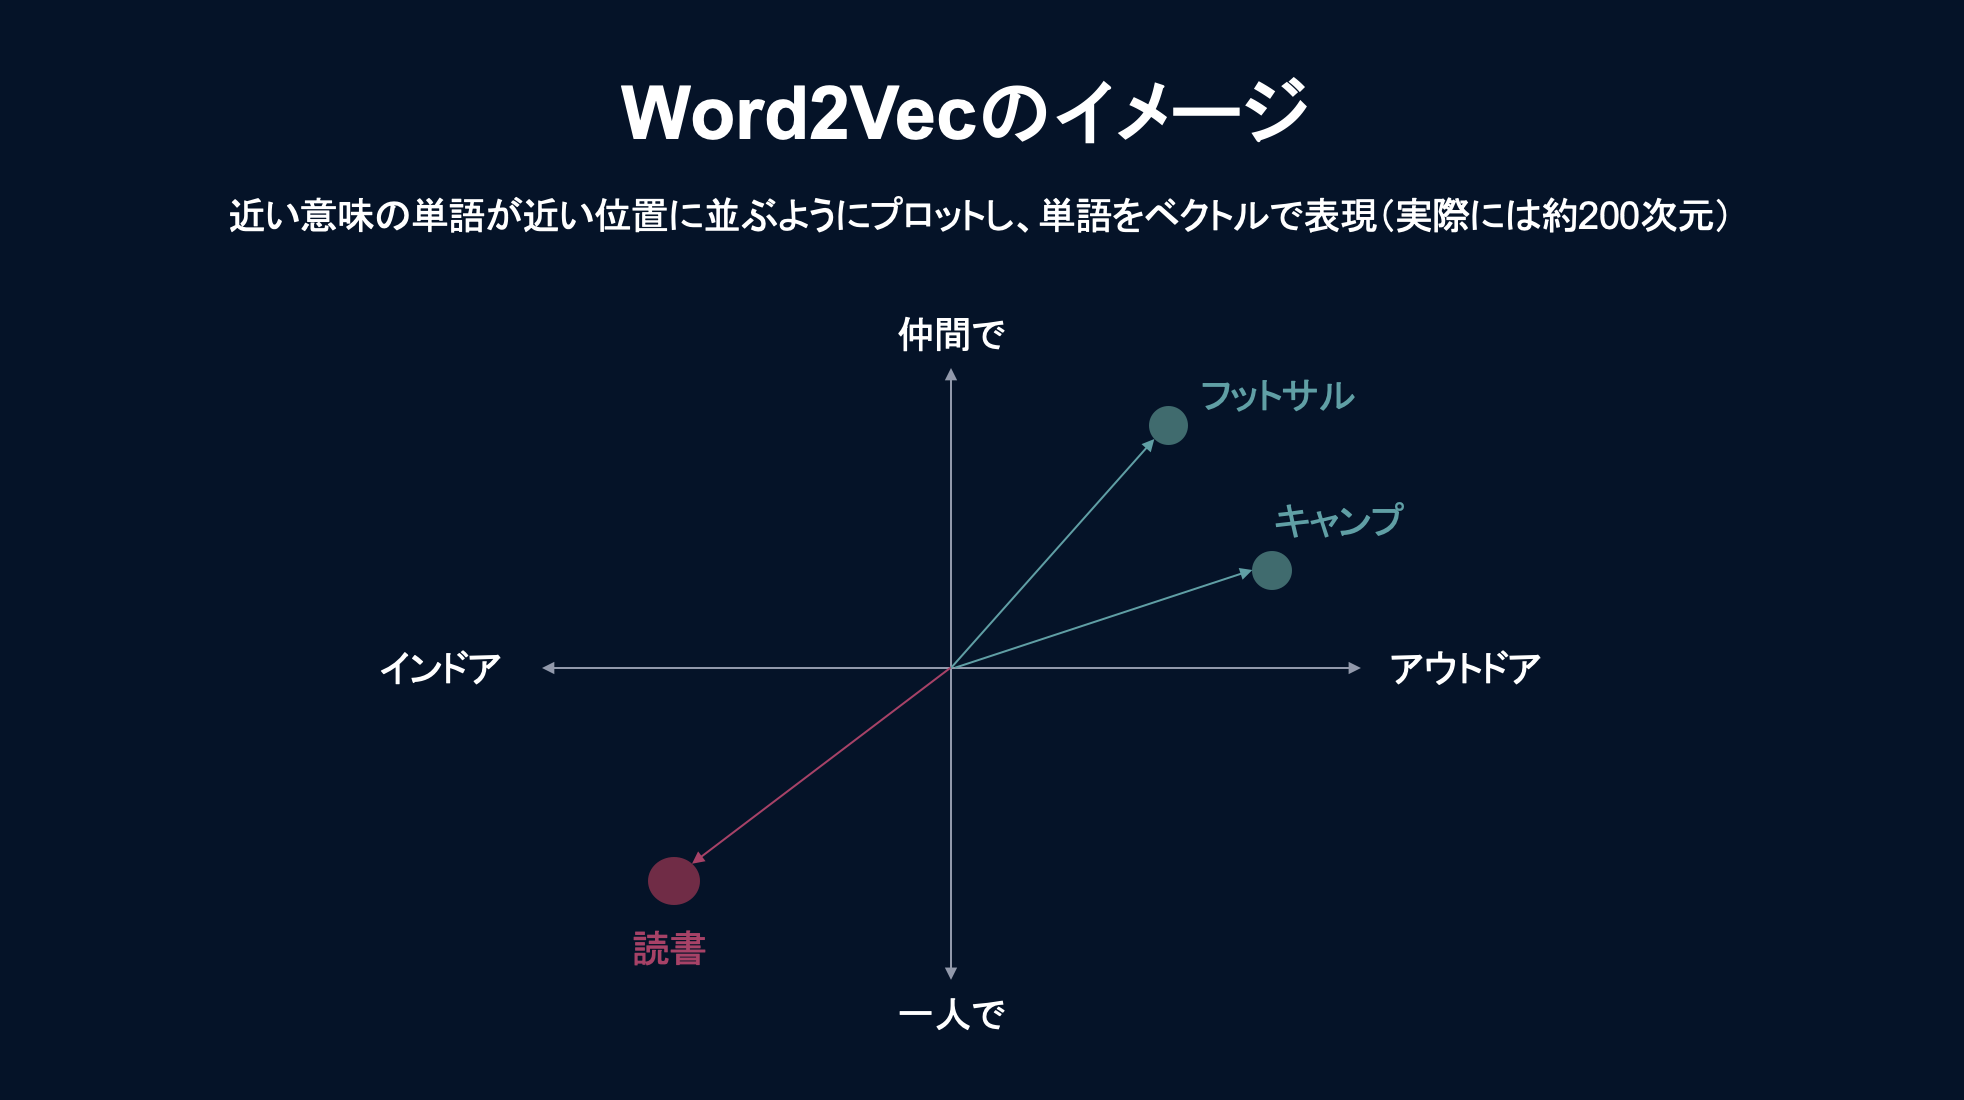

上の図をご覧ください。<br>
ここでは趣味に関する単語を、似た趣味が近い位置に並ぶようにプロットしています。<br>
<br>
この図では分かりやすさのために「仲間で/一人で」「アウトドア/インドア」の2軸で単語を表現しましたが、<br>
実際には下の図のようにおよそ数十から数百次元の数値を使って単語が表現されています。<br>
<br>


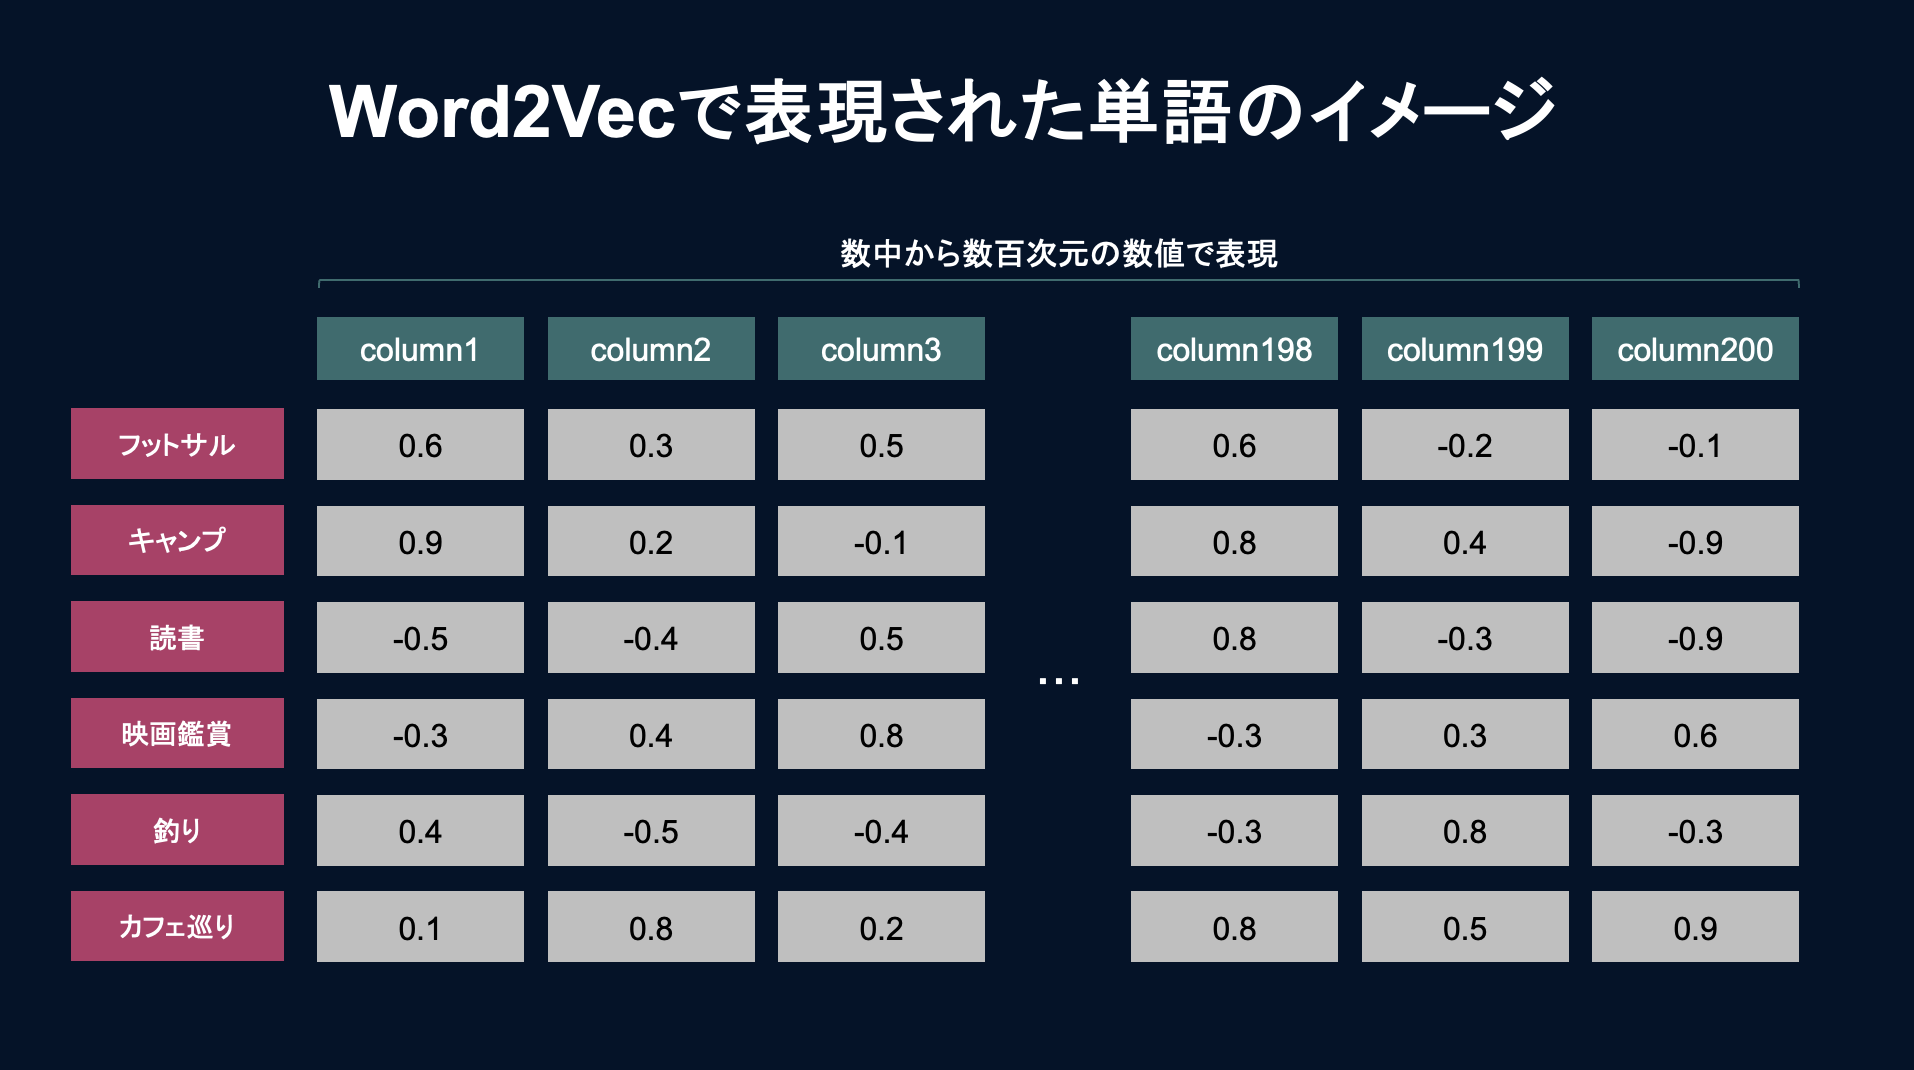

ではどのようにこの数値化を行なっているのでしょうか？<br>
<br>
かなり専門的な内容になりますが、ごく簡単に説明すると、<br>
ある単語について、<font color=#f27405>その前後の単語（5〜15単語程度）が何かによって数値（ベクトル）化</font>しています。<br>

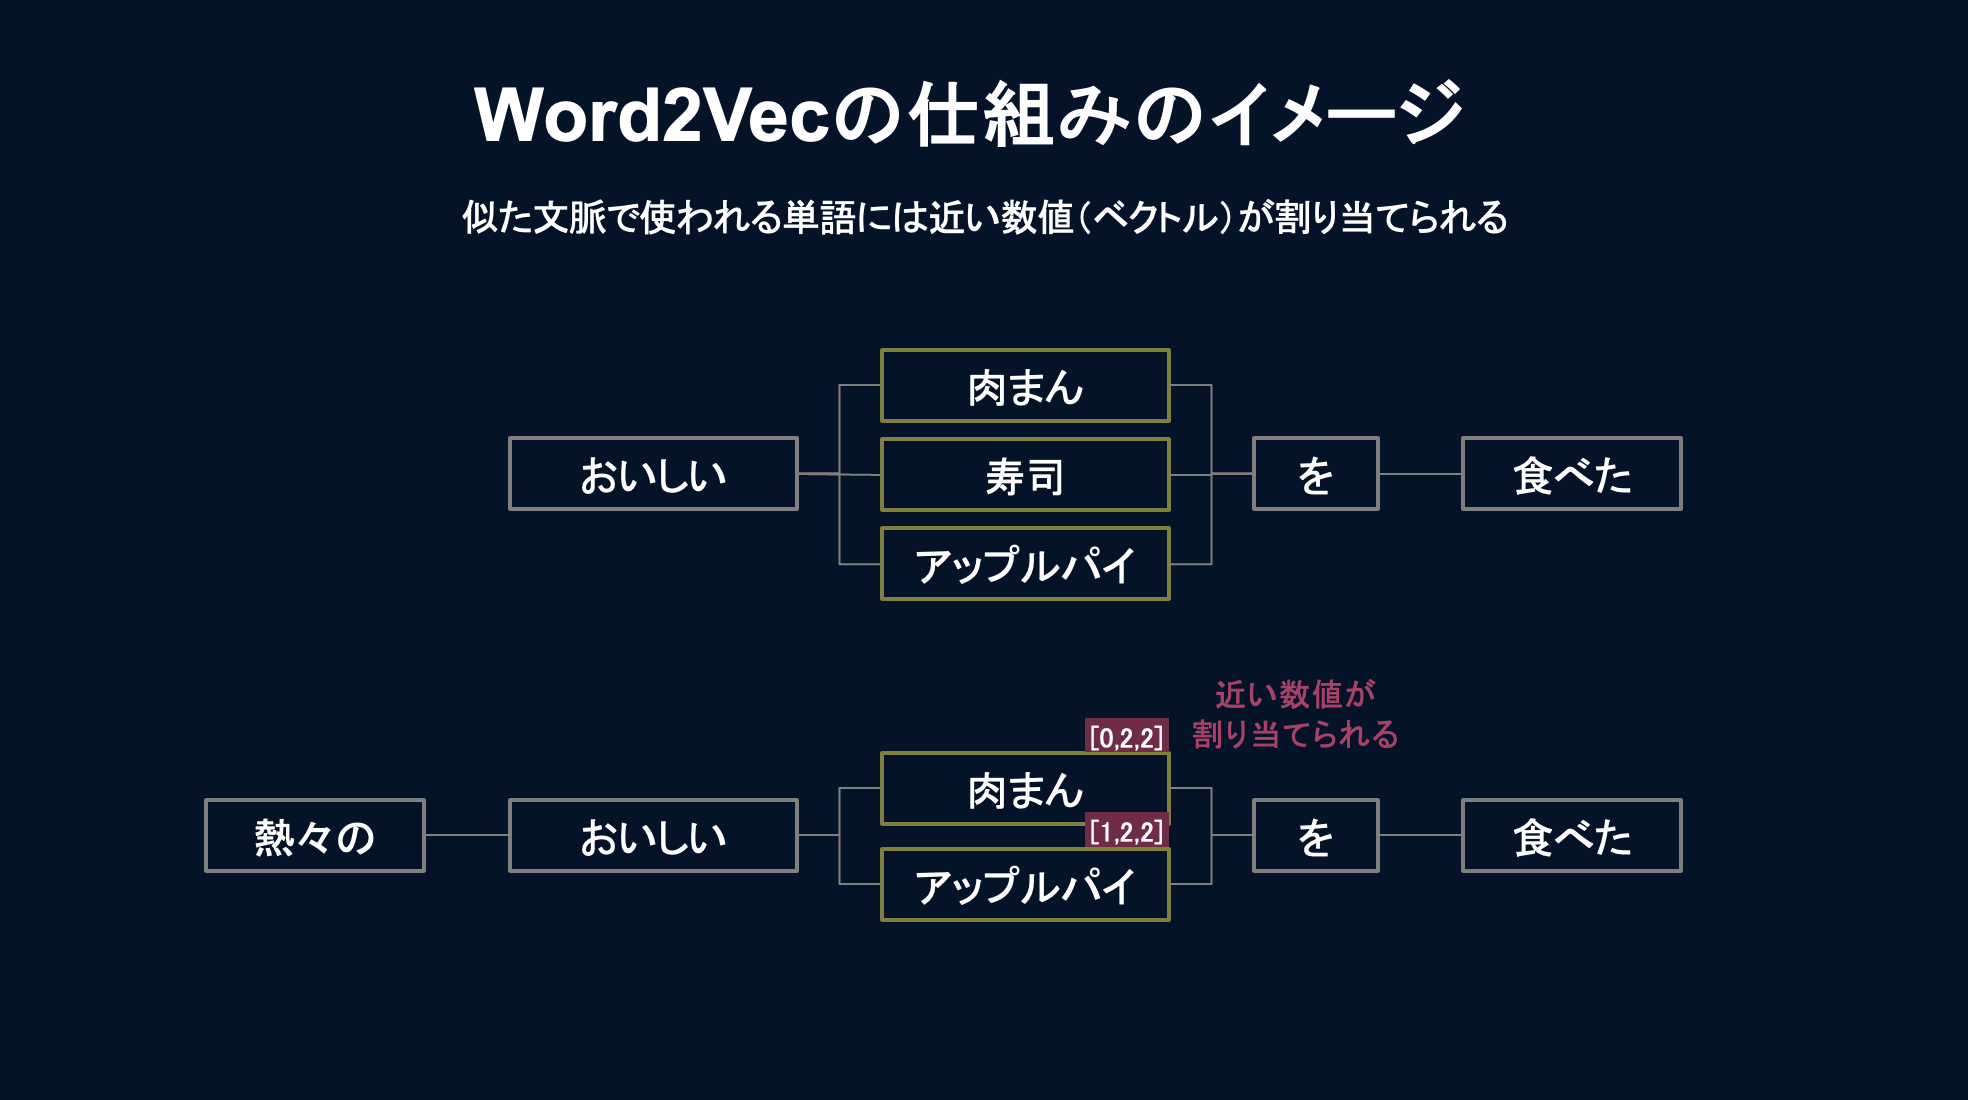

これは、「<font color=#f27405>似たような文脈で使われる単語は、似たような意味だろう</font>」という考え方から来ています。<br>
例えば、
* 「おいしい肉まんを食べた」
* 「おいしい寿司を食べた」
* 「おいしいアップルパイを食べた」

のように、「おいしい」と「食べた」という単語に挟まれる単語は、基本的には「食べ物」という括りで似た単語だと考えられます。<br>
<br>
さらに、<br>
* 「熱々のおいしい肉まんを食べた」
* 「熱々のおいしいアップルパイを食べた」

のように、「熱々の」という単語も加わると、食べ物の中でも温かい状態で食べるものに限定されます。<br>
<br>
この結果、肉まんとアップルパイは近い数値（ベクトル）で、寿司はまあまあ近い数値（ベクトル）で表現されることになります。

## <font color=#0e89b2>1.2 コーパス（モデル）の準備</font>

まずはコーパス（モデル）を準備する必要があります。<br>
大きく2通りの方法があります。
* 自分で準備する
 * Wikipediaや社内データベースなどからテキストデータを収集
* 学習済のものを使う

汎用的なモデルを作りたい場合は作成済のものを使えば良いですが、<br>
自社固有の文脈に沿ったモデルなどを作りたい場合は、自分で準備するようにしましょう。

### <font color=#0e89b2>a. 自分で準備する場合</font>

ここでは作成済みのモデルを使用しますが、参考として自分でモデルを準備する場合の方法も説明しておきます。<br>
<br>
まずテキストデータを準備し、それをわかち書きして"XXX.txt"というファイルを作成します。<br>
そして下記のコードで"XXX.txt"のファイルを読み込んでgensimライブラリのword2vecモジュールで処理すると、<br>
モデルが完成します。<br>
<br>
これ以降（つまりモデル作成後）の処理は、学習済モデルを使う場合と同じです。

In [ ]:
# from gensim.models import word2vec
# import logging

# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
# sentences = word2vec.Text8Corpus('XXX.txt')

# model = word2vec.Word2Vec(sentences, #テキストデータ
#                         min_count=20, #出現回数が20単語以下のものを削除
#                         batch_words=10000,#全文書を10000単語ごとに分割して学習
#                         window=15) #対象とする周辺単語数

# model.save('model/wiki.model') # 学習済みモデルを保存

### <font color=#0e89b2>b. 学習済モデルを使う場合</font>

今回は作成済のものを使いましょう。<br>
ここでは、「Wikipediaエンティティベクトル」というフリーライセンスのコーパスを使用します。<br>
<br>
参考までに、HPのリンクはこちらになります。
http://www.cl.ecei.tohoku.ac.jp/~m-suzuki/jawiki_vector/<br>
<br>
HPからも作成済モデルのファイルをダウンロード出来ますが、<br>
一応こちらのドライブにもファイルを保存しているので、ここからダウンロードしましょう。<br>
（3ファイルあります）<br>
https://drive.google.com/drive/folders/1bIW60KGTIF9016gIarSWGR7y3aV7WUVG?usp=drive_link



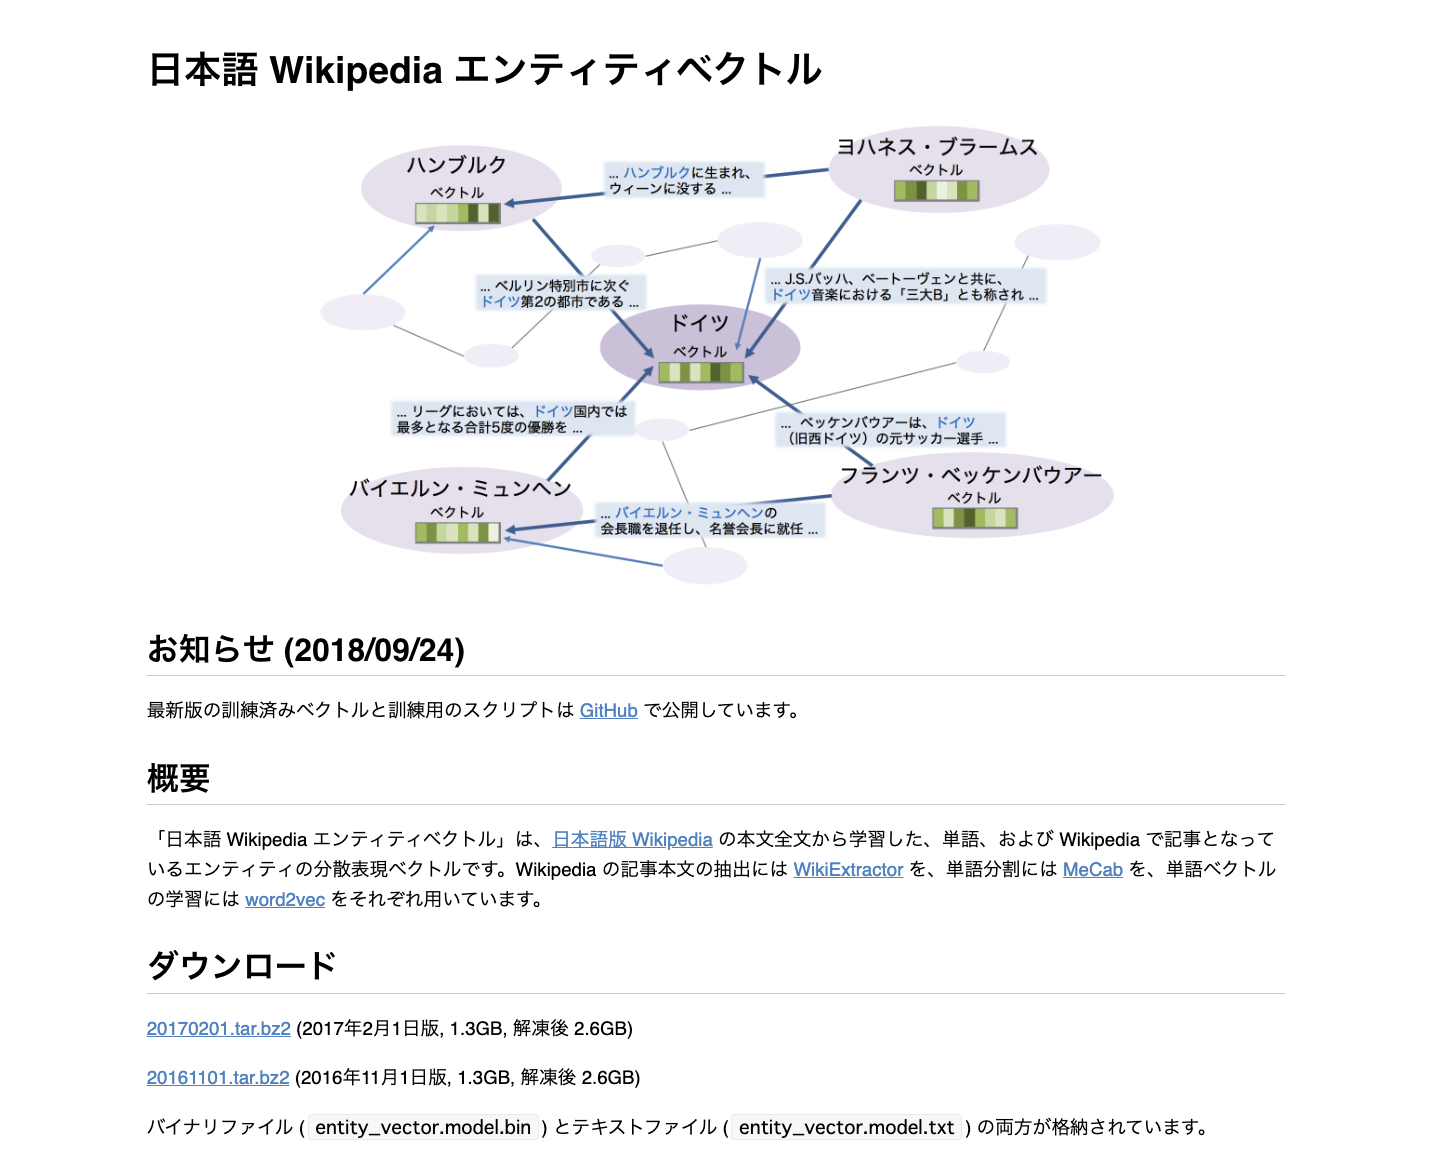

In [ ]:
#!pip install gensim

In [ ]:
#GoogleDriveをマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#####写経#####
from gensim.models.word2vec import Word2Vec
model_path = "/content/drive/MyDrive/AI研修教材/自然言語処理/wikiエンティティ学習済モデル/word2vec.gensim.model" #パスは各自書き換えて下さい
#model_path = "/content/word2vec.gensim.model"
model = Word2Vec.load(model_path)

これでモデルのロードが完了しました。

## <font color=#0e89b2>1.3 単語のベクトルの表示</font>

In [ ]:
#####写経#####
model.wv['幸せ']

array([ 0.09099805, -0.07633652,  0.03948355, -0.18435714,  0.12966146,
       -0.04037728, -0.20526232, -0.0253266 , -0.00656783, -0.2953503 ,
        0.06786092, -0.06437662, -0.10523708, -0.02495888, -0.23632708,
        0.024846  ,  0.10951594, -0.00109521, -0.173201  ,  0.1024622 ,
        0.11456241,  0.16285944,  0.14111708,  0.11185345, -0.16953588,
        0.24413435,  0.01191064,  0.05304954,  0.17816556,  0.0377681 ,
        0.03424606,  0.03286756, -0.12919034, -0.13776907, -0.05537892,
        0.10131617, -0.13506867,  0.2675311 ,  0.05673603, -0.12497   ,
        0.00588474,  0.16399038,  0.06096889,  0.16401958,  0.26403943,
       -0.01379241, -0.0614429 ,  0.39014208,  0.11763158, -0.13681683],
      dtype=float32)

このように、「幸せ」という単語は30次元の数値で表現されていることが分かります。

## <font color=#0e89b2>1.4 単語と単語の類似度を計算する</font>

単語と単語のベクトルを比較することで、類似度を計算することが出来ます。<br>
ここでは、レコメンドのセクションでも出てきた、コサイン類似度の考え方を使っています。

In [ ]:
#####写経#####
model.wv.similarity('企業', '会社')

0.7850749

In [ ]:
#####写経#####
model.wv.similarity('小学校', '中学校')

0.9263048

In [ ]:
#####写経#####
model.wv.similarity('音楽', 'マダガスカル')

0.07938848

In [ ]:
#####写経#####
model.wv.similarity('自由', '幸福')

0.6481799

## <font color=#0e89b2>1.5 類似の単語を調べる</font>

上記のコサイン類似度が高い単語を調べることで、類似単語を見つけることができます。

In [ ]:
#####写経#####
for item, value in model.wv.most_similar('愛'):
    print(item,value)

恋 0.8225170373916626
愛する人 0.7893587946891785
心 0.7886800765991211
慈愛 0.7883978486061096
いのち 0.7858520150184631
永遠 0.7832071185112
絆 0.7775446176528931
天国 0.7699838876724243
哀しみ 0.7637548446655273
想い 0.7605637311935425


In [ ]:
#####写経#####
for item, value in model.wv.most_similar('新幹線'):
    print(item,value)

在来線 0.8819261789321899
東海道新幹線 0.8655878901481628
JR 0.855884313583374
山陽新幹線 0.8416933417320251
通勤電車 0.8341569304466248
東北新幹線 0.8266938924789429
ミニ新幹線 0.8209617137908936
JR線 0.8049229979515076
各線 0.8022627830505371
東海道・山陽新幹線 0.8010534644126892


In [ ]:
#####写経#####
for item, value in model.wv.most_similar('食べる'):
    print(item,value)

食する 0.9049259424209595
食す 0.8963730335235596
飲む 0.8578937649726868
釣る 0.8376770615577698
煮込む 0.8251774311065674
炊く 0.8073770999908447
焼く 0.8069429397583008
吸う 0.8067694902420044
生肉 0.7995699048042297
摂る 0.7906046509742737


## <font color=#0e89b2>1.6 単語で足し算・引き算する</font>

学校＋スポーツ

In [ ]:
#####写経#####
model.wv.most_similar(positive=["学校", "スポーツ"])

[('体育', 0.811292290687561),
 ('クラブ活動', 0.7908893823623657),
 ('フリースクール', 0.7868936657905579),
 ('課外活動', 0.7839668393135071),
 ('スクール', 0.782406210899353),
 ('体操', 0.7783560156822205),
 ('英語教育', 0.7658746838569641),
 ('水泳', 0.7551549673080444),
 ('公立校', 0.746915340423584),
 ('サポート校', 0.7466073632240295)]

居酒屋＋イギリス

In [ ]:
#####写経#####
model.wv.most_similar(positive=["居酒屋", "イギリス"])

[('パブ', 0.7842136025428772),
 ('フィッシュ・アンド・チップス', 0.7743027806282043),
 ('ナイトクラブ', 0.766908586025238),
 ('コーヒーショップ', 0.7456678152084351),
 ('食料品店', 0.7349027395248413),
 ('ダンスホール', 0.7337110042572021),
 ('サヴィル・ロウ', 0.7207404971122742),
 ('ロンドン', 0.7155522108078003),
 ('キャバレー', 0.7109848260879517),
 ('ピザ', 0.7083388566970825)]

俳優ー男性＋女性

In [ ]:
#####写経#####
model.wv.most_similar(positive=["俳優", "女性"],negative=["男性"])

[('女優', 0.8710199594497681),
 ('映画女優', 0.856196939945221),
 ('映画監督', 0.8218217492103577),
 ('脚本家', 0.8143810629844666),
 ('舞台女優', 0.8079578280448914),
 ('演出家', 0.800709068775177),
 ('コメディアン', 0.7912424802780151),
 ('野沢那智', 0.7894102334976196),
 ('子役', 0.7858350276947021),
 ('コメディエンヌ', 0.78541100025177)]

日本ー東京＋パリ

In [ ]:
#####写経#####
model.wv.most_similar(positive=["日本", "パリ"],negative=["東京"])

[('フランス', 0.751153826713562),
 ('イギリス', 0.7338305115699768),
 ('ロシア', 0.721873939037323),
 ('イタリア', 0.7178705334663391),
 ('ノルウェー', 0.7122256755828857),
 ('スウェーデン', 0.7118490934371948),
 ('大英帝国', 0.7043356895446777),
 ('デンマーク', 0.7033933401107788),
 ('オランダ', 0.7019158005714417),
 ('アメリカ', 0.6911695003509521)]

ちなみに、`1単語ー1単語`の引き算はなかなか上手くいきにくいです。<br>
おじさんー男

In [ ]:
model.wv.most_similar(positive=["おじさん"], negative=["男"])

[('色んな', 0.6110038161277771),
 ('懐かし', 0.5967240333557129),
 ('エキサイト', 0.5811030864715576),
 ('EAST END', 0.579785168170929),
 ('カラオケ', 0.5718714594841003),
 ('ピストン西沢', 0.5705085396766663),
 ('ウキウキ', 0.5665894746780396),
 ('スマイル', 0.5660647749900818),
 ('お絵かき', 0.5648121237754822),
 ('踊れる', 0.5647743940353394)]

日本-東京

In [ ]:
model.wv.most_similar(positive=["日本"], negative=["東京"])

[('身体刑', 0.6176180839538574),
 ('動物福祉', 0.5514277219772339),
 ('未承認', 0.5436553359031677),
 ('多かれ', 0.5354097485542297),
 ('前近代', 0.5316018462181091),
 ('旧ソ連', 0.529555082321167),
 ('誇大', 0.5287765264511108),
 ('社会主義国', 0.5261425375938416),
 ('判例法', 0.524651050567627),
 ('食のタブー', 0.5180566310882568)]

牛丼ー牛肉

In [ ]:
model.wv.most_similar(positive=["牛丼"], negative=["牛肉"])

[('歌舞伎町', 0.6631779670715332),
 ('撮', 0.6336652636528015),
 ('ルミネtheよしもと', 0.6283642649650574),
 ('新宿', 0.6215139031410217),
 ('薩摩剣士隼人', 0.6184127330780029),
 ('サザエさん', 0.6138639450073242),
 ('ニコニコ', 0.613303005695343),
 ('やなな', 0.6117241978645325),
 ('寺田貴信', 0.6103222966194153),
 ('伊勢丹', 0.6090356707572937)]

例えば上の例のように、「牛丼」から「牛肉」を引いても、「米」という単語が出てくるようなことは中々ありません。<br>
<br>
これを直感的に説明してみるとこんな感じでしょうか。<br>
例えば「食品」+「食品」は食品になりそうですよね。<br>
一方、「食品」ー「食品」の計算結果はほぼ0となってしまいます。<br>
計算結果がほぼ0になると、一種の判定不能状態となってしまうので、バグった単語が出力されてしまうわけです。

# <font color=#0e89b2>2. 文章と文章の類似度を判定する</font>

## <font color=#0e89b2>2.1 Bag of Wordsとは？</font>

次は、文章と文章の類似度を計算してみましょう。<br>
<br>
ここでは<font color=#f27405>Bag of Words</font>を方法を使います。（前のセクションで出てきましたが、復習しておきましょう。）<br>
Bag of Wordsでは、文章を単語に分割し、それぞれの単語がそれぞれ何回出現したかを数えます。<br>
<br>
単語の順番などは考慮していません。<br>
単語の出現回数をカウントしているだけなので、Word2Vecの時よりも単純なモデルになります。

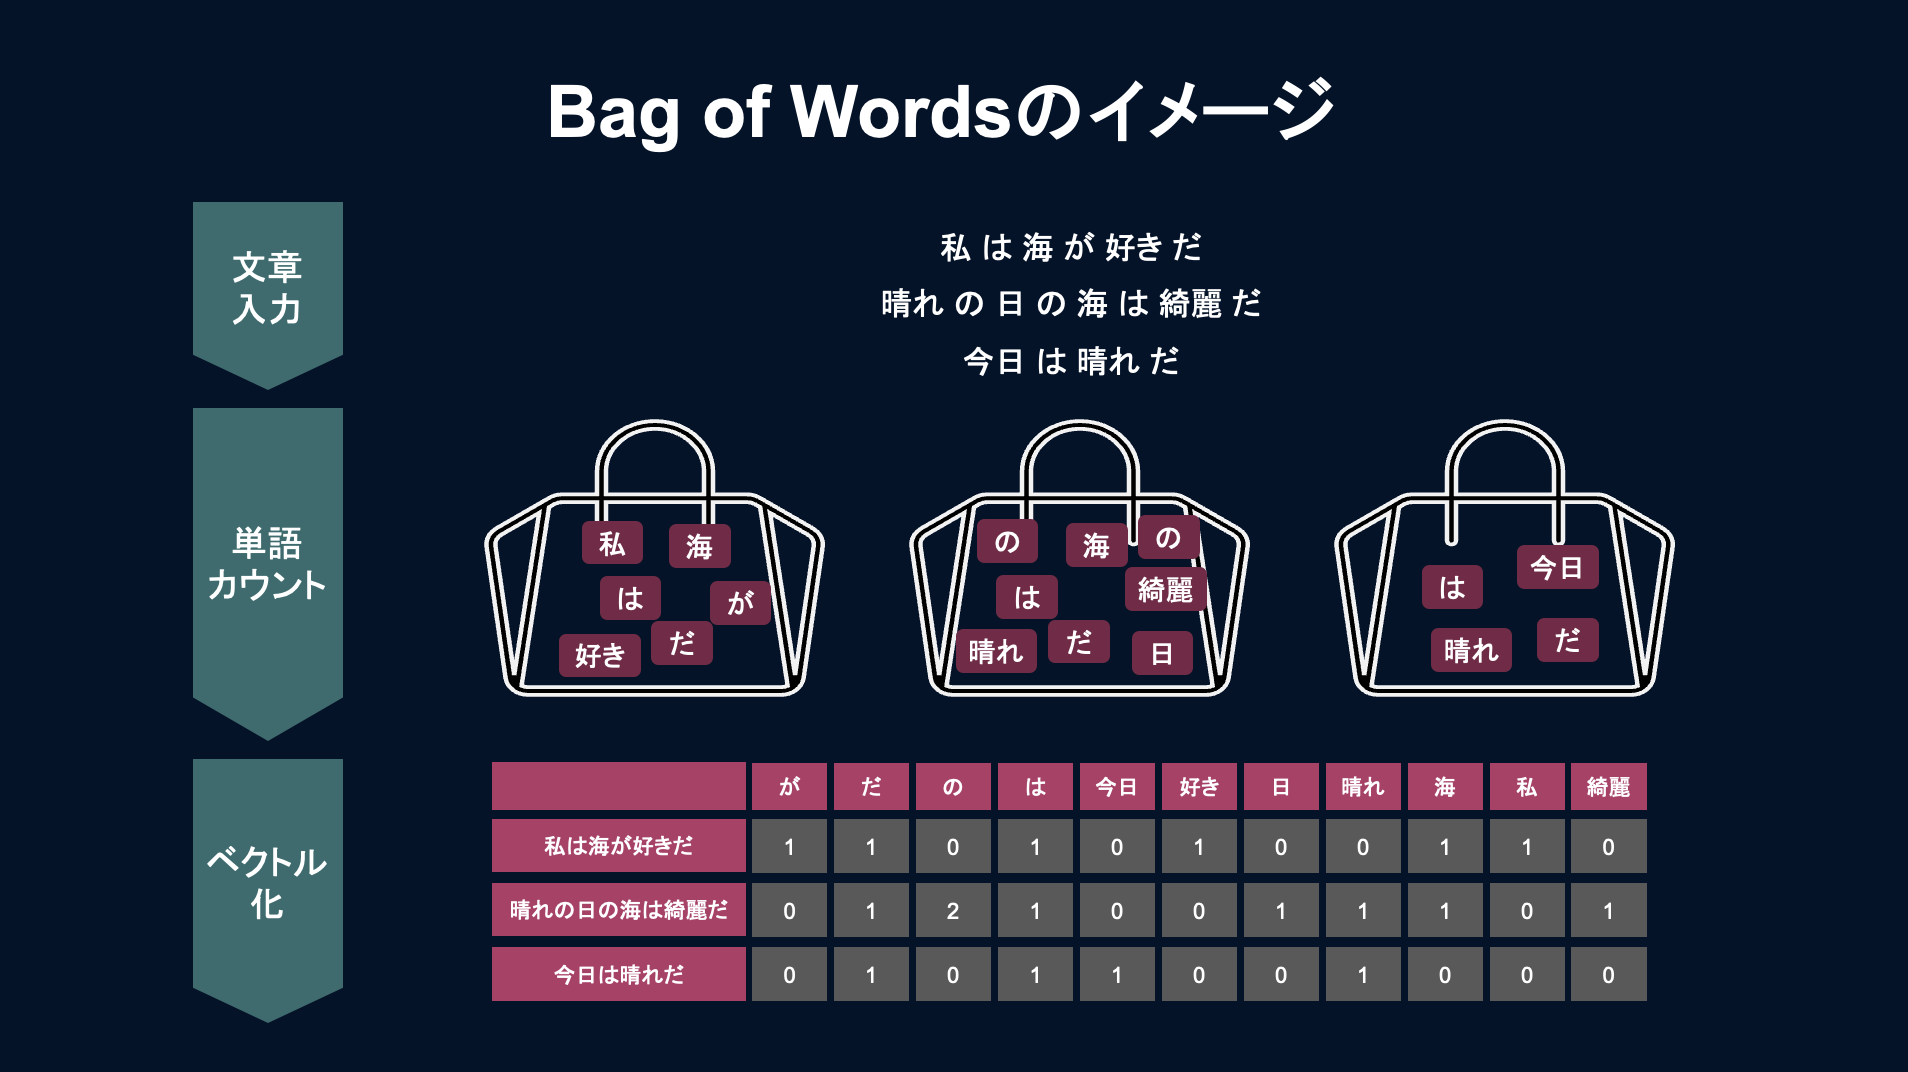

## <font color=#0e89b2>2.2 Bag of Wordsの実装（文章のベクトル化）</font>

まずは必要なライブラリをインポートします。<br>
ここでは、`CountVectorizer`というsklearnのライブラリを使用します。

In [ ]:
# #ライブラリのインポート
# from sklearn.feature_extraction.text import CountVectorizer

次に、ベクトル化したい文章を準備します。

In [ ]:
#入力文章の準備
text = ['今日 の 海 は 綺麗 だ',
        '私 は 海 が 好き だ',
        '晴れ の 日 の 海 は 綺麗 だ',
        '今日 UFO を 見た',
        '昨日 UFO が 現れた',
        '私 は 私 の 事 が 好き　だ']

この文章を、`CountVectorizer`を使ってベクトル化していきましょう。<br>

In [ ]:
#####写経#####
#単語カウンターの作成
count = CountVectorizer(token_pattern=r'[^\s]+') #token_patternは単語の抽出条件。ここでは、スペース以外の文字が1文字以上続いたもの

#文書からBag of Wordsを作成
bow = count.fit_transform(text)

#ベクトル化
vec = bow.toarray()
vec

array([[0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
       [0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0],
       [0, 0, 1, 2, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]])

このように、先ほどの文章がベクトル化されています。<br>
もう少し見やすく出力してみます。

In [ ]:
print('---- 単語リスト ----')
print(sorted(count.vocabulary_.items(), key=lambda x:x[1]))
print('')
print('---- 各文書のベクトル ----')
for i in range(len(text)):
    print(text[i], ':\t', vec[i])

---- 単語リスト ----
[('ufo', 0), ('が', 1), ('だ', 2), ('の', 3), ('は', 4), ('を', 5), ('事', 6), ('今日', 7), ('好き', 8), ('日', 9), ('昨日', 10), ('晴れ', 11), ('海', 12), ('現れた', 13), ('私', 14), ('綺麗', 15), ('見た', 16)]

---- 各文書のベクトル ----
今日 の 海 は 綺麗 だ :	 [0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0]
私 は 海 が 好き だ :	 [0 1 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0]
晴れ の 日 の 海 は 綺麗 だ :	 [0 0 1 2 1 0 0 0 0 1 0 1 1 0 0 1 0]
今日 UFO を 見た :	 [1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1]
昨日 UFO が 現れた :	 [1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
私 は 私 の 事 が 好き　だ :	 [0 1 1 1 1 0 1 0 1 0 0 0 0 0 2 0 0]


無事ベクトル化出来ていることが分かります。<br>
例えば一番下の「私は私が好きだ」という文章では、「私」という単語が2回登場していますが、<br>
13番目（右から3番目）の数値が2になっています。

## <font color=#0e89b2>2.3 練習問題2：文書間の類似度の判定</font>

下記の文書間の類似度をそれぞれ計算して下さい。
* 「今日の海は綺麗だ」と「晴れの日の海は綺麗だ」
* 「私は海が好きだ」と「今日は晴れだ」
* 「今日の海は綺麗だ」と「私は海が好きだ」
* 「私は海が好きだ」と「私は私が好きだ」


なお、文書の類似度の計算の際には、コサイン類似度を用います。<br>
4.2で計算した「各文書のベクトル」と、「レコメンド」の回で学んだ`cosine_similarity`を使いましょう。



解答

In [ ]:
#ライブラリのインポート
from sklearn.metrics.pairwise import cosine_similarity

「今日の海は綺麗だ」と「晴れの日の海は綺麗だ」<br>
（似た話題について話してます）

In [ ]:
cosine_similarity([vec[0]], [vec[2]])

array([[0.77459667]])

「私は海が好きだ」と「今日は晴れだ」<br>
（違う話題について話してます）

In [ ]:
cosine_similarity([vec[1]], [vec[2]])

array([[0.5]])

「今日UFOを見た」と「昨日UFOが現れた」<br>
（似た話題について話してます）

In [ ]:
cosine_similarity([vec[3]], [vec[4]])

array([[0.13363062]])

「私は海が好きだ」と「私は私の事が好きだ」<br>
（まあまあ違う話題について話してます）

In [ ]:
cosine_similarity([vec[1]], [vec[5]])

array([[0.77459667]])

お察しの通り、上の手法はただ単語数をカウントしてるだけなので、以下のような欠点があります。
* 出現数は多いがそれほど重要度は高くない単語の影響力が強い
 * 「私」「好き」など
* 出現数は低いが重要度が高い単語の影響力が弱い
 * 「UFO」など
<br>
<br>

例えば上の例では、「今日UFOを見た」と「昨日UFOが現れた」の文章のペアは、<br>
UFOという特徴的な話題を共通して取り上げているにも関わらず、<br>
「UFO」以外の単語は共通していないので、類似度0.13とかなり低くなっています。<br>
<br>
一方、「私は海が好きだ」と「私は私の事が好きだ」は、<br>
話題としてはまあまあ違うのですが、使っている単語がほぼ同じなので、<br>
類似度は0.77と高くなってしまっています。<br>

## <font color=#0e89b2>2.4 TF-IDFとは？</font>

このような欠点を補うために、TF-IDFという手法を使っていきます。<br>
<br>
TF-IDFでは、単純に各単語の出現回数をカウントするのではなく、<br>
「<font color=#f27405>各単語の重要度</font>」まで表現してベクトル化します。

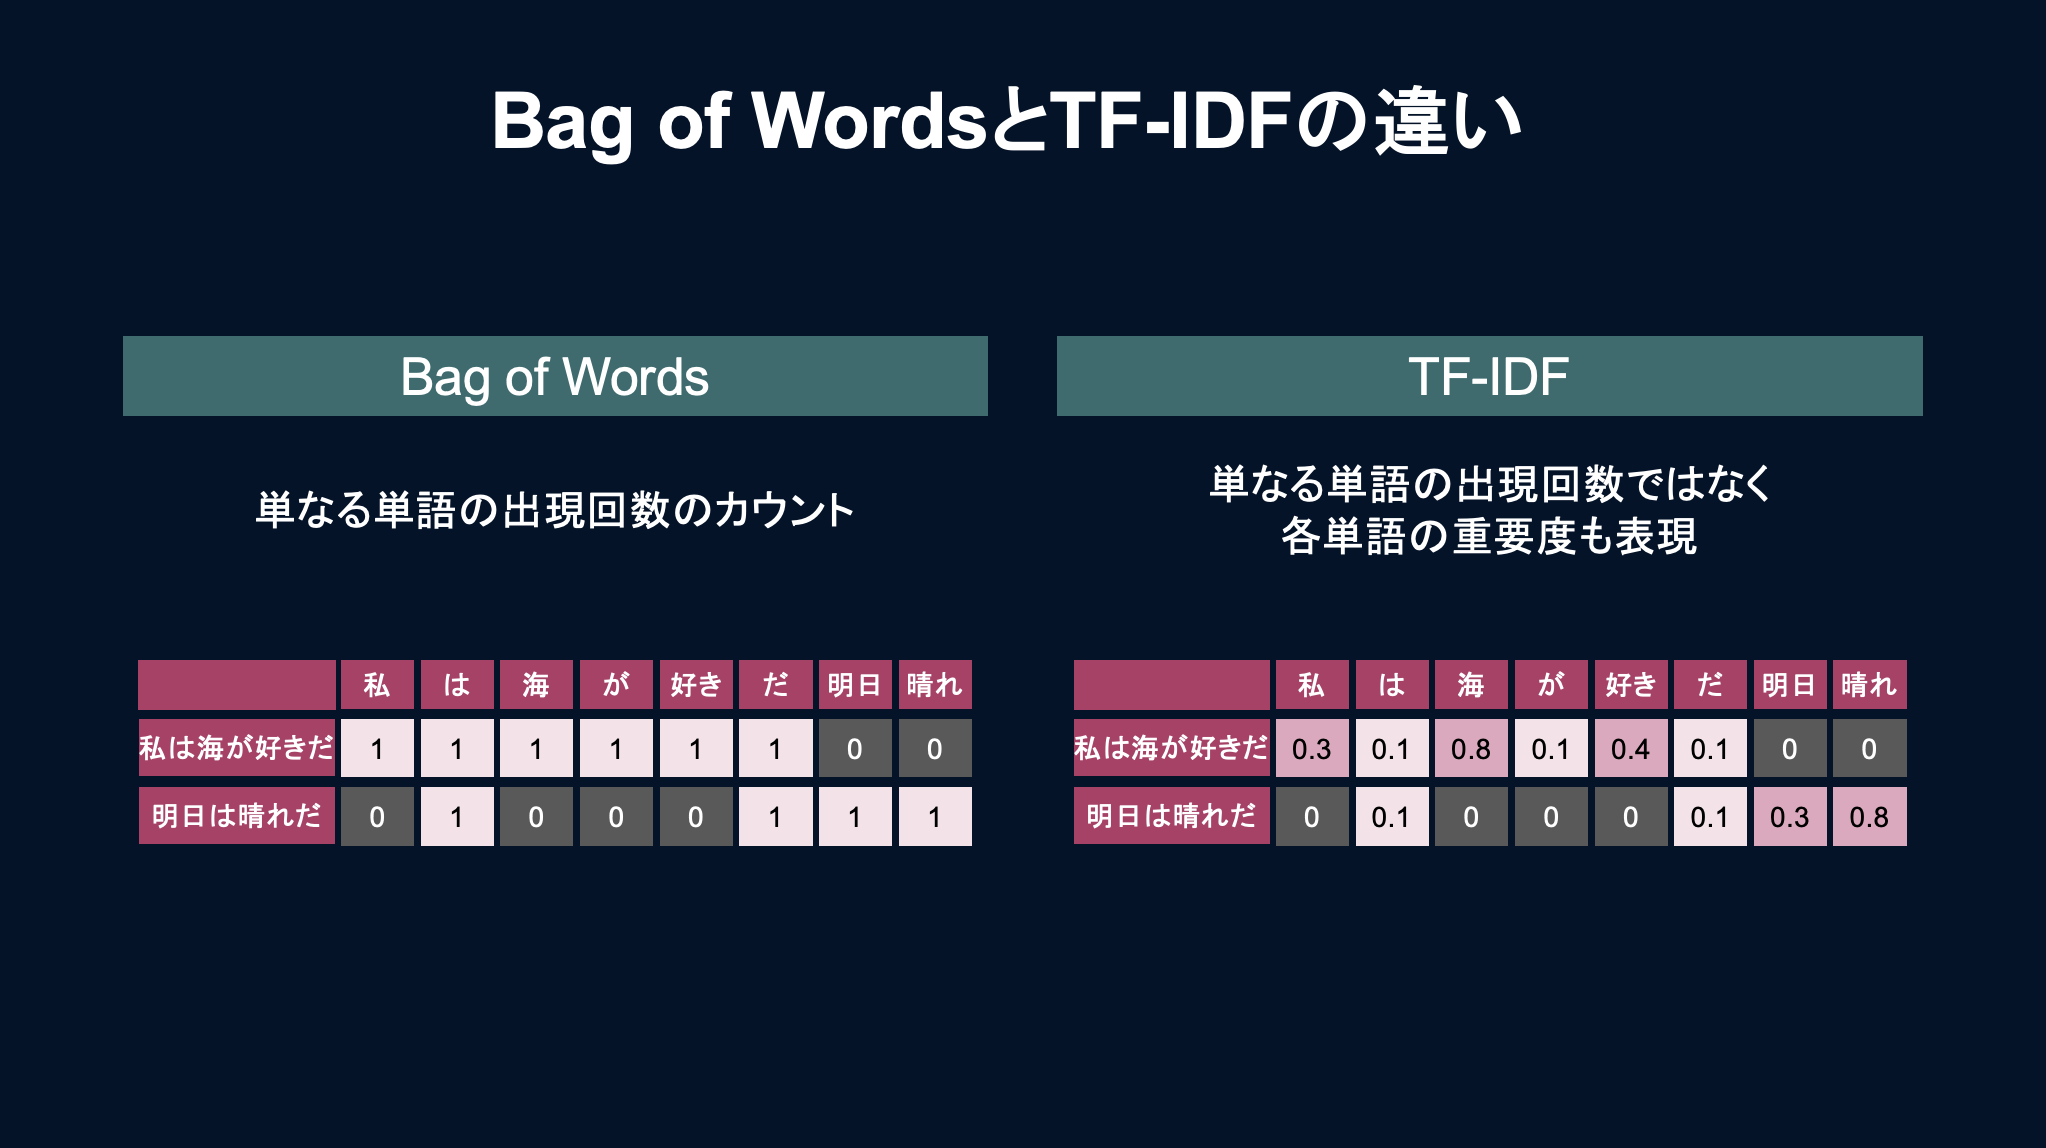

TF-IDFは、図のように、
`TF（その単語の出現頻度）×IDF（その単語のレア度）`
で計算します。<br>
<br>
考え方としては、「あまり普段使われないレアな単語が、その文書の中では何度も登場していたら、<br>
その文書の中でその単語は重要なのだろう」というものです。


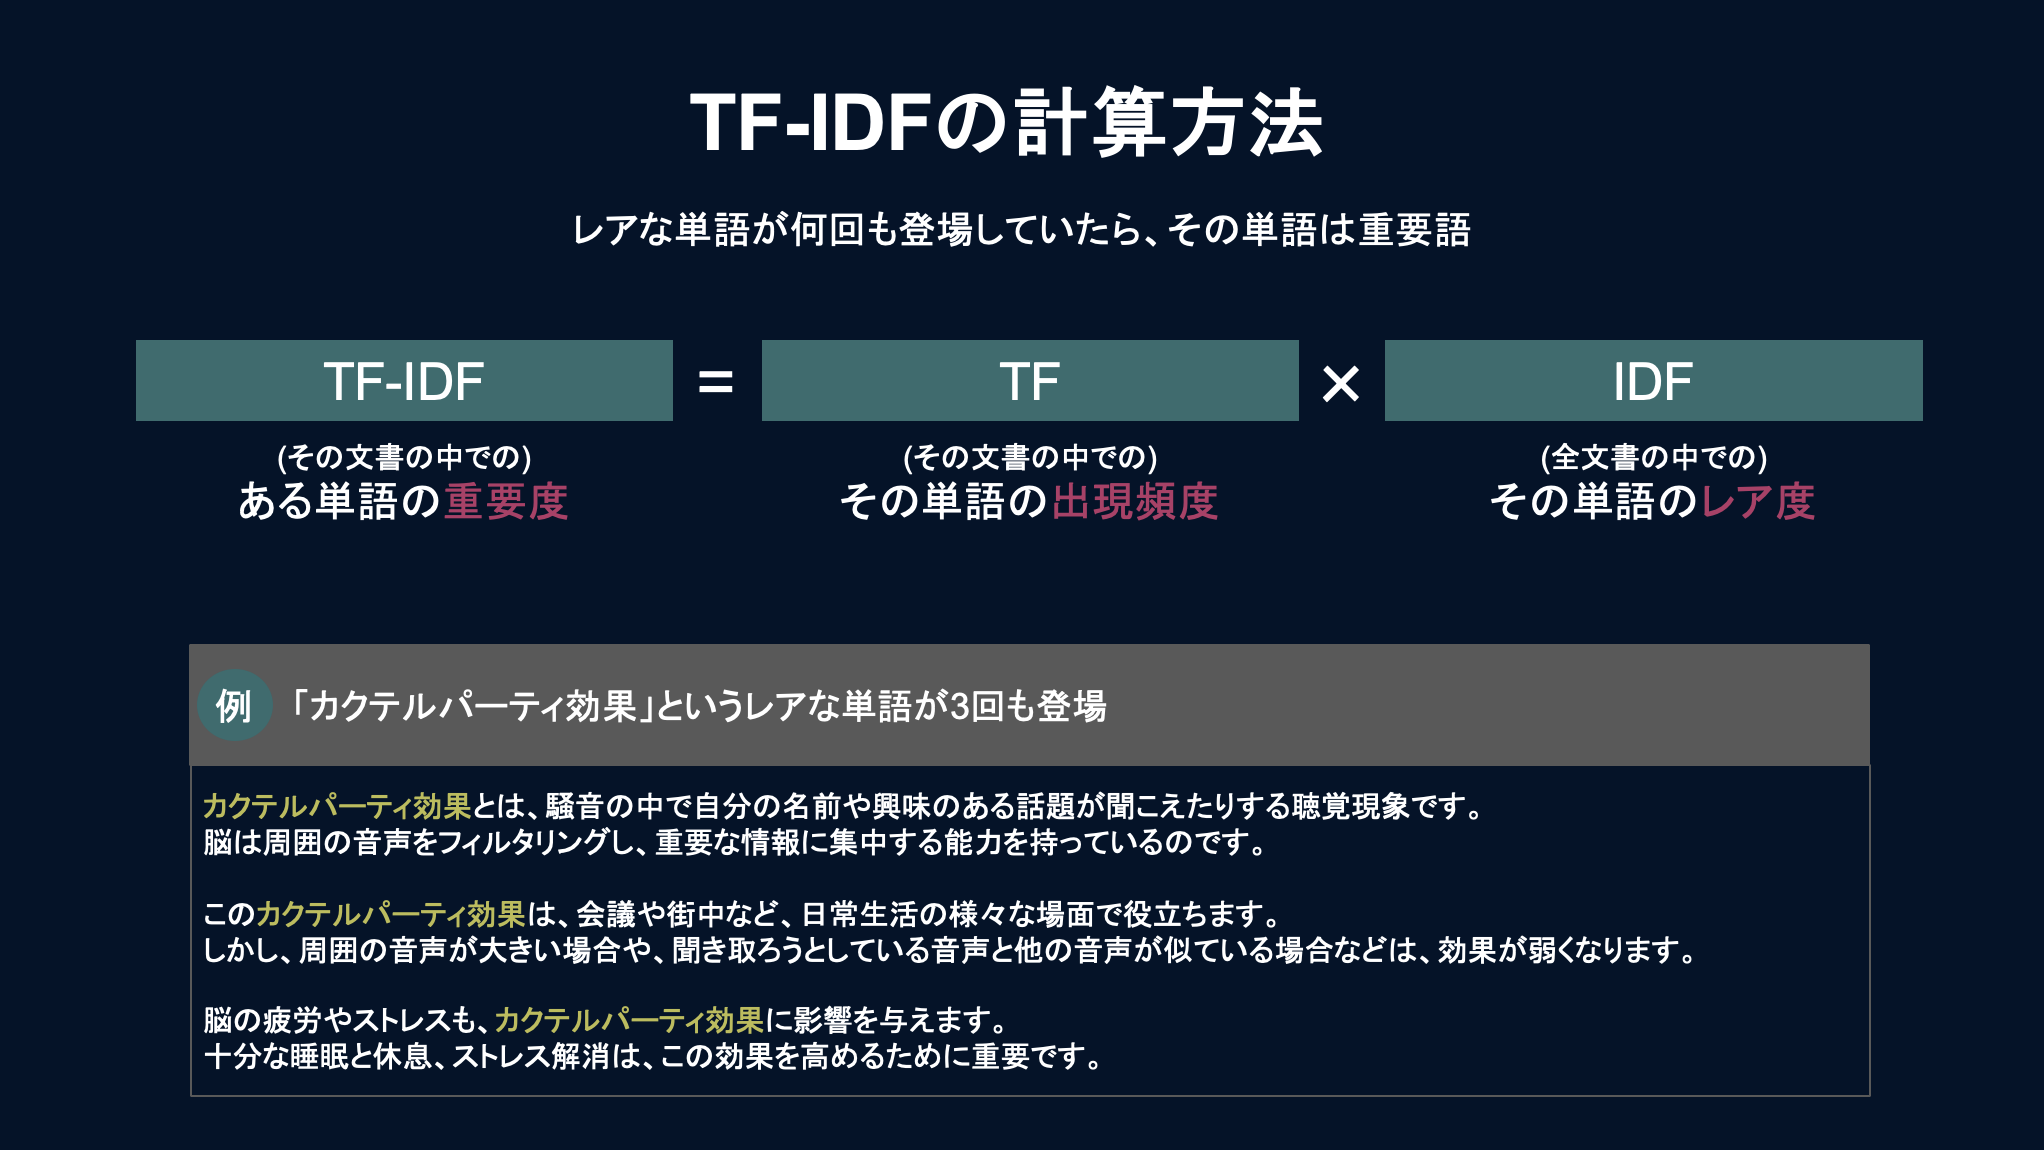

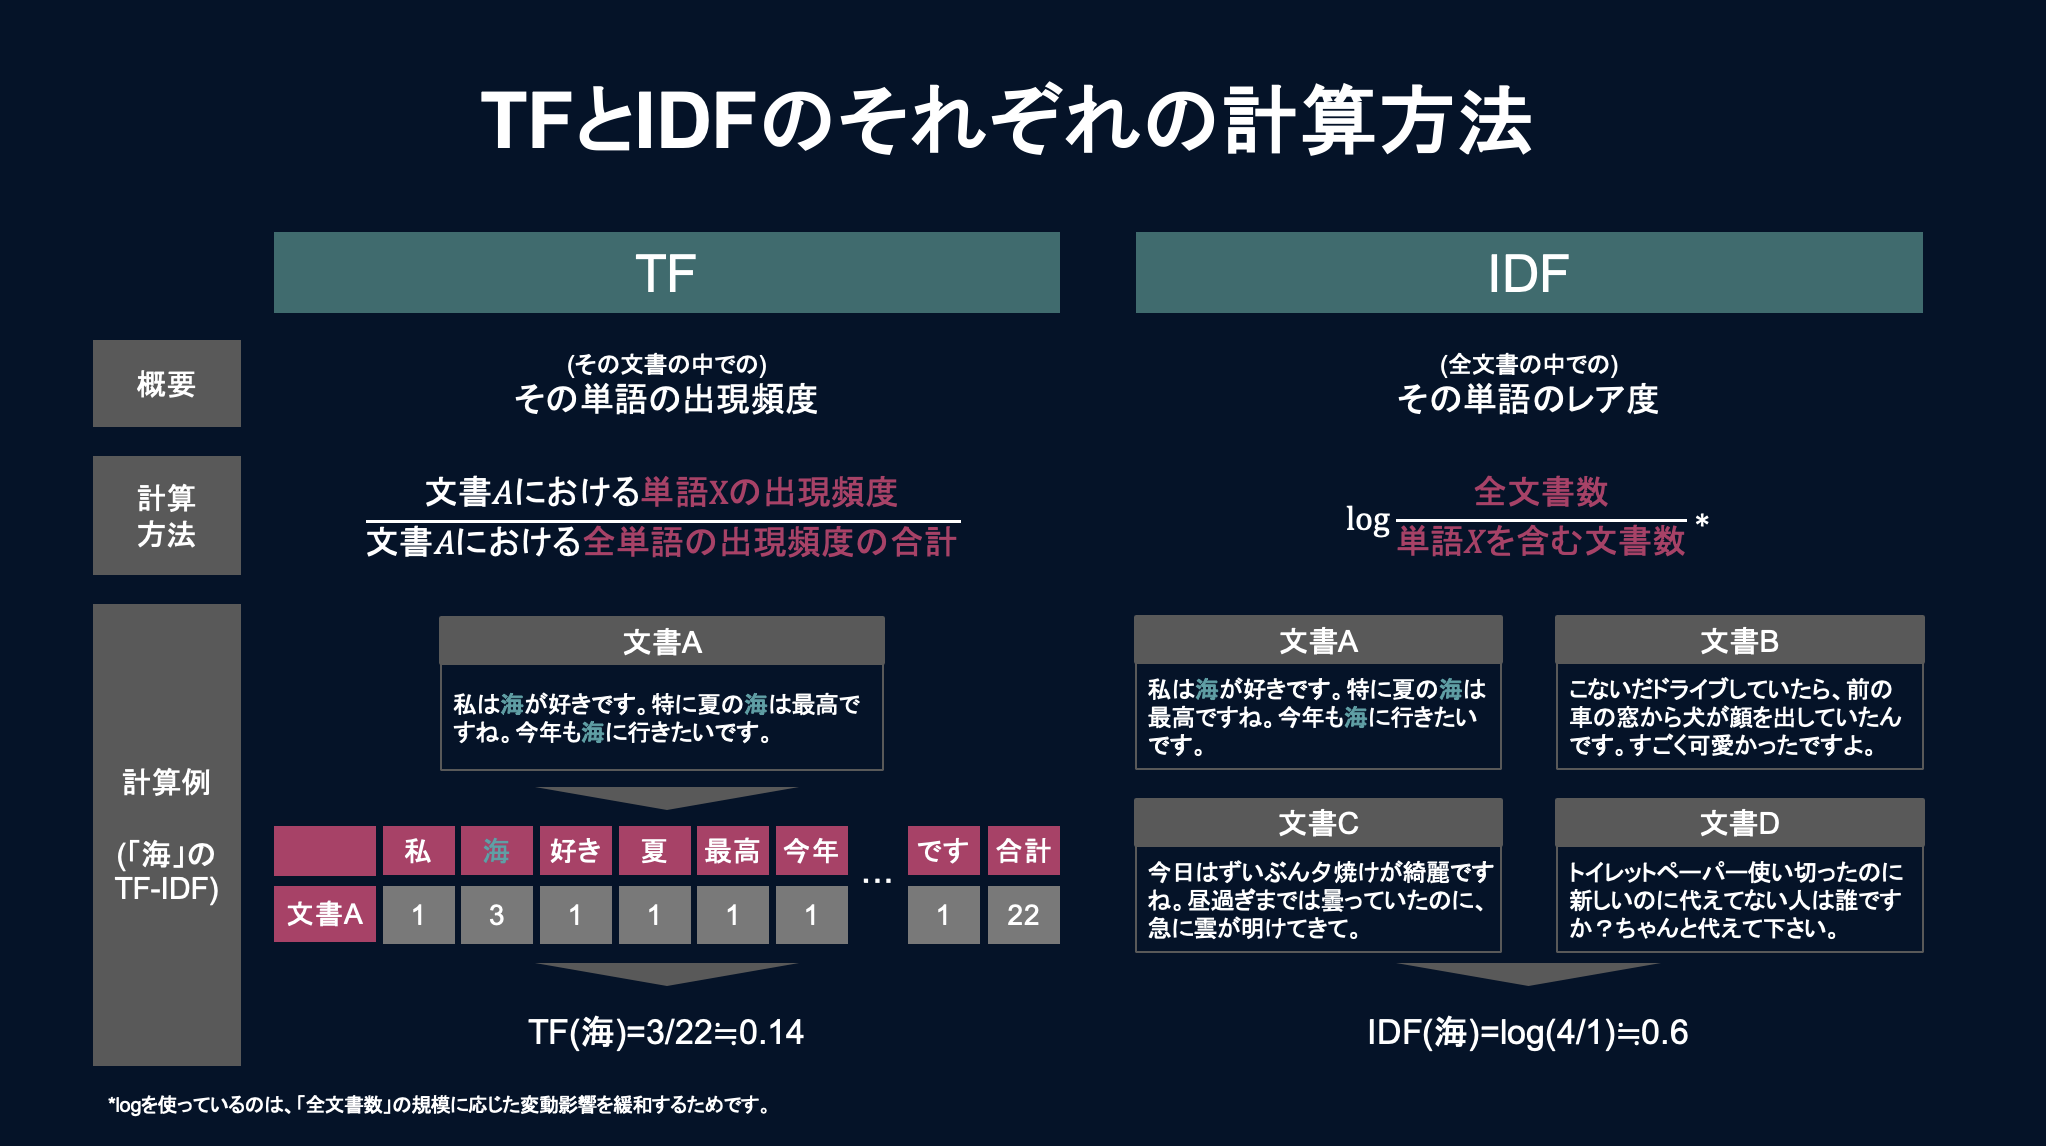

## <font color=#0e89b2>2.5 TF-IDFの実装</font>

### <font color=#0e89b2>a. テキストデータの準備</font>

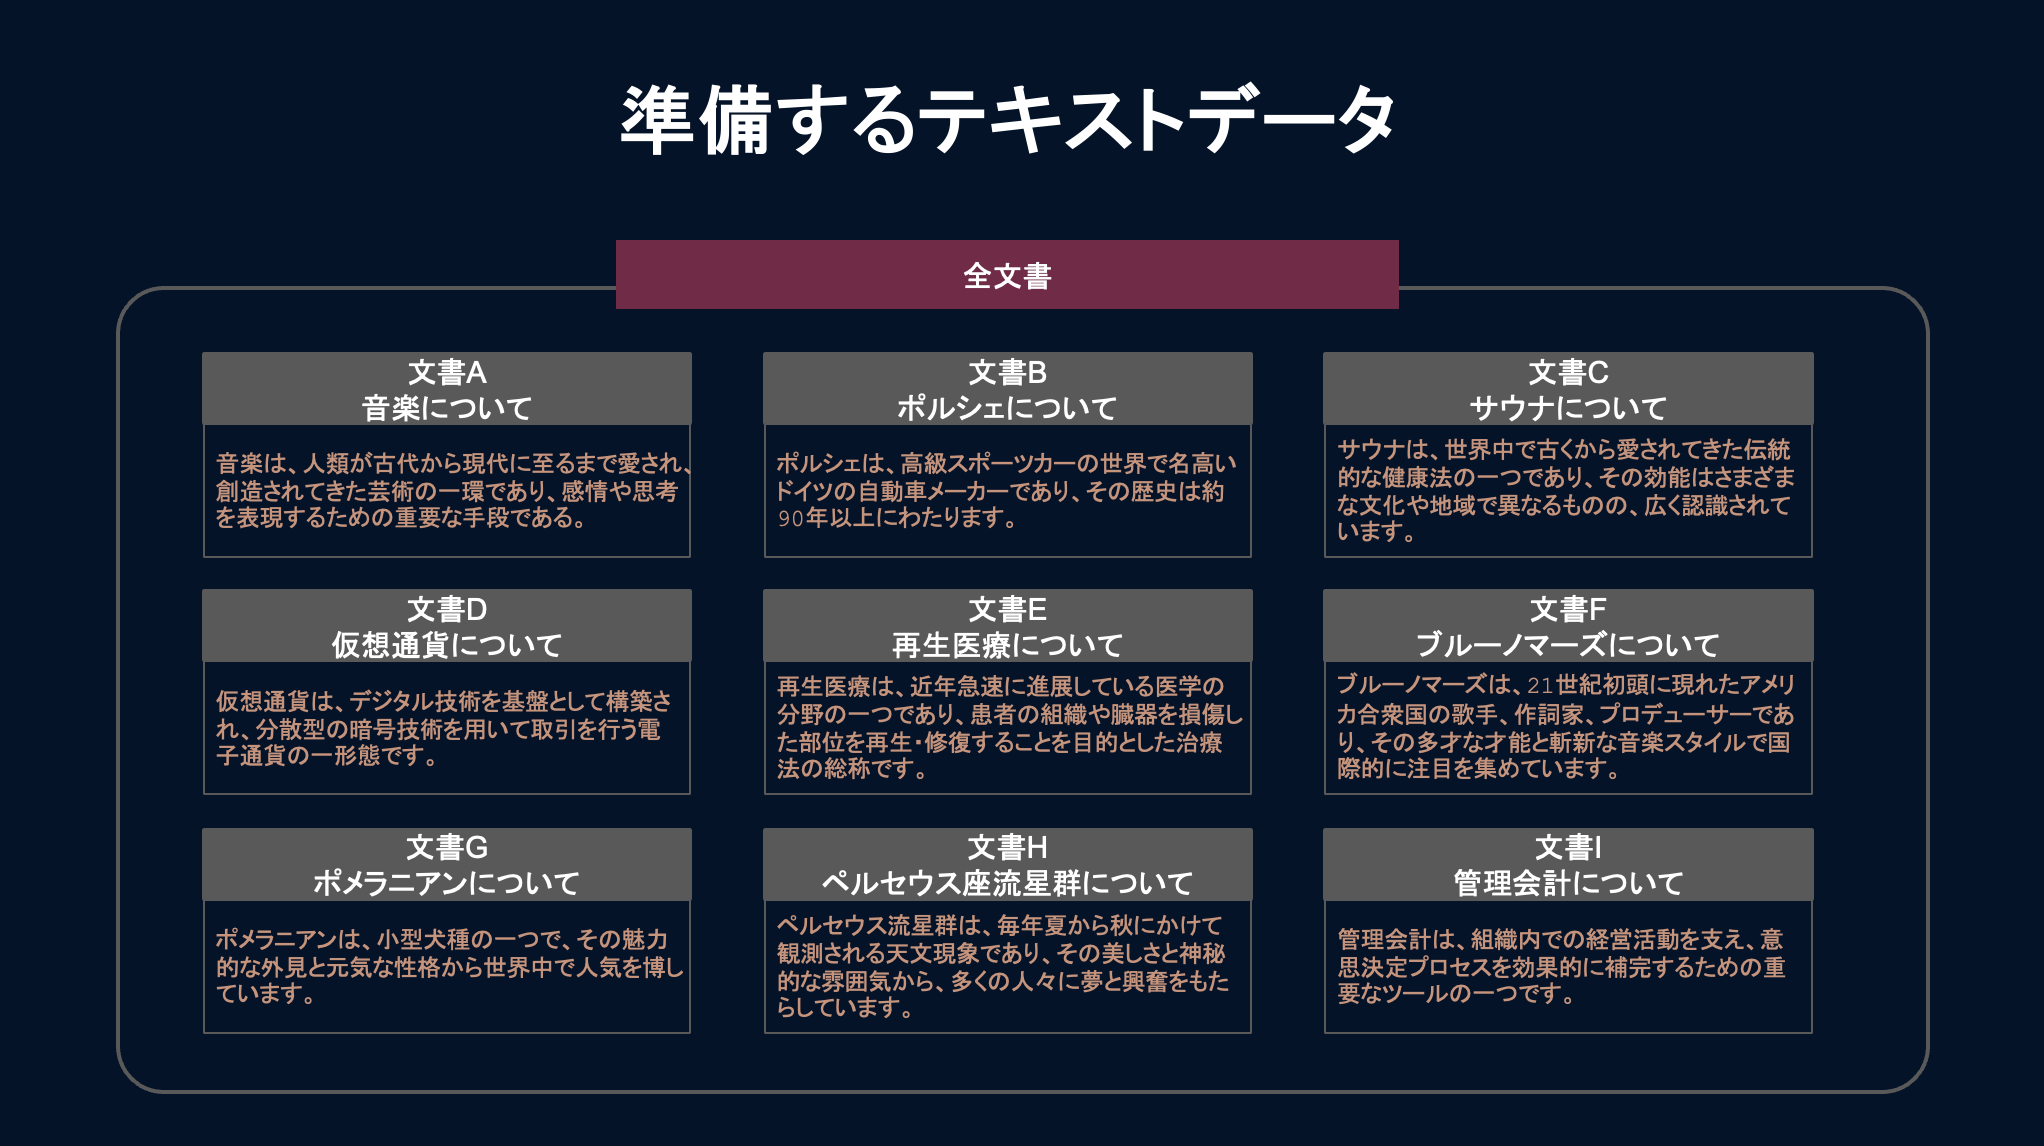

テキストデータを準備していきます。<br>
ここでは、「音楽」「サウナ」などのテーマに沿った各3,000字前後の文書を準備し、<br>
それらの文書の集合体を「全文書」と呼ぶことにします。<br>
<br>
各文書は、わかち書きした状態でデータとして保持します。

In [ ]:
#from janome.tokenizer import Tokenizer

#辞書を読み込み、解析プログラムを起動状態にする（メモリを食うので、何度も実行しないようにしましょう）
t = Tokenizer()
t

In [ ]:
#文章をわかち書きし、半角スペースで区切って出力する関数
def wakati(line):
  tokens = t.tokenize(line, wakati=True)
  output = ""
  for i in list(tokens):
    output +=" "
    output += i
  return output

In [ ]:
#各文書
text_sea = wakati("地球の表面積の約7割を占める海は、広大な水塊として地球環境に大きな影響を与え、様々な生物の住処として多様な生態系を育んでいます。太陽光の届かない深海を除いて、海には無数の生命が息づき、地球上の生命の起源とも言われています。海は、生命にとって重要な役割を果たしてきました。約40億年前、高温で生命が住めなかった地球において、海は徐々に冷え、約38億年前には最初の生命が誕生したとされています。海は、生命に必要な水や栄養素を供給し、地球上の生命を育み、進化させてきたのです。人類にとっても、海は重要な存在です。海は、食料、エネルギー、資源などの宝庫であり、交通や貿易の重要なルートでもあります。レクリエーションや観光の場としても利用され、人々の生活に密接に関わっています。しかし近年、海は様々な問題に直面しています。海洋汚染、乱獲、気候変動などが深刻化し、海を守ることが喫緊の課題となっています。海洋汚染は、海に住む生物に悪影響を与え、生態系を破壊しています。プラスチックごみの増加は特に深刻で、海鳥や海洋生物が誤飲して命を落とすケースが頻発しています。乱獲は、魚の資源を枯渇させ、海洋生態系のバランスを崩しています。持続可能な漁業への転換が求められていますが、現状は依然として楽観視できません。気候変動による海面上昇は、沿岸地域の住民や生態系に大きな脅威を与えています。海水温上昇は、サンゴ礁の白化や魚の生態系に悪影響を与え、生物多様性を減少させます。海を守るためには、一人一人の意識と行動が必要です。海洋汚染を防ぐために、ゴミを捨てない、リサイクルを徹底する。乱獲を防ぐために、魚を大切に食べる、持続可能な漁業を支持する。気候変動対策のために、省エネルギーに取り組む、二酸化炭素排出量削減に貢献する。海を守ることは、地球上の生命を守ることにつながります。美しい海を未来の世代に引き継ぐために、今、私たち一人一人が行動を起こす必要があります。海は、神秘的な魅力にあふれています。深い海には、まだ人間が知らない生物がたくさんいると言われています。海の生物は、様々な形や色をしていて、とても美しいです。海は、常に変化しており、同じ景色を見ることは二度とありません。海は、人々に癒しを与えてくれます。波の音を聞きながら海岸を歩いたり、海に入ったりすると、心が落ち着きます。海は、人々に冒険心を刺激します。海に出ると、新しい発見や出会いがあります。海は、地球にとってかけがえのない存在であり、人類の未来にとって重要な役割を果たします。海を守り、持続可能な社会を実現するために、私たち一人一人ができることを考え、行動することが重要です。海は、地球の生命の源であり、人類の未来を支える存在です。海を守ることは、私たち一人一人の責任であり、未来への希望です。")
text_music = wakati("音楽は、人類が古代から現代に至るまで愛され、創造されてきた芸術の一環であり、感情や思考を表現するための重要な手段である。音楽は、様々な文化や時代を通じて進化し、多様性を持ちながらも、人々を結びつける普遍的な言語となっている。音楽の歴史は古代に遡り、様々な文化で異なる形態で発展してきた。古代ギリシャでは、音楽は教育や宗教儀式において重要な役割を果たしており、ピタゴラスが発見した音の数学的な法則は、音楽理論の基盤となった。また、古代中国では雅楽や琵琶などの楽器が発展し、音楽は王朝の栄華を讃える手段としても重用された。中世からルネサンス期にかけては、宗教音楽が隆盛を極め、ヨーロッパの大聖堂で賛美歌やモテットが奏でられた。しかし、ルネサンス期になると宗教音楽だけでなく、世俗音楽も興隆し、器楽曲や合唱曲が盛んに作曲された。これらの音楽が文芸復興とともに発展する中で、音楽は芸術としての地位を確立していった。17世紀から18世紀のバロック期には、作曲家たちが対位法や装飾音、多様な楽器を駆使して新しい音楽の形式を生み出した。バッハやヘンデルなどの作曲家は、この時代において多くの傑作を生み出し、その影響は後の時代にも続いた。そして、古典派時代になると、モーツァルトやハイドン、ベートーヴェンなどが交響曲や室内楽、オペラなど様々なジャンルで革新的な作品を生み出し、音楽史に名を刻んだ。19世紀に入るとロマン派が興り、感情豊かな作風や個性的な表現が重要視されるようになった。シューベルトやショパン、リストといった作曲家たちは、個々の感情や体験を音楽に込め、自由な表現が求められるようになった。同時に、民族音楽の影響も色濃く現れ、国ごとに異なる音楽文化が根付くようになった。20世紀に入り、音楽はますます多様な方向に進化していった。ジャズやブルース、ロックなどのポピュラー音楽が興隆し、新たな音楽のジャンルが生まれた。また、クラシック音楽でもアヴァンギャルドな作風や現代音楽が登場し、伝統的な音楽の枠を超えた実験的なアプローチが試みられた。現代においては、デジタル技術の進化により、音楽制作や配信が手軽に行えるようになり、アーティストやリスナーは世界中と瞬時につながることができる。音楽の多様性も一層拡大し、様々な文化やジャンルが融合する新たな音楽が生み出されている。音楽は単なる娯楽だけでなく、感情や思索を表現する力強いメディアである。特定の楽曲やジャンルが人々の心に響く瞬間は、共感と感動を生み出し、時には社会や歴史の変動とも結びつく。戦争や社会運動、文化の変遷など、音楽は時代の空気感を反映し、人々に力強いメッセージを届けてきた。また、音楽は個々の精神や心理にも深い影響を与える。リラックスや癒しを求める際にはクラシック音楽や自然の音が好まれ、エネルギッシュな気分を味わいたい時にはポップスやロックが選ばれることが一般的である。音楽療法も、心身の健康促進やリハビリテーションにおいて有効な手段として広く活用されている。一方で、音楽は商業的な側面も持っており、アーティストや制作陣、レコード会社などが関与するビジネスとしての一面も重要である。音楽産業はアーティストの才能を支え、新たな音楽を生み出すためのインフラを提供している。同時に、音楽の商業化やデジタル時代の到来により、アーティストの収入構造や音楽の普及手段も変化してきた。音楽は言葉を超えたコミュニケーションの手段であり、異なる文化や言語を持つ人々が共感し合う橋渡しともなっている。国際的な音楽フェスティバルや異文化交流の場では、さまざまな音楽が交錯し、新たな表現が生まれる。これにより、地域や国境を越えて音楽が世界中で愛され、共有されている。総じて、音楽は人間の感情や思考を表現し、繋げる力強いメディアである。その歴史は古代から現代にかけて、様々な文化や時代の変遷とともに進化してきた。音楽は私たちの生活に深く根付き、人々を感動させ、結びつける不可欠な要素である。")
text_literature = wakati("文学は、人間の知恵や感情、想像力を文字に託し、言葉の芸術として表現する手段である。古代から現代に至るまで、さまざまな文学作品が生み出され、人々に感動や洞察をもたらしてきた。文学は言葉の持つ力を最大限に引き出し、読者に深い思索や感慨を与える媒体として、人間の文化と歴史に深く結びついている。文学の歴史は古代に遡り、口承文学や叙事詩が社会の伝承となっていた。古代ギリシャのホメロスによる「イリアス」や「オデュッセイア」、古代インドの「マハーバーラタ」、中国の「封神演義」など、さまざまな文化で物語が生み出された。これらの叙事詩は英雄譚や神話を通じて、人間の根源的な喜びや苦悩、冒険を描いており、人類の共通した体験を反映している。中世に入ると、ヨーロッパでは騎士道文学や宗教的な文学が栄え、バラードやロマンスなどが語り継がれた。一方で、日本では平安時代の「源氏物語」や鎌倉時代の「詩仙堂雅経」など、物語性と美意識が織り交ぜられた作品が生まれた。これらの文学作品は、当時の社会や文化を反映しつつ、永遠のテーマに触れるものであり、後の世代に影響を与えた。ルネサンス期には、人間中心の視点が強調され、個人の感情や思索が文学において重要視されるようになった。シェイクスピアの戯曲やダンテの「神曲」は、人間の心の葛藤や喜び、苦悩を深く描いた傑作であり、現代でも多くの読者や観客を引きつけている。同時期の日本では、近松門左衛門や井原西鶴などが、人間の営みや風俗を描いた浮世草子や人情本を発表し、江戸時代の文学の基盤を築いた。18世紀から19世紀にかけては、ヨーロッパにおいて啓蒙時代が到来し、理性や科学が重視された。文学もまた、個人の自由や平等、人権といったテーマに焦点を当て、啓蒙文学が生まれた。ヴォルテールやディドロの哲学的な小説、ジェーン・オースティンの社交小説などがこの時期の代表的な作品として挙げられ、社会や人間関係に対する深い洞察がなされている。同時期の日本では、近松門左衛門の影響を受けた文人たちが、浮世草子や読本などで江戸の庶民の生活や風俗を描いた。また、宮沢賢治や夏目漱石などが近代文学の先駆けとして、個人の内面や社会の変革をテーマにした作品を発表し、新しい文学の方向性を提示した。20世紀に入ると、文学は多様な表現形式を取り入れ、実験的なアプローチが試みられるようになった。モダニズム文学やシュルレアリスム、マジックリアリズムなどが興隆し、ジェームズ・ジョイスの「ユリシーズ」やガルシア＝マルケスの「百年の孤独」などが、従来の文学の枠を打破し新たな表現を提示した。同時期の日本では、谷崎潤一郎や太宰治などが、個人の葛藤や欲望を描いた作品を発表し、新しい文学の潮流を築いた。また、戦後の日本文学では、三島由紀夫や村上春樹などが、現代社会や個人のアイデンティティに対する問いかけを通じて、新しい文学の可能性を追求している。文学は言葉を通じて人間の内面や社会、歴史を深く掘り下げ、読者に思索や感動を与える。作家は言葉の魔法を操り、読者を異なる世界へ誘い込む力を持つ。文学作品はしばしば、人間の複雑な感情や心の葛藤、喜びや哀しみを共有する手段となり、読者と作家との間に深い共感を生み出す。文学はまた、社会や文化、歴史の鏡である。文学作品はその時代の風俗や価値観、政治や経済の状況を映し出し、後世にその時代の空気感を伝える役割を果たす。歴史小説や社会派小説、サイエンスフィクションなど、さまざまなジャンルを通じて、文学は人間の営みとその背後に潜む力強いメッセージを伝えている。一方で、文学は時に異なる文化や国々をつなぐ橋渡しとなる。翻訳によって異なる言語圏の作品が広く読まれ、異なる文化や価値観に触れることができる。文学を通じて異なるバックグラウンドを持つ人々が共感し合い、理解を深めることは、異文化理解の促進に寄与している。現代においては、デジタル技術の進化により、文学は新たな表現の手段を見出している。ウェブ小説やブログ、電子書籍などが登場し、従来の枠にとらわれない新しい文学の形態が生まれている。また、ソーシャルメディアを通じて、読者と作家が直接交流し合う機会も増え、文学の制作と受容がよりオープンでダイナミックなものとなっている。総じて、文学は言葉の芸術であり、人間の知恵や感情を深く掘り下げ、共有する手段である。歴史や社会、文化を映し出す鏡として、人間の営みに深い理解をもたらす。古代から現代にかけて、文学は人間の内なる葛藤や喜びを描き、読者と作家を繋ぎ合わせる不可欠な要素として、人間の精神と文化に深く結びついている。")
text_haruki = wakati("村上春樹は、日本を代表する現代の作家であり、その作品は国内外で高い評価を受けて村上春樹は、1949年1月12日に京都府に生まれた。彼の文学の才能は若くして早くから現れ、東京都立大学（現在の東京都立大学）で演劇を学びながら、早稲田大学で学び直しをした後、ビジネスの世界で働きながら小説家としての執筆活動を開始した。1979年に発表された処女作「風の歌を聴け」は、彼の文学の始まりを告げるものであり、翌年には短編小説「羊をめぐる冒険」で芥川賞を受賞した。その後も、村上春樹は精力的に執筆を続け、様々な作品を発表していった。彼の作品の特徴的な要素は、非現実的な要素や夢幻的な描写、音楽や文学への言及などが挙げられる。また、登場人物たちの内面の葛藤や哲学的な探求が緻密に描かれ、読者は村上春樹の独自の世界に引き込まれる。1987年に発表された「ノルウェイの森」は、彼の代表作の一つとされている。この小説は青春と愛のテーマを掘り下げ、登場人物たちの心の動きを繊細かつ深遠に描写している。また、音楽や文学、映画への言及が随所に散りばめられ、村上春樹が独自に築き上げた文学的なスタイルが顕著に表れている。1994年に発表された「ねじまき鳥クロニクル」は、物語の非現実的な要素や奇妙な出来事が複雑に絡み合った作品であり、多くの読者を引きつけた。この小説では、時間と空間が交錯し、奇妙なキャラクターたちが独自の物語を紡いでいく。登場人物の心の葛藤や謎めいた出来事が読者を引き込み、物語の謎解きが進むにつれて深まる哲学的なテーマが堪能できる。村上春樹の作品には、しばしば現実世界と夢幻的な異世界が交錯するモチーフが見受けられる。彼の小説に登場するキャラクターや出来事は、リアリティと幻想の境界線を曖昧にし、読者はその中で自分自身の感情や哲学と向き合うことになる。これは彼の独特の文学的手法であり、村上春樹が築き上げた独自の世界観を形成している。村上春樹はまた、音楽との深い関わりも知られている。彼の作品には、ジャズやクラシック音楽、ロックなど様々なジャンルの音楽が登場し、物語の進行や登場人物の心情を豊かにする役割を果たしている。音楽と文学が交わり合うことで、彼の作品は独特の雰囲気と深みを持ち、読者に音楽的な体験を提供している。1999年に発表された「海辺のカフカ」は、不条理な出来事や謎めいたキャラクターが織りなす作品であり、村上春樹の独自の文学スタイルがより際立っている。登場人物が現実と夢幻の世界を行き来する中で繰り広げられる物語は、読者に多様な解釈を許し、文学の奥深さを味わわせる。2002年には「アフターダーク」が発表され、彼の作品における新たな試みが見受けられた。この小説では、夜の都市を舞台に異なる登場人物たちの物語が交錯し、一夜を通して描かれる。リアルタイムで進む出来事や登場人物たちの交流が、物語に独特のリアリティと緊張感を与えている。村上春樹は、自身の作品の多くを英語に翻訳し、国際的な読者層にもアプローチしている。彼の作品は独特の日本的な要素と普遍的なテーマが融合し、異なる文化圏においても共感を呼び起こしている。彼の翻訳作品も高い評価を得ており、その文学的な影響は世界的なものとなっている。2017年に発表された「騎士団長殺し」は、村上春樹の文学的探求の一環として高く評価された作品である。この小説では、歴史的な要素や哲学的な問いかけが織り交ぜられ、村上春樹が得意とする不可思議な世界が広がっている。登場人物たちの心の葛藤や物語の奇妙さが、読者を深い思索へ誘う。村上春樹の作品は文学のみならず、現代の文化や社会にも大きな影響を与えている。彼の独自の文学スタイルや哲学的テーマは多くの読者や批評家に影響を与え、彼が築き上げた独自の世界は今なお多くの人々に愛されている。彼の文学は決して一枚岩ではなく、様々な要素が絶妙に調和した作品群が、日本文学の新たなる地平を拓いている。")
text_ML = wakati("機械学習は、コンピュータプログラムがデータから学習し、経験から得た知識を活用して新しいデータを分析し、予測や意思決定を行う手法である。この分野は、人工知能（AI）の一分野として急速に進化し、様々な応用が展開されている。機械学習は、ビッグデータの活用や自動化の進展とともに、産業界、医療、金融、交通、エネルギーなど多岐にわたる領域で重要な役割を果たしている。機械学習の基本的な概念は、アルゴリズムがデータからパターンを学習し、未知のデータに対して予測や分類を行えるようにすることである。その際、教師あり学習、教師なし学習、強化学習など、さまざまな学習手法が存在する。教師あり学習では、アルゴリズムはラベル付きのデータを学習し、特定のパターンや関連性を見つけ出す。これに対して、教師なし学習ではラベルがないデータセットから構造やパターンを抽出する。強化学習は、環境との相互作用を通じて最適な行動を学習する手法であり、ゲームやロボット制御などに応用されている。機械学習の基盤となるのはデータであり、特に大量のデータを処理することが求められる。ビッグデータの時代においては、膨大なデータセットから優れたモデルを構築し、有益な知見を得ることが重要となっている。このため、データの前処理や特徴量の選択などが機械学習のプロセスにおいて欠かせない工程となっている。画像認識、音声認識、自然言語処理などの分野での機械学習の進展は顕著である。例えば、画像認識ではディープラーニングと呼ばれる手法が注目を浴びており、多層のニューラルネットワークを用いて高度な画像解析を可能にしている。音声認識においても、ディープラーニングを応用したモデルが高い精度で音声をテキストに変換する技術が開発され、スマートスピーカーや音声アシスタントの普及に寄与している。自然言語処理は、コンピュータが人間の言語を理解し、意味を解釈できるようにする技術である。機械翻訳や質問応答システム、テキストマイニングなど、様々な応用があり、大量のテキストデータから意味を引き出す手法が進化している。これにより、多言語コミュニケーションの円滑化や情報検索の効率向上が実現されている。機械学習の進化は医療分野でも大きな影響を与えている。診断支援、治療法の最適化、薬剤の開発など、機械学習を用いた医療の進化が期待されている。画像診断においては、医療画像から異常を検出する技術が進み、早期の病気の発見や精密な診断が可能になっている。また、遺伝子データや臨床データの解析においても機械学習が応用され、がんの治療法の個別化や新たな治療法の開発が進んでいる。金融分野においても、機械学習は予測分析やリスク管理、取引の自動化などに利用されている。株価の予測や信用リスクの評価、不正行為の検知など、大規模で複雑なデータセットを取り扱う金融業務において、機械学習の導入は高い効果を上げている。交通分野では、自動運転技術の進化が挙げられる。センサーデータやカメラ映像を解析し、車両が周囲の状況を理解し適切な判断を行う技術が機械学習を基にしている。これにより、交通事故の予防や運転の効率化が期待されている。エネルギー分野では、機械学習が省エネやエネルギーの効率向上に寄与している。発電所の運転管理や電力ネットワークの最適化、エネルギー使用パターンの予測など、多岐にわたる応用が進んでいる。機械学習は社会の様々な領域において利活用されている一方で、課題や課題も存在する。データの品質や偏り、プライバシーの問題、アルゴリズムの透明性や説明性の不足などが挙げられる。特に、機械学習モデルが過去のデータに基づいて学習するため、偏ったデータに基づいてしまうと、それによる予測や判断も偏りが生じる可能性がある。また、ブラックボックス化が進む機械学習モデルは、その内部の動作が理解しにくいという課題もある。倫理的な側面でも、機械学習の導入に伴い新たな課題が浮き彫りになっている。アルゴリズムによる意思決定が人々の生活に影響を与える場面において、公平性や差別の問題が浮上している。例えば、採用選考や融資の判断などでアルゴリズムが使用される際には、それが機械的に不公平な結果をもたらす可能性がある。これらの課題に対処するためには、透明性の確保や公正なデータセットの構築、倫理的なガイドラインの策定などが必要とされている。機械学習の進展が加速する中で、技術と倫理が調和し、社会全体に利益をもたらすような方向での発展が求められている。総じて、機械学習は人間の認知能力を超えるデータ処理能力を活かし、様々な分野で効果的な解決策を提供している。ビッグデータの時代においては、その有効性が一層際立っており、未来においてもますます重要性を増す技術である。しかし、その進展には慎重な取り組みが必要であり、技術の発展と社会の健全な発展が両立するためには、様々なステークホルダーが協力して課題に対処することが求められている。")
text_NLP = wakati("自然言語処理（Natural Language Processing, NLP）は、人間が日常的に使用する言語をコンピュータに理解・処理させるための技術分野である。この分野の発展は、機械学習や人工知能の進化に大きく依存しており、多岐にわたるアプリケーションや応用が展開されている。文章や会話、質問応答など、言語に基づく情報の解釈や生成において、自然言語処理は重要な役割を果たしている。自然言語処理の初期の研究は、主に構文解析や形態素解析など、言語の構造を理解するための手法に焦点を当てていた。しかし、近年の進歩により、意味や文脈を考慮した高度な処理が可能となり、より自然で人間に近い言語理解が実現されている。言語モデリングは、自然言語処理の基盤となる概念である。これは、言語の統計的なパターンやルールを学習することで、文や単語の意味を理解するモデルを構築する手法である。具体的には、n-gramモデルや最大エントロピー法、条件付きランダムフィールドなどが利用され、これらの手法によって言語モデルが進化してきた。自然言語処理の一分野である機械翻訳は、言語間の翻訳を実現する技術であり、様々な言語が瞬時に相互に理解されるようになった。これは、言語モデルやディープラーニングの進展により、文の意味や構造をより正確に捉えることが可能になった結果である。Google翻訳やニューラル機械翻訳など、多くのプラットフォームで利用されている翻訳技術は、自然言語処理の最先端の成果を示している。文書の分類や感情分析も、自然言語処理の一環として広く利用されている応用分野である。テキストデータが爆発的に増加する中、大量の文章から情報を取り出すためには、文書を分類して適切なラベルを付与する技術が求められる。感情分析は、文章やコメントから感情や意図を抽出する手法であり、ソーシャルメディアやカスタマーレビューの分析、商品の評価などで応用されている。質問応答（Question Answering, QA）も自然言語処理の応用例の一つである。QAシステムは、ユーザーからの質問に対して自動的に適切な回答を生成することを目指している。近年では、大規模な言語モデルや事前学習済みのモデルを利用して、より高度な質問応答が実現されている。これにより、ウェブ検索エンジンや仕事上の情報検索などで利用され、利便性が向上している。自然言語処理の進展には、ディープラーニングが大きく寄与している。特に、リカレントニューラルネットワーク（RNN）、長・短期記憶ネットワーク（LSTM）、トランスフォーマーなどのアーキテクチャが注目を集めている。これらのモデルは、単語や文の意味を文脈に基づいて把握し、より自然な言語理解を実現する。また、事前学習済みの言語モデル（Pre-trained Language Models, PLM）も登場し、膨大な量のテキストデータから学習された知識を基にして、様々なタスクに転用可能な柔軟性を有している。自然言語処理は、情報抽出や要約、対話システムの開発など、幅広い応用分野に適用されている。情報抽出は大量のテキストデータから特定の情報を抽出し、データベース化する技術であり、ニュース記事や医学論文などの分野で活用されている。要約は大量の文章から主要なポイントを抽出して、簡潔な形で提示する技術であり、情報過多の中で重要な情報にアクセスしやすくする効果がある。対話システムは、コンピュータとユーザーとの自然な対話を可能にする技術である。音声認識や音声合成技術と組み合わせることで、音声ベースの対話も実現されつつある。これにより、スマートスピーカーや音声アシスタントが普及し、ユーザーとコンピュータの対話が身近なものとなっている。一方で、自然言語処理の進展には課題も存在する。特に、意味理解の向上や文脈の正確な把握、多言語対応など、言語の複雑性に対処することが求められている。また、倫理的な側面も注視されており、バイアスの排除やプライバシーの保護などが重要なテーマとなっている。総じて、自然言語処理は人間の言語理解を模倣し、コンピュータが言語に基づく情報を理解・生成できるようにするための興味深い分野である。その進展は情報社会において大きな変革をもたらし、今後も様々な分野での応用が期待されている。技術の進歩と倫理の調和が進む中で、より効果的で公正な自然言語処理技術の実現が求められている。")
text_otani = wakati("大谷翔平（おおたに しょうへい）は、日本のプロ野球選手であり、野球界において多岐にわたる才能を持つ選手として知られています。彼は1994年7月5日に岩手県花巻市で生まれ、野球界においてその異例の才能を発揮しています。彼の野球への興味と才能は非常に早い段階から現れ、幼少期から地元の少年野球チームで注目される存在でした。大谷が小学校時代にプレーしていた頃、その圧倒的な実力が周囲を驚かせ、将来が期待される逸材として注目を集めていました。中学校時代には、早くもプロ野球選手の素質を垣間見せていました。その優れたピッチングと打撃力は、スカウトや野球関係者の注目を浴びることとなり、プロ野球入りの可能性が高まっていました。中学卒業後、大谷は進学を選ばず、プロ野球の舞台へと進むことを決意しました。2012年、大谷は福岡ソフトバンクホークスと契約し、プロ野球選手としてのキャリアがスタートしました。彼のプロ入り早々にして、その驚異的な能力が注目を集め、多くのファンを魅了しました。大谷は投手としても打者としても結果を残し、そのオールラウンドなプレースタイルは野球史に名を刻むものでした。投手としての大谷は、その高い身体能力と技術が融合した結果として、圧倒的なピッチングを披露しました。彼の速球、変化球、そして精密な制球力は相手打者を翻弄し、勝利に貢献していきました。また、打者としての大谷も非常に印象的で、驚異的なバッティングスキルとホームランを連発し、打線の中心としても存在感を発揮していました。大谷が特に注目を集めた瞬間の一つが、2016年のプロ野球オールスターゲームでの活躍でした。この年、大谷は先発投手として登板し、その圧倒的な投球で多くのファンを魅了しました。また、同じく打者としても出場し、ホームランを放つなどの活躍で、オールスターゲームのMVPに輝く快挙を達成しました。2017年には、大谷がプロ野球界において異例の「二刀流」を実践することとなりました。この年、大谷は先発投手としてだけでなく、試合によっては外野手としてもプレーし、その幅広いプレースタイルが話題となりました。この二刀流の実現は、野球史において稀有な快挙であり、多くのファンや専門家から絶賛されました。2017年のオフには、大谷はメジャーリーグへの挑戦を決意し、その後の経緯が大きな話題となりました。2018年、大谷はロサンゼルス・エンゼルスと契約し、メジャーリーグデビューを果たしました。彼は日本からの移籍選手としては異例の活躍を見せ、特にバッティングにおいては期待以上の結果を残しました。大谷はメジャーリーグデビューの年において、その驚異的な才能を遺憾なく発揮しました。投手としては高い制球力と速球を駆使し、打者としてはパワフルなバッティングとホームランを連発。その活躍により、彼はメジャーリーグの新人王に選ばれるなど、多くの栄誉を受けました。特に、大谷がメジャーリーガーとして注目される理由の一つは、その「二刀流」のスタイルを維持しつつ、メジャーリーグでもその能力を十分に発揮できたことにあります。彼は投手として先発登板し、次の試合では外野手として出場するなど、その柔軟性と高いプレー能力が多くのファンや野球関係者を感動させました。大谷のメジャーリーグでの活躍は、日本国内だけでなく、世界中の野球ファンから称賛されました。彼の成功は、日本人選手がメジャーリーグでトッププレーヤーとして認められる一翼を担うものであり、日本の野球界においても大きな影響を与えました。大谷翔平のキャリアは、野球の歴史において特異な存在として位置づけられています。その優れた才能、努力、そして異なるポジションでの成功は、将来の野球選手にとっても大きなインスピレーションとなっています。大谷はこれからもそのキャリアを発展させ、野球の新たな可能性を切り拓く存在として期待されています。")
text_law = wakati("刑事訴訟法は、刑事事件における司法手続きを規定し、被告人の権利を保護する法律です。その目的は、公正かつ迅速な刑事司法の実現であり、被告人の権利を尊重しながら社会の秩序を維持するための枠組みを提供しています。刑事訴訟法は、事件の発覚から刑事裁判の終結までの一連の手続きを取り決めており、その中で検察、弁護人、被告人、そして裁判官など関与する各当事者の権利や責務が明確に規定されています。被告人の権利を保護する重要な要素の一つは、法廷での公正な審理です。刑事訴訟法は、公判の原則を掲げ、裁判を公然かつ公正に行うことを求めています。公判の原則は、一般の市民が法廷での証拠や主張を知る機会を確保し、社会の信頼を得るためのものです。公判は公然と行われ、報道機関や一般の人々が法廷の進行を追えるようになっています。検察の役割も刑事訴訟法において重要な位置を占めています。検察は犯罪捜査を担当し、訴訟を起こす権限を有しています。ただし、その一方で検察の権限を制約するために、被告人の権利や法の下での平等を重視する規定が存在しています。例えば、検察は証拠を適正に提出し、公正かつ中立な立場を保つ責務が課せられています。また、被告人に対しても法定手続きを厳守し、弁護人の選任や証拠開示など、公正な裁判のための環境を整備するよう求められています。被告人が法廷で公正な審理を受けるためには、十分な弁護を受ける権利が保障されています。刑事訴訟法では、弁護人の選任権や弁護活動の自由などが明確に定められています。被告人は、自らの意思に基づいて弁護人を選任する権利を有し、弁護人は被告人の権利を最大限に尊重し、法廷での主張や証拠の提出を行います。弁護人制度は被告人の弱者保護を図るために不可欠であり、裁判の公正性を確保する上で欠かせない一環となっています。また、証拠の適正な取り扱いも刑事訴訟法において注視されています。証拠は厳密な手続きに基づいて提出され、公正な裁判に資するものとして用いられます。検察や弁護人は証拠を適切に開示し、法廷では公正かつ中立な立場で証拠の真偽を検討します。また、被告人にも自身の立場を主張する機会が与えられ、法廷での尋問が行われます。これによって、事件の真実が明らかにされ、公正な判決が下ることが期待されます。刑事訴訟法においては、被告人に対する拷問や不当な取り調べを禁止する規定も厳格に規定されています。被告人は人権を尊重され、自白を強要されない権利が保障されています。このような権利保護は、冤罪の防止や司法の信頼性向上を図るために極めて重要です。強制的な取り調べや拷問は違法とされ、取得された証拠が裁判で使用されることは認められません。また、裁判所の役割も刑事訴訟法において重要です。裁判官は公正かつ中立な立場で訴訟手続きを指揮し、法律に基づいて判決を下します。彼らは法律を適切に解釈し、公正な審理のもとで正義を実現するために努めます。裁判所は被告人の権利を確保し、証拠の妥当性を検討する重要な役割を果たしています。裁判の進行においては、上訴や控訴などの手続きも刑事訴訟法に基づいて定められています。これにより、判決が下された後にも公正な手続きが継続され、適切な救済が行われることが期待されます。被告人や検察、弁護人など各当事者は、不服があれば適切な手続きを経て控訴や上訴を行うことができ、司法の誤りや不公正な判決に対抗する手段が提供されています。さらに、被害者や証人なども刑事訴訟法において一定の権利を有しています。被害者は自身の権利や利益を法廷で主張できる機会を得る一方、証人は真実を述べる権利があります。これらの権利保護は、司法手続き全体が公正かつバランスのとれたものとなるように工夫されています。刑事訴訟法は社会秩序の維持と個々の権利保護のバランスを取りながら、公正かつ迅速な刑事司法を確立することを目指しています。被告人、検察、弁護人、裁判官など関与する各当事者が、法の下で平等な立場で対話し、法の精神に基づいた判決が下ることが重要であり、それによって社会において正義が実現されるのです。")
text_starbucks = wakati("スターバックス（Starbucks）は、世界中で愛され、広く知られるコーヒーブランドであり、その独自のカフェ文化やコーヒーの提供スタイルで、多くの人々に親しまれています。1971年にアメリカで誕生し、現在では世界各国に展開されたスターバックスは、コーヒーだけでなく、豊富なドリンクメニューや軽食、雰囲気の良い店内でのくつろぎの空間など、独自の魅力を持っています。スターバックスの歴史は、1971年、シアトルのパイク・プレイス・マーケットで、3人の起業家、ジェリー・ボールドウィン、ゴードン・ボールドウィン、そしてジョゼフ・シュルツによって創業されました。当初、スターバックスは高品質なコーヒー豆の販売を主な事業としていました。しかし、その後、シアトルの新しいコーヒーブームを受けて、コーヒー豆の焙煎と販売だけでなく、カフェの運営も手がけるようになりました。スターバックスは、独自のビジョンとコンセプトを打ち出し、積極的な店舗展開を進めました。1987年には、ハワイに初の海外店舗を開店し、これがスターバックスの国際的な展開のスタートとなりました。その後、アメリカ国内外を問わず、急速に店舗網を拡大し、現在では数万店舗以上を擁する巨大なコーヒーチェーンとして世界中で親しまれています。スターバックスの成功の要因の一つは、独自のブレンドと焙煎技術にあります。スターバックスは、高品質かつ持続可能なコーヒーの提供を目指し、世界各地で栽培されたコーヒー豆を独自のブレンドで組み合わせ、その味わいや香りにこだわりを持っています。また、フェアトレードやサステナビリティに重点を置き、コーヒーの生産者とのパートナーシップを大切にしています。スターバックスのメニューは、コーヒーだけでなく、さまざまな種類のドリンクが揃っています。エスプレッソ、カフェラテ、カプチーノなどのクラシックなコーヒードリンクから、フラペチーノやティーラテなどのカフェインレスドリンク、季節限定のフレーバーも豊富に取り揃えられています。また、シンプルなブラックコーヒーから、贅沢なトッピングやシロップを加えたカスタマイズも可能で、個々の好みに合わせたカスタマイズがスターバックスの魅力の一つです。スターバックスの店内は、くつろぎの空間としても知られています。シンボルである緑のロゴの看板が目印の店舗は、木製の家具や心地よい照明、音楽までが計算された空間づくりが施されています。これにより、多くの人々がスターバックスを仕事の場や友人との集まり、または一人で静かな時間を楽しむ場として利用しています。Wi-Fiサービスも提供され、モバイルオーダーやドライブスルーなどの便利なサービスも展開されています。スターバックスはまた、社会的責任を重視しています。サステナビリティに焦点を当て、コーヒーの栽培者との協力や、環境にやさしい取り組み、フェアトレードの推進など、企業としての社会的な影響力を活かして持続可能な社会づくりに貢献しています。また、コーヒーのカップを再利用するための取り組みや、地域社会への支援活動も行っており、社会的な課題に積極的に取り組む企業姿勢が評価されています。さらに、スターバックスはデジタル技術を積極的に導入し、モバイルアプリやオーダーシステムの改善など、顧客とのデジタルなつながりを強化しています。これにより、スターバックスの顧客はオンラインでの注文やポイントサービス、キャッシュレス決済など、便利でスマートな利用が可能となっています。日本国内においても、スターバックスは非常に人気があり、多くの都市や街に出店しています。日本独自のメニューも展開され、季節ごとの限定商品や日本の文化に合わせたアレンジがされています。スターバックスは日本のコーヒーカルチャーに一石を投じ、カフェ文化を豊かにする一翼を担っています。総じて、スターバックスはコーヒー業界において圧倒的な存在感を持ち、そのブランドは単なる飲み物提供の場所を超え、ライフスタイルや文化の一部として多くの人々に受け入れられています。品質へのこだわり、店舗の雰囲気、社会的責任の取り組みなど、様々な側面からスターバックスは多くのファンを魅了し、今後も世界中でその存在感を示し続けることでしょう。")
text_ghibli = wakati("ジブリは、日本のアニメーション映画スタジオであり、その正式名称は「スタジオジブリ」です。1985年に宮崎駿、高畑勲、鈴木敏夫らが設立し、以来、数々の優れたアニメーション作品を世に送り出しています。ジブリ作品はその独自の世界観、感動的なストーリー、美麗なアニメーションとともに、国内外で高い評価を得て、多くのファンに支持されています。ジブリの特徴的な点の一つは、物語やキャラクターに深い情緒や人間味を込めていることです。ジブリの作品は、単なる子供向けのアニメーションではなく、幅広い年齢層に向けて制作されています。そのため、大人から子供までが楽しむことができ、観る者に深い感動や思索を与える作品が多く生み出されています。ジブリが生み出すアニメーション作品は、ファンタジーからリアリズムまで幅広いジャンルを網羅しています。代表的な作品として、宮崎駿監督の「となりのトトロ」や「千と千尋の神隠し」、高畑勲監督の「火垂るの墓」が挙げられます。これらの作品は、それぞれ異なる視点から人間の喜怒哀楽を描き、観る者に感動や共感を与えています。アニメーションの技術的な面でも、ジブリは常に最高のクオリティを追求しています。手描きアニメーションを中心に、細部にわたる作画の精緻さや背景の美しさは、ジブリ作品を一層魅力的なものにしています。特に、宮崎駿の描く空や風、水の表現は、自然の美しさを感じさせ、観る者を引き込んでいます。また、音楽もジブリ作品の重要な要素の一つです。作曲家の久石譲が多くのジブリ作品で音楽を手がけ、その音楽は作品に深い感情や雰囲気を添えています。例えば、「千と千尋の神隠し」の主題歌や「風の谷のナウシカ」のメインテーマなど、ジブリ作品の楽曲は作品と共に不朽の名作となっています。ジブリは単なるアニメーション制作スタジオにとどまらず、その製作手法やスタッフの働き方など、独自の経営哲学も持っています。ジブリはアメリカのディズニーなどとは異なり、作品ごとに異なる監督がクリエイティブな自由を持ち、それぞれが自分のアイデンティティを表現できるような環境を提供しています。これにより、ジブリ作品は監督ごとに異なるアートスタイルやメッセージを持っており、観る者に多様な体験を提供しています。ジブリの作品は日本国内だけでなく、国際的にも高い評価を得ています。例えば、アカデミー賞など国際的な映画賞での受賞やノミネート、各国での興行収入など、その成功は世界中で認められています。これにより、ジブリの作品は日本のみならず、世界中のアニメファンや映画愛好者に親しまれ、影響を与えています。ジブリはまた、アニメーション映画の普及や日本の文化の発信にも一役買っています。日本のアニメーションが国際的に高く評価され、アートとしての地位を確立する一翼を担うことになりました。また、ジブリのキャラクターグッズや音楽CD、映画のBlu-rayなども多くの国で販売され、日本文化の一環として広く受け入れられています。しかしながら、ジブリにも批判や課題も存在します。女性キャラクターの描写において男性キャラクターよりも主観的でないとされることや、女性監督が少ないことなど、ジブリが抱える課題については議論の的となっています。ジブリ自体もこれらの課題に取り組む姿勢を見せており、社会の変化に対応していく姿勢を示しています。さらに、ジブリはスタジオとしてだけでなく、テーマパークや博物館など、アニメ以外の分野にも進出しています。ジブリが手がけるテーマパーク「ジブリパーク」は、スタジオの代表作品を元にしたエリアやアトラクションを楽しむことができ、その開業を待ち望む多くのファンが存在します。また、ジブリ美術館も愛知県にあり、アニメーションの製作過程や制作秘話などを展示しています。ジブリの功績や影響は計り知れません。アニメーション映画としての歴史において、新たな地平を切り開き、世代を超えて多くの人々に愛されています。その感動的で美しい世界観は、今後も新たなファンを引きつけ、ジブリが日本のアニメーション文化の中で特別な存在であることは疑いようがありません。")
text_porsche = wakati("ポルシェは、高級スポーツカーの世界で名高いドイツの自動車メーカーであり、その歴史は約90年以上にわたります。ポルシェの車両はスポーツカーの頂点に君臨し、卓越したパフォーマンス、洗練されたデザイン、高度な技術を兼ね備えています。ポルシェのブランドは、世界中で独自の存在感を持ち、数多くのファンやコレクターに愛されています。ポルシェの歴史は、フェルディナント・ポルシェによって1931年に創業されたことに始まります。最初の数年間は、ポルシェは他の自動車メーカー向けにエンジンや設計を提供する会社としてスタートしました。その中で最も有名なものの一つが、フォルクスワーゲン・ビートルの開発であり、ポルシェはそのエンジン設計に深く関与しました。しかし、ポルシェの本領が発揮されたのは、自社ブランドのスポーツカーの製造が始まった時でした。初の量産スポーツカーである「ポルシェ356」は、1948年に発表され、その優れたパフォーマンスと手頃な価格で注目を浴びました。ポルシェ356は、後にポルシェのスポーツカーの系譜を築く礎となり、その後のモデルの基盤となりました。1963年に登場した「ポルシェ911」は、ポルシェの象徴とも言えるモデルです。空冷エンジンと後輪駆動を特徴とする911は、その特異なデザインと驚異的なパフォーマンスで自動車ファンの心を掴み、長寿モデルとして知られています。ポルシェ911は継続的に進化し、現在でも高い人気を誇っています。ポルシェはスポーツカーだけでなく、SUV（スポーツ・ユーティリティ・ビークル）やセダンなども手がけています。その代表的なモデルの一つが「ポルシェ カイエン」であり、これはスポーツカーの走りとSUVの快適性を融合させたモデルとして、幅広い層に支持されています。また、「ポルシェ マカン」はコンパクトなSUVとして登場し、都市部での扱いやすさとスポーティな走りを両立させています。ポルシェの車両は、パフォーマンスに優れるだけでなく、デザインにおいても独自のアイデンティティを持っています。クラシックでありながらも洗練されたデザインは、他の追随を許さない独自性を感じさせ、ポルシェ車は道路上で一際目を引く存在となっています。エクステリアだけでなく、インテリアも高級感と使いやすさを兼ね備え、ドライバーと乗員が快適なドライブを楽しむための様々な機能が搭載されています。ポルシェのモデルには様々なバリエーションが存在し、その中でも特にスポーツ性能に焦点を当てた「ポルシェ 911 GT3」や「ポルシェ 911 Turbo」などは、サーキットでの走行を意識したハイパフォーマンスモデルとして知られています。これらのモデルはポルシェがスポーツカーにおいて培ってきた技術とノウハウを集約し、究極のドライビングエクスペリエンスを提供しています。ポルシェはモータースポーツでもその実力を発揮しており、特に耐久レースでの成功が際立っています。「ポルシェ 917」は、1960年代から1970年代にかけてル・マン24時間レースで数々の勝利を収め、モータースポーツの歴史に金字塔を打ち立てました。その後も「ポルシェ 956」や「ポルシェ 962」といったモデルが続き、耐久レースでのポルシェの圧倒的な存在感を証明しました。近年では、電動化やハイブリッド技術への取り組みも進んでいます。代表的なハイブリッドモデルとしては、「ポルシェ 918 スパイダー」が挙げられます。このモデルは高い環境性能と卓越したパフォーマンスを両立させ、ポルシェの技術力の高さを証明しました。将来的には、電動車両へのシフトも進んでおり、ポルシェはその先進的な技術によって、持続可能なモビリティに対する貢献を模索しています。ポルシェのブランドは、単なる自動車メーカーを超えて、ライフスタイルやカルチャーにも深く関わっています。ポルシェの車に乗ることは、単なる移動手段ではなく、独自の価値観やステータスを表現する手段となっています。ポルシェの車には独特の魅力があり、多くの愛好者やコレクターが熱狂的に支持しています。ポルシェはまた、オーナーズクラブやイベントを通じて、オーナー同士やファンとの交流を促進しています。これにより、ポルシェの車に対するコミュニティが形成され、独自の文化や価値観が築かれています。ポルシェのイベントでは、新しいモデルの発表やモータースポーツへの参加、歴史的な車両の展示などが行われ、ポルシェ愛好者にとっては楽しみな場となっています。ポルシェはその高級スポーツカーとしての地位を確立しながらも、常に進化し続け、新たな技術やデザインに挑戦しています。これからもポルシェは自動車産業のトレンドを牽引し、スポーツカーの頂点に君臨し続けることでしょう。そのブランドの誇り高さと継続的な挑戦姿勢は、自動車業界において常に注目されています。")
text_pomeranian = wakati("ポメラニアンは、小型犬種の一つで、その魅力的な外見と元気な性格から世界中で人気を博しています。この可愛らしい犬種は、その小さな体躯とふわふわの被毛、陽気な性格で愛され、ペットとして広く飼育されています。ポメラニアンは歴史的な経緯から派生してきた犬種であり、その特徴的な外見と愛らしい性格は多くの飼い主たちを魅了しています。ポメラニアンの起源は古く、北欧地域にまで遡ります。ポメラニア地方（現在のポーランドとドイツの一部）で飼育されていた小型の牧羊犬が、この犬種の基礎となりました。この地域で飼育されていた犬たちは、当初は大型で牧羊犬の性格を持っていましたが、時が経つにつれて体躯が縮小し、王室や貴族の間で愛玩犬として人気を博するようになりました。18世紀になると、ポメラニア地方の王室や貴族たちの愛玩犬として広く飼育され、その存在感はますます高まりました。特に、イギリスの王室であるハノーヴァー家との縁組が続き、イギリスの王室でも愛される存在となりました。王室の支持を受けながら、ポメラニアンは徐々にその被毛の美しさや愛らしい性格が磨き上げられ、犬種としての確立を果たしました。ポメラニアンの特徴的な外見は、まずその小型の体躯から明らかです。一般的には、肩までの高さが20センチ未満と小型犬に分類され、その中でも小型でフワフワの被毛が特徴的です。豊かで密集した被毛は、首から尾までしっかりと覆い、特にたてがみのような毛が首周りに広がっています。被毛はストレートで、シルキーで艶やかな印象を与えます。ポメラニアンの被毛は様々な色やパターンが認められており、オレンジ、クリーム、ブラック、ブルーやチョコレート、マールド（複数の色が混ざった模様）などが存在します。被毛の色や模様も、その個性や個々のポメラニアンによって異なり、多様性に富んでいます。一方で、ポメラニアンの顔はフォックスフェイスとも呼ばれ、キュートで小ぶりな耳と丸い瞳が特徴的です。短いマズルに小さなノーズ、豊かなたてがみと相まって、まるでぬいぐるみのような可愛らしい顔つきがポメラニアンの魅力の一つとなっています。また、ポメラニアンの尾は背中に対して高く掲げられ、元気いっぱいな印象を与えます。ポメラニアンの性格は活発で知られ、元気で好奇心旺盛な性格が特徴的です。賢く社交的であり、人懐っこく友好的な性格が多くの飼い主たちに愛されています。また、警戒心が強いため、見知らぬ人や新しい環境に対しては警戒心を持ちますが、慣れてくれば友好的に接することができます。ポメラニアンはしばしば「大きな心を持った小さな犬」と形容され、飼い主に対しては忠誠心が強く、愛情深い一面もあります。しばしば家族の中で一番の癒し担当とされ、その元気な姿や可愛らしいしぐさが、多くの人々の心を和ませています。訓練に対する理解力が高いため、ポメラニアンは基本的なトレーニングやしつけを受けることができます。社交的である一方で、やや独立心も強く、愛情を示す手間をかけても喜ぶ一方で、時折自分のペースを優先することもあります。そのため、愛情深い飼い主が与えるしっかりとしたしつけや適切な社会化が重要です。ポメラニアンはエネルギッシュで活発なため、適度な運動が必要です。散歩や遊びを通じて体力を消耗し、知的刺激も受けることで、健康な成犬としての生活が保たれます。また、小型犬であるため、適切な栄養摂取と食事管理が必要です。過剰な食事やおやつの与え過ぎには注意が必要で、肥満を避けるためにもバランスの取れた食事が重要です。被毛の手入れもポメラニアンの健康を保つ上で重要なポイントです。毎日のブラッシングによって抜け毛や絡まりを防ぎ、被毛が美しく保たれます。定期的なシャンプーやトリミングも必要であり、清潔を保つことが皮膚トラブルや被毛の健康に繋がります。ポメラニアンは一般的に長寿で、12歳から16歳程度の寿命を持ちます。定期的な健康診断や予防接種、適切な栄養管理などが行われることで、健康な状態を維持しやすくなります。また、犬種に特有の健康上の問題としては歯の健康にも注意が必要であり、歯石の発生を防ぐために歯みがきが重要です。ポメラニアンはその小さな体躯と鮮やかな被毛、陽気で知られる性格から、ペットとしてだけでなく、ショーやコンパニオンとしても人気があります。その人気は世界中に広がり、多くの国でブリーディングが行われ、様々な系統やカラーバリエーションが存在しています。総じて、ポメラニアンは小型犬の中でも特に愛らしさと元気な性格が際立つ犬種といえます。その存在は多くの飼い主たちに幸福感や癒しを提供し、ポメラニアンとの生活は多くの人々にとって特別な絆となっています。")
text_ff = wakati("ファイナルファンタジーシリーズは、コンピューターゲームの歴史において、その影響力と成功を不動のものとしています。スクウェア・エニックス（旧スクウェア）が制作・発売したこのRPG（ロールプレイングゲーム）シリーズは、1987年の第一作目の発売以来、数々のエピソードとスピンオフ作品を生み出し、世界中のゲームファンに愛され続けています。ファイナルファンタジーは、その奥深いストーリー、美麗なグラフィック、壮大な音楽、そして革新的なゲームプレイにより、ゲーム業界に多大な影響を与え、数々の賞を受賞しています。まず、ファイナルファンタジーシリーズの特徴の一つは、独自のファンタジー世界観と深いストーリーです。各作品は異なる架空の世界や舞台を持ち、プレイヤーを新しい冒険に誘います。登場キャラクターや種族、用語など、シリーズ全体を通して共通する要素もありますが、それぞれの作品が独自の神話や歴史を紡ぎ出しています。プレイヤーは主人公となり、壮大な冒険に挑む中で友情や愛、善悪の選択など、深い哲学的テーマも探求されています。シリーズの中でも特に記憶に残る作品として挙げられるのが、1997年に発売された『ファイナルファンタジーVII』です。この作品は、3Dポリゴングラフィックスを駆使し、当時としては破格のクオリティを誇り、物語性も非常に高かった。主人公クラウド・ストライフや、壮絶なる敵セフィロスといったキャラクターたちの個性的で深い物語は、多くのプレイヤーに感動と共感を与えました。また、この作品は続編や派生作品が多く制作され、シリーズの金字塔とされています。もう一つの魅力は、ファイナルファンタジーシリーズが音楽においても非常に優れていることです。作曲家の植松伸夫が手掛ける音楽は、シリーズ全体に独自の雰囲気を与え、ゲームプレイ中の臨場感を一層高めています。特に「FF」シリーズのメインテーマやバトル曲、「決戦」などは、ゲーム音楽の歴史に刻まれるほどの名曲とされ、コンサートやオーケストラ演奏会でも取り上げられています。音楽が物語の一部としてプレイヤーの心に響くことが、ファイナルファンタジーシリーズの魅力の一つであると言えるでしょう。さらに、ファイナルファンタジーシリーズはゲームプレイの面でも常に進化を遂げてきました。初期の頃は2Dのマップやキャラクターで構成されるドット絵のゲームが主流でしたが、シリーズが進むにつれて3Dのポリゴングラフィックスやリアルタイムバトルなどが導入され、新たなゲームプレイの可能性が広がりました。戦略的なバトルシステムや多彩なジョブ（職業）システムなど、プレイヤーに様々な戦術や選択肢を提供することが、シリーズの成功の一因となりました。また、近年ではオンラインゲームへの展開も果たしています。『ファイナルファンタジーXI』は、シリーズ初のオンライン専用作品として2002年にサービスを開始し、多くのプレイヤーが協力し合いながら冒険を楽しむことができました。その後、シリーズ初のオープンワールドMMORPG（大規模多人数同時参加型オンラインロールプレイングゲーム）である『ファイナルファンタジーXIV』が登場し、リブートを果たして大きな成功を収め、長寿なオンラインタイトルとなりました。ファイナルファンタジーシリーズは、単なるゲームだけでなく、小説やアニメ、映画など、さまざまなメディアミックス展開も果たしています。これにより、ファンはゲーム以外の要素でもシリーズの世界を楽しむことができます。小説や映画ではゲーム本編では描かれない裏話やキャラクターの背後にある物語が掘り下げられ、ますますその深みが増しています。また、ファイナルファンタジーシリーズはグローバルな影響を持つ日本のゲーム文化の象徴とも言えます。特に『ファイナルファンタジーVII』は、当時のプレイヤーにとって感動的な体験であり、ゲームが芸術や物語の表現手段としての可能性を示すものとなりました。これは日本のゲーム開発が世界においても高い評価を受け、日本のゲーム業界が国際的なステージで一層注目を集める契機となりました。最後に、ファイナルファンタジーシリーズは時代とともに進化し、変化してきましたが、その基本的なコンセプトである「ファンタジーの世界での冒険」というテーマは一貫しています。プレイヤーは異なる世界やキャラクターと共に、新たなストーリーを追いかけ、様々な試練に立ち向かいます。これからもファイナルファンタジーシリーズは進化し続け、新たな冒険を提供し続けることでしょう。その絶え間ない挑戦と革新の姿勢が、多くのゲーマーにとって不朽の名作としての地位を築いています。")
text_bruno = wakati("ブルーノマーズは、21世紀初頭に現れたアメリカ合衆国の歌手、作詞家、プロデューサーであり、その多才な才能と斬新な音楽スタイルで国際的に注目を集めています。彼の本名はピーター・ジーン・ベルツバッハで、1985年10月8日にワシントンD.C.で生まれました。ブルーノマーズはその独自の音楽的アプローチ、幅広いジャンルの融合、そして卓越したパフォーマンスによって、ポップ、R&B、ファンク、ソウルといった異なる音楽スタイルの要素を組み合わせ、新たな音楽の可能性を広げました。彼が広く知られるようになったきっかけの一つは、デビューアルバム『Doo-Wops & Hooligans』（2010年）に収められたヒット曲「Just the Way You Are」です。この曲はグラミー賞を含む数々の賞を獲得し、ブルーノマーズの才能を音楽界に知らしめました。彼の音楽はキャッチーでありながらも洗練されており、その歌唱力と才能ある作詞家としての一面が一気に注目されました。ブルーノマーズの音楽は、多くのアーティストや聴衆に影響を与え、ポップミュージックの新たな方向性を提示しました。彼の音楽は時折レトロな要素を含みながらも、現代的で新鮮なアプローチを加えており、そのユニークなスタイルは彼自身のサウンドを築き上げる基盤となりました。ブルーノマーズの音楽は単なるエンターテインメント以上のものであり、聴衆に感動や楽しさ、時には深い思索を与える力を持っています。彼の成功はデビューアルバムだけに留まらず、その後もヒット曲を連発し続けました。「Grenade」、「The Lazy Song」、「Locked Out of Heaven」、「Treasure」、「Uptown Funk」といった楽曲は、世界的に大ヒットし、音楽チャートを席巻しました。これらの楽曲はブルーノマーズが持つ広範な音楽的な影響と、その柔軟性を示しています。彼は様々な音楽スタイルを取り入れつつも、それを独自のサウンドに昇華させる才能を持ち、聴衆を驚かせ続けています。一方で、ブルーノマーズは単なる歌手や作曲家にとどまらず、そのプロデューサーとしての能力も高く評価されています。彼は自身の楽曲だけでなく、他のアーティストとのコラボレーションやプロデュースも手掛け、そのクリエイティビティと音楽的なセンスがさまざまなプロジェクトに新たな息吹を与えています。ブルーノマーズは単なる音楽のスターとしてだけでなく、そのエネルギッシュで魅力的なパフォーマンスも大きな注目を浴びています。彼のステージでのキャラクターとダンスのセンスは、彼の音楽と同様に多くのファンを魅了しています。ライブパフォーマンスでは、その圧倒的な存在感とオーディエンスへの魅了力が存分に発揮され、観客を一体感の中に引き込むことに成功しています。また、ブルーノマーズは社会的なメッセージを歌詞や音楽を通じて伝えることにも積極的です。彼の楽曲には愛、希望、ポジティブなメッセージが込められており、聴く人々に感動や元気を与えています。その歌詞からは彼自身の人間性や信念が透けて見え、ファンとの共感を深めています。一方で、ブルーノマーズはプライベートな一面も守りながら、自身の芸術と音楽に集中する姿勢を貫いています。彼は成功に裏打ちされた謙虚な態度と、音楽への真摯な姿勢が共存しており、その人柄も多くのファンに愛されています。ブルーノマーズの成功は音楽だけに留まらず、彼が持つポジティブなエネルギーと才能が様々な分野に影響を与えています。彼の音楽は世代やジャンルを超えて広く受け入れられ、その功績は多岐にわたる。ブルーノマーズは新たな音楽の可能性を切り拓き、その影響は今後も続いていくことでしょう。")
text_barcelona = wakati("FCバルセロナは、スペイン・バルセロナを本拠地とする世界的に有名なサッカークラブであり、その歴史、成功、そして美しいサッカースタイルにより、数多くのファンの心を掴んでいます。クラブは1899年に創設され、以来、国内外で数々の栄誉を勝ち取り、サッカー史に輝かしいページを刻んできました。バルセロナはカタルーニャ州のクラブとして創設され、その独自性や地域への強い誇りがクラブのDNAとなっています。カンプ・ノウと呼ばれるホームスタジアムは、数多くの試合や瞬間的な歓声、感動的な瞬間に包まれ、サポーターたちにとって聖地となっています。バルセロナの象徴的なスタジアムは、世界的なサッカー舞台で繰り広げられる数々のドラマや栄光の舞台として知られています。クラブの成立初期から20世紀初頭にかけて、バルセロナはカタルーニャ地域を代表するクラブとして着実に成長し、地元リーグで成功を収めました。しかし、クラブの国際的な成功は、20世紀後半に入ってから本格的に始まります。特にヨハン・クライフ監督時代（1988-1996）には、美しいパスワークと攻撃的なスタイルがクラブに栄冠をもたらし、バルセロナはスペインリーグだけでなく、ヨーロッパの大会で頭角を現しました。1992年に行われたUEFAチャンピオンズリーグ（旧・ヨーロピアンカップ）決勝では、クライフ監督の下で活躍したバルセロナが、スペインクラブとして初の優勝を果たします。その際の決勝戦では、サンプドリアを相手にクライフ監督の手腕が光り、1-0での勝利を収めました。この優勝はクラブにとって歴史的な瞬間となり、バルセロナが国際舞台での大会でトロフィーを手にする最初の一歩でした。その後、バルセロナは数々の国内リーグ制覇やカップ獲得を果たし、特に2000年代には「フランク・ライカールト時代」「フランク・ライカールト時代」「ペップ・グアルディオラ時代」など、各時代ごとに異なる監督のもとで成功を収めています。ペップ・グアルディオラ監督の下では、美しいポゼッションサッカーと戦術の革新がクラブに新たな躍進をもたらし、2011年にはUEFAチャンピオンズリーグ、クラブワールドカップ、スーパーカップを制覇し、セクション・トレブル（3冠）を達成しました。バルセロナが国内外で数々のタイトルを獲得する中で、クラブの象徴的な選手たちが歴史に名を刻みました。ライカールト時代にはロナルド・クーマンやホスピト・ヒタフェ、フェルナンド・イエロが、2000年代にはシャビ・エルナンデス、アンドレス・イニエスタ、リオネル・メッシといった選手たちが、美しいサッカーとともにクラブの栄光を築きました。特にリオネル・メッシはバルセロナの象徴的な選手として、クラブの歴史に不朽の名を刻んでいます。メッシは2004年にトップチームデビューし、その後は圧倒的な得点力と驚異的なドリブルで数多くの試合を支配しました。メッシは6度のバロンドールを獲得し、バルセロナの歴史においてもっとも成功した選手の一人となりました。バルセロナはまた、カンテラ（クラブの下部組織）から若手選手を育成し、トップチームに組み込むことでも知られています。シャビ・エルナンデス、アンドレス・イニエスタ、リオネル・メッシといったトップ選手たちも、彼らが若手時代にクラブの下部組織でトレーニングを積んでいます。この継続的な若手育成の取り組みは、クラブが永続的な成功を収める一因となっています。一方で、バルセロナは財政的な困難に直面することもありました。クラブはしばしば選手獲得や契約更新において高額な移籍金を支払い、高給取りの選手を抱えることがあり、それが財政的な課題を引き起こしました。しかし、クラブはそのような課題にも立ち向かい、経済的な持続可能性を確保しながら、強豪クラブとしての地位を維持しています。バルセロナはサッカークラブとしてだけでなく、社会的な活動にも力を入れています。クラブは慈善事業や地域への貢献、環境への取り組みなど、多岐にわたるプロジェクトに参加し、サッカークラブが社会的な影響力を持つ一例となっています。バルセロナはその美しいサッカースタイル、国内外での数々の栄誉、そして世界中のファンに愛される存在として、サッカー史に輝く存在です。クラブは歴史を重ねながらも進化し続け、新たな才能や監督のもとで新たな挑戦に臨むことでしょう。バルセロナの名は、サッカーの舞台で永遠に輝き続けることでしょう。")
text_enoden = wakati("江ノ電は、神奈川県鎌倉市を走る私鉄の愛称であり、その風光明媚な海沿いのルートやレトロな電車が観光客や地元の人々に親しまれています。鎌倉を代表する観光名所や歴史的なスポットを結ぶ江ノ電は、風情ある旅の一環として多くの人に愛されています。江ノ電の歴史は、1902年の開業に遡ります。初めての開業時には、まだ電車が普及していない時代であり、汽車牽引の列車で運行されていました。その後、電車の導入や路線の延伸が行われ、鎌倉と湘南地域を結ぶ足として、江ノ電は発展していきました。江ノ電の最も特徴的な点は、そのルートが海岸線を走っていることです。途中、湘南海岸や由比ヶ浜海岸、稲村ヶ崎など、美しい海を眺めながらゆっくりと進むことができます。特に、冬の晴れた日や桜の季節には、車窓から富士山を望むことができ、その景色は多くの乗客を引き込んでいます。また、江ノ電の電車自体もレトロであり、木造車両や窓の開閉が可能な車両が健在です。これらの古き良き電車は、まるで時光を遡ったような懐かしさを感じさせ、観光客にとってはまさに特別な体験となります。江ノ電の車窓から見る海と、ゆったりとした時間の流れが、乗る人々に穏やかな喜びをもたらしています。江ノ電の駅には、鎌倉の名所や歴史的なスポットが点在しています。例えば、鎌倉高校前駅から徒歩圏内には鶴岡八幡宮や鎌倉大仏などがあり、多くの観光客が訪れるエリアです。江ノ電を活用することで、これらの名所巡りがより便利になり、鎌倉の歴史や文化を存分に楽しむことができます。江ノ電はまた、季節ごとに変わる風景やイベントとも密接に結びついています。例えば、初夏には湘南の海でサーフィンを楽しむ姿や、秋には江ノ島花火大会が開催され、電車から美しい花火を楽しむことができます。これらの季節ごとの変化やイベントは、江ノ電を通じて地元の魅力や地域の特色を感じさせてくれます。江ノ電は観光列車としてだけでなく、地元の人々にとっても日常の足として親しまれています。通勤や通学に利用する人々が、電車に揺られながら美しい海沿いの風景を眺めることができるのは、このエリアならではの特権と言えるでしょう。一方で、江ノ電も時折様々な課題に直面しています。車両や施設の老朽化、観光客の急増による混雑、自然災害への対応など、これらの問題への取り組みが求められています。地元の人々や関係機関と連携しながら、江ノ電がこれらの課題を克服し、今後も地域社会に貢献し続けることが期待されています。鎌倉の風光明媚な海岸線に沿って走る江ノ電は、まさに鎌倉の魅力を象徴する存在と言えるでしょう。そのレトロな雰囲気や美しい景色、地元の方々の親しみやすさが、多くの人々に愛され、訪れる者を心地よい旅に誘います。江ノ電は時折ゆっくりとした時間の流れを感じさせ、日常を忘れさせてくれる、特別な存在なのです。")
text_inca = wakati("インカ文明は、南アメリカのアンデス地域に栄えた古代文明であり、その高度な文化、建築技術、経済体制は世界を驚嘆させています。インカ帝国は15世紀から16世紀初頭にかけて栄え、その頂点においては南アメリカ大陸の広範囲を支配しました。彼らの文明は、遺跡や伝承を通じて今なお謎めいた魅力を持ち続けています。インカ文明の起源はアンデス山脈の高地に遡ります。13世紀初頭、クスコを中心とする小さな都市国家が成立しました。最初の皇帝とされるマンコ・カパックは、この都市国家を統一し、インカ帝国の礎を築きました。その後、彼の子孫によって帝国は拡大し、15世紀にはパチャクテク皇帝のもとで全盛期を迎えます。パチャクテクは、領土の拡大とともにインカ文明を組織的かつ統一されたものに変え、文化や宗教、行政を統制しました。その結果、インカ帝国は非常に効率的で組織化された社会体制を持つようになり、多くの先住民の文化を統合しつつ、独自の発展を遂げました。インカ帝国の社会体制は階級制度に基づいており、皇帝や貴族、宗教の指導者などが上位に位置しました。下位の階級には農民や労働者が含まれていました。土地は帝国の中央集権的な支配下にあり、帝国が所有していた土地を労働力として提供することが求められました。農業はインカ文明において重要な役割を果たしました。特に、段々畑や高地に特化した耕作技術が発展し、山岳地帯でも有効な農業が行われました。また、テラス状の農地や灌漑技術も発展し、標高の異なる地域で多様な作物を生産できるようになりました。これらの農業技術の発展により、帝国は食糧事情において安定を保ちながら成長していきました。クスコはインカ帝国の首都であり、その建築技術は非常に高度でした。特に目を引くのが、石を巧みに積み上げた石組み建築です。石は精密に削られ、ぴったりとはまり込むように組み合わされ、水平な位置でも垂直な位置でも絶妙なバランスを保っています。これは「イシュカ」（石の膠着）と呼ばれる技術で実現され、数世紀を経てもその耐久性と美しさは失われていません。クスコには「サクサイウァマン」や「コリカンチャ」といった印象的な遺跡が残り、これらの建造物はインカの宗教的な信仰や宮殿、神殿として機能していました。これらの建築物は太陽や月、星座といった自然の要素と密接に結びついており、宗教的な儀式や祭りが行われる場として利用されていました。インカ文明の象徴とも言えるのが、マチュピチュです。マチュピチュはクスコから離れた山岳地帯にあり、その建造物の壮大さと美しさから「失われた都市」とも呼ばれています。建設されたのは15世紀初頭で、おそらく宮殿や神殿として使用されたと考えられています。マチュピチュは遺跡そのものが美しいだけでなく、その立地も印象的です。標高2400メートル以上の山岳地帯に位置し、周囲を山々に囲まれた独特の地形が訪れる者を圧倒します。この神秘的な場所は、一部の建造物が太陽や星座の動きに合わせて配置されているなど、インカ文明の宗教的な信仰を感じさせる要素が見受けられます。インカ帝国は非常に広大な領土を有していましたが、その領土を効率的に結ぶために広範な道路網を構築しました。この道路網は山を越え、河川を横断し、海抜の高低差を考慮して作られており、インカの使者や軍隊が迅速に移動できるようになっていました。この道路網はクスコを中心に放射状に広がっており、数千キロメートルに及ぶものでした。また、通信システムとして「キュエポ」と呼ばれる郵便制度が存在しました。この制度では、特殊な伝令が走り、階段状の通信施設を利用して遠く離れた地域に情報を伝えることができました。この効率的な通信システムは、帝国全体を統制するのに一役買っていました。しかし、インカ帝国の栄光は長続きしませんでした。1532年、スペインの征服者であるフランシスコ・ピサロが率いる征服軍がインカ帝国に侵攻し、皇帝アタワルパを捕らえるなどして帝国を征服しました。スペイン征服により、インカ文明は急速に衰退し、その先進的な文化や建築技術は一部が破壊され、一部が失われていきました。スペインの植民地支配が確立される中で、インカ文明はスペインの影響を受け、その独自性を失っていきました。インカの宗教や言語、文化は徐々に消失し、スペインのキリスト教が導入されました。これにより、かつて栄えたインカ文明は歴史の中で一時的なものとなりましたが、その存在感や遺産は今なお世界中で称賛されています。現代では、インカ文明の遺産は多くが観光名所となっています。クスコやマチュピチュは毎年多くの観光客で賑わい、その歴史的な背景や神秘的な雰囲気が人々を引き寄せています。遺跡の美しさや高度な建築技術は、今なお研究者や歴史愛好者を魅了し、その謎めいた魅力は色褪せません。インカ文明は、その短い歴史の中に多くの偉業を達成し、その高度な文化や技術は現代にも影響を与えています。特に建築技術や農業技術は、インカが独自に発展させたものであり、その効果は今なお実感されています。インカ文明は歴史の中で一瞬輝いた星のような存在であり、その輝きは今もなお私たちの心に残り続けています。")
text_cuisine = wakati("フランス料理は、世界中で高く評価され、美食の代名詞として知られています。その独自の技法、エレガントなプレゼンテーション、豊かな味わいは、多くの人々を魅了し、フランス料理の歴史は数世紀にわたり、深い伝統とともに発展してきました。フランス料理の歴史は古く、中世の宮廷にまで遡ります。中世のフランスでは、食材の使用法や調理法が地域ごとに異なり、それが後のフランス料理の多様性につながりました。特に16世紀から17世紀にかけて、カトリーヌ・ド・メディシスのフィレンツェからフランスへの嫁入りや、料理本の普及などがフランス料理の発展に寄与しました。17世紀には、料理本やレシピの出版が増え、フランス料理は広く一般に普及しました。宮廷料理人たちや料理学校の創設があり、フランスの王室や貴族たちの間で料理は芸術として高く評価されました。特にヴェルサイユ宮殿での宴会や晩餐会では、贅沢な料理が振る舞われ、王室の威厳と誇りを示す一環となっていました。18世紀には、フランス料理はヨーロッパ全体に広まり、異なる国々の料理との交流が生まれました。この時期にはフランス料理が「グルメの国」としての地位を確立し、多くのシェフや料理人が名声を得ました。また、食材や調理法においても革新があり、新たな料理の創造が進んでいきました。19世紀には、アントナン・カレームやオーギュスト・エスコフィエといった料理の巨匠が登場し、フランス料理の基本原則や技法が確立されました。カレームは「料理の王様」と称され、エスコフィエは近代料理の礎を築きました。この時期には「グラン・キュイジーヌ」（大料理）と呼ばれる、洗練された調理法や食材の使い方が隆盛を極めました。20世紀には、フランス料理は世界的な影響力を持つようになりました。特にミシュランガイドが始まり、星付きレストランの評価が行われるようになったことで、フランス料理はますます高い評価を受けるようになりました。シェフたちは新たなアイディアやフュージョン料理の導入を通じて、伝統的なフランス料理に新しい息吹を吹き込んでいきました。フランス料理の特徴は、その地域ごとの多様性と高い品質にあります。国土が多様な気候や土地条件を有しているため、各地域で栽培される食材が異なり、それが地域ごとの料理スタイルを形成しています。たとえば、プロヴァンス地方の料理にはオリーブオイルや香草が多く使用され、ノルマンディー地方ではリンゴや乳製品が主役となります。フランス料理の基本は、季節の新鮮な食材の活かし方と、シンプルでありながらも繊細な技術にあります。代表的な料理には「ブイヤベース」（魚介のシチュー）、 「クルトン」（焼いたパンの載せ物）、 「リヨン風チキン」（鶏料理）などがあります。また、フランス料理には「ソース」が欠かせない要素であり、数々のソースが料理に深みと味わいを与えています。フランス料理はまた、パティシエ（製菓職人）の技術も際立っています。クロワッサンやエクレア、マカロンといった菓子類は、世界中で愛され、フランスの甘味文化を象徴しています。また、チーズもフランス料理の欠かせない一部であり、各地域ごとに異なる製法や風味を持つ数百種類以上のチーズが存在します。フランス料理の影響は、世界中のシェフたちに広がり、フランスの調理法や料理哲学は国際的な料理シーンにおいて重要な位置を占めています。多くの人がフランス料理を学び、自国の伝統と融合させることで、新しい料理文化が生まれています。最後に、フランス料理は単なる食事の提供に留まらず、食事そのものを芸術として捉え、食卓を楽しむことを重視します。家庭料理から高級レストランまで、フランスの食文化は食べることだけでなく、食事を通じて人との交流や文化の一環として大切にされています。")
text_surfing = wakati("サーフィンは、波に乗って海を滑るスポーツとして知られ、その独特の魅力とエネルギーは世界中で愛されています。サーフィンは単なるスポーツ以上に、自然との調和や自己の挑戦と向き合いながら成長する喜びをもたらしてくれる活動です。サーフィンの起源は古代ハワイにまで遡ります。ハワイの先住民であるカナカ・マオリ族が、木製の板を使って波に乗ることを楽しんでいたことが、サーフィンの原点とされています。これは神聖な儀式やスポーツとして行われ、波との一体感が大切にされました。近代のサーフィンは、20世紀初頭にハワイで再び注目され、アメリカ本土や他の国々に広まっていきました。1920年代から1930年代にかけて、ワイキキビーチでサーフィンが人気を博し、サーフィンカルチャーが形成されました。その後、サーフボードのデザインや素材の進化、テクニカルなアプローチの発展などがあり、サーフィンはますます広がりを見せました。サーフィンの魅力は多岐にわたります。まず第一に挙げられるのは、大自然との一体感です。波に乗る瞬間、海と風と太陽との調和が感じられ、サーファーは自然の中でエネルギーを受け取りながら滑ります。この瞬間の美しさと感動は、多くのサーファーにとって何よりも尊いものとなっています。また、サーフィンはフィジカルなアクティビティでありながら、メンタルな側面も強く影響します。波の読み取り、タイミングの取り方、バランスの保持など、サーフィンには複雑な技術やスキルが求められます。これらを磨くことで、自分の成長や克服感を味わうことができるのです。さらに、サーフィンは地域やコミュニティを形成する力も持っています。世界各地でサーフィンコミュニティが存在し、共通の興味や情熱を共有することで、新しい友情や絆が生まれます。サーファーたちは海を共有し、同じ波に乗ることで結ばれる特別な関係を築いています。サーフィンにはさまざまなスタイルやテクニックがあります。まず、ショートボードは小型で軽いボードで、機動性が高く大きな波に乗る際に使用されます。一方で、ロングボードは大きなボードで安定感があり、初心者や小さな波に適しています。これらのボードを使いこなすテクニックやスタイルは、サーファーそれぞれが個性を発揮する舞台となっています。波の中での動きや波の中に入るタイミング、波を使ったトリックやアクロバットな動きなど、サーフィンにはさまざまな技術が求められます。また、プロのサーファーたちは大会で競技し、高度なテクニックを披露することで観客を魅了します。サーフィンはスポーツとしてだけでなく、アートや表現手段としても捉えられ、様々なアートフォームと結びついています。サーフィンは単なるスポーツにとどまらず、独自の文化やライフスタイルを築いています。サーファーカルチャーはサーフィンを中心に展開され、ファッション、音楽、アートなど多岐にわたります。特にビーチカルチャーやサーフミュージックは、サーフィンの文化を象徴する存在として広く受け入れられています。サーフィンと音楽は切っても切り離せない関係にあり、ビーチでのサーフィンを彩る音楽がサーファーたちに愛されています。サーフロックやレゲエ、ハワイアンミュージックなど、リラックスした雰囲気を楽しむ音楽がサーフィンと共に進化し、新しいスタイルやジャンルが生まれています。一方で、サーフィンが広がる中で、海洋環境への影響や保護活動も重要なテーマとなっています。プラスチックの使用や海洋ごみの問題、サーフスポットの開発などがサーファーたちの意識を高め、サーフィンコミュニティは環境保護への取り組みを行っています。海を愛し、その美しさを守るために、サーファーたちは積極的な行動を起こし、環境への配慮を大切にしています。サーフィンはただ波に乗るスポーツにとどまらず、自然との対話やコミュニティの形成、アートや音楽との結びつきなど、多岐にわたる要素から成り立っています。その魅力は個々のサーファーたちがそれぞれの形で感じ、表現しているものであり、その多様性がサーフィンの持つ深い魅力となっています。波に乗ることで得られる感動や喜びは、多くの人々にとって永遠のものとなり、サーフィンはこれからも新たなファンを引きつけ続けることでしょう。")
text_wine = wakati("ワインは、古代から人類とともに歩んできた、深い歴史と文化を有する飲み物です。果実の発酵から生まれるこの芳醇な液体は、世界中で人々を魅了し、食卓を彩り続けています。ワインは多様な品種や風土、製法によって無限のバリエーションが生まれ、それぞれのワインには独自の個性やストーリーが込められています。ワインの歴史は非常に古く、紀元前の文明からその存在が確認されています。古代ギリシャや古代ローマでは、ワインは宗教的儀式や社交の一環として広く愛飲され、その文化的な重要性が高まりました。中世ヨーロッパでは、修道院がワイン醸造の拠点となり、ブドウ畑が広がっていきました。この時期には、ワインは王侯貴族の贅沢な飲み物としても知られ、時折政治的な交渉の一環としても用いられました。ワインの製造技術は時を経て進化し、17世紀にはシャンパンのような発泡性ワインが誕生しました。18世紀にはボルドー地方がワイン生産の中心地として栄え、ボルドーワインは今なお世界的な評価を受けています。19世紀には、フランス以外の国々でも優れたワインが生産され、ワインの国際的な交流が始まりました。ワインの魅力は、その多様性と風味の深さにあります。ワインは品種、土壌、気候、製法、貯蔵条件など、多くの要素が組み合わさって生まれるため、同じ品種でも産地によって異なる特徴を持ちます。ブドウ畑の標高や日照時間、土壌の種類などがワインの風味に影響を与え、これがワインのテロワール（土地の個性）と呼ばれる概念の基盤となっています。ワインの主要な品種には、シャルドネ、ソーヴィニヨン・ブラン、メルロー、カベルネ・ソーヴィニヨンなどがあります。これらの品種はそれぞれ異なる風味や特性を持ち、赤ワイン、白ワイン、ロゼワインなど様々なスタイルに仕上げられます。また、産地ごとに名高いワイン産地が存在し、フランス、イタリア、スペイン、アメリカ、チリ、オーストラリアなどが世界的なワイン生産国として知られています。ワインの製造プロセスは、ブドウの収穫から瓶詰めまでの一連の工程を含みます。まず、ブドウが収穫され、葡萄圧搾機や足で踏むなどして果汁が抽出されます。この果汁には糖分や酸が含まれており、これが発酵によってアルコールに変わります。発酵が終わると、ワインは樽やタンクで熟成され、さらなる風味の発展が図られます。最終的に、ワインは濾過や清澄作業を経て瓶詰めされ、販売される準備が整います。ワインの保存やサービスには一定のマナーやルールがあります。適切な温度や湿度で保存されなければならないことはもちろん、ワイングラスの選定や注ぐ際の儀式など、ワインを愉しむための作法が存在します。また、ワインには適した料理の組み合わせがあり、料理とワインの相性を考えながら楽しむことが大切です。ワインの評価やランキングは、ワイン愛好家や評論家によって行われます。ワインの評価には外観、香り、味、余韻などが評価基準とされ、数十点満点でスコアがつけられることが一般的です。また、ワインのランキングは年に一度のように行われ、特に高得点を獲得したワインは市場で高い評価を受けることが期待されます。ワインは飲むだけでなく、観光の一環としても楽しまれます。ワイナリー巡りは、ワイン産地を訪れてそこで生まれるワインを試飲する体験です。この体験は、ワインの製造工程やワインメーカーの思いに触れ、より深い理解と愛着を生むものとなります。ヨーロッパや南アメリカ、オセアニアなどには美しいブドウ畑やワイナリーが広がり、訪れる人々を魅了しています。ワインはまた、文学や芸術、映画などにも頻繁に登場します。小説や詩においては、ワインは時折象徴的な意味を持ち、登場人物たちの感情や物語の進行に影響を与えることがあります。映画やテレビドラマにおいても、ワインは豊かな雰囲気や重要なシーンを彩る要素として活用されます。ワインは単なる飲み物ではなく、文化や歴史、人間関係をも豊かにする存在です。友人や家族との食事において、ビジネスの場での交流において、ワインは人々を結びつけ、心地よいひとときを提供してくれます。ワインの持つ多様性や深みは、飲む者にさまざまな体験と感動をもたらし、その魅力は永遠に途切れることがありません。")
text_aquarium = wakati("アクアリウムは、水槽や池などに様々な水生生物を飼育するための施設や設備を指す言葉です。これは、淡水や海水を用いて植物や魚、無脊椎動物などを展示し、観察や学習、娯楽の場として広く利用されています。アクアリウムは水の中で生きる生物たちの美しさや神秘を観察できる場であり、その構築や管理には専門的な知識や技術が求められます。アクアリウムの歴史は古く、古代ローマや古代中国では、魚や水草を小さな容器に入れて飼育することが行われていました。しかし、近代的なアクアリウムの起源は19世紀に遡ります。イギリスの博物学者であるフィリップ・ヘンリー・ゴズは、1829年に海水のアクアリウムを初めて公開し、これが後のアクアリウムブームのきっかけとなりました。その後、ゴズのアイディアを受け継いだ人々によって、アクアリウムのデザインや技術が進化していきました。19世紀末には、ヨーロッパやアメリカで多くの大規模な公共アクアリウムがオープンし、一般の人々が水中の生態系や生物を身近に観察できるようになりました。20世紀に入ると、技術の進歩によりアクアリウムの機器やフィルターなどが発展し、より複雑で高度なアクアリウムが実現されました。アクアリウムにはさまざまな種類があります。最も一般的なのは、淡水アクアリウムと海水アクアリウムです。淡水アクアリウムでは、淡水魚や水草などが飼育され、比較的手入れが簡単なため、初心者から上級者まで広く楽しまれています。一方、海水アクアリウムは海洋性の生物を飼育するものであり、色鮮やかなサンゴや熱帯魚が美しいサンゴリーフを形成します。また、テラリウムやパラリウムなど、陸生の生物を飼育するアクアリウムも存在します。これらは植物や小動物を含む陸地の生態系を再現し、異なるタイプの生物たちを観察する楽しみがあります。アクアリウムはその種類によって様々な魅力を持ち、飼育者の好みやスキルに合わせて選ばれることがあります。アクアリウムに飼育される生物は多岐にわたります。淡水アクアリウムでは、熱帯魚や金魚、グッピー、ネオンテトラなどが一般的です。これらの魚は様々な色や模様を持ち、観賞性が高いため、アクアリウム愛好者に広く愛されています。また、水草も淡水アクアリウムにおいては欠かせない要素であり、生態系のバランスや水質の維持にも寄与します。海水アクアリウムでは、カクレクマノミやサンゴなど、美しい海洋生物が飼育されます。サンゴは色とりどりのポリプや触手を持ち、特有の美しさを放っています。また、ナデシコイソギンチャクやサンゴポリプなどの軟体動物も海水アクアリウムで見られる生物であり、その多様性と美しさは飼育者を魅了してやみません。陸生のアクアリウムでは、植物や爬虫類、両生類などが観察の対象となります。特にテラリウムでは、植物の生育やカメレオン、ヤモリなどの爬虫類の生態を観察することができ、自然の一部を自宅で楽しむことができます。アクアリウムの運営には様々な機器や設備が必要です。フィルターやポンプは水質の維持や酸素供給に欠かせないものであり、水槽のサイズや飼育する生物によって適切なものを選ぶ必要があります。加熱器や冷却装置も、水温の調整が必要な場合に使用され、生態系を安定させます。照明もアクアリウムにとって非常に重要です。水槽内の光の強さやスペクトルは水草やサンゴの成長に影響を与え、また魚や生物の活動にも関与します。したがって、適切な照明機器を選定し、日周期に合わせた光環境を提供することが大切です。餌や栄養補給もアクアリウムの管理において欠かせません。飼育する生物に応じて適切な餌を与え、栄養バランスを考えることが必要です。また、水槽の底床や飾り付けもアクアリウムの美しさや生態系の再現に影響を与えるため、これらの選定も重要なポイントとなります。アクアリウムのメンテナンスは、安定した水質や生態系の維持に欠かせません。定期的な水替えや底床の掃除、フィルターの清掃などがこれに含まれます。水質検査キットを使用して水質のモニタリングを行い、必要に応じて調整を行うことも大切です。特に、淡水アクアリウムでは硝化バクテリアの働きによりアンモニアが分解され、硝酸塩が生成される過程が生態系の安定に関わります。飼育する生物によっては、食事や環境に注意が必要です。例えば、熱帯魚は水温に敏感であり、サンゴは光合成によって栄養を得るため十分な光が必要です。また、生物同士の相性や、成長に伴う水槽のサイズの変更なども考慮する必要があります。アクアリウムを楽しむ上で注意が必要な点の一つに、適切な生態系の構築と維持が挙げられます。水槽内の生態系は微生物から魚、植物まで様々な生物が関与しており、これらがバランスを保つことが重要です。急激な変化や無理な飼育環境の構築は、生態系に影響を与え、生物たちの健康に悪影響を及ぼす可能性があります。アクアリウムは単なる趣味や娯楽だけでなく、教育の一環としても利用されています。学校や科学館などで設置されたアクアリウムでは、生態系や生物の行動を学ぶ手助けとなります。特に子供たちは生き物と触れ合うことで生態学や環境学の基本を学び、自然への興味を育むことが期待されます。アクアリウムを通して水中の生態系を理解することで、環境問題や生態系の保全に対する理解が深まります。また、アクアリウムの飼育やメンテナンスは責任感や計画性を育む手段となり、生徒たちの教育に多くの恩恵をもたらします。アクアリウムは水中の生態系を身近に感じ、様々な生物たちと触れ合うことができる素晴らしい趣味であり、また教育の一環としても重要な役割を果たしています。飼育者は生態系のバランスを考え、生物たちが安心して生活できる環境を整えることが求められます。アクアリウムを通して、私たちは水の中に広がる多様な生命の美しさや神秘を垣間見ることができ、その魅力に引き込まれることでしょう。")
text_sauna = wakati("サウナは、世界中で古くから愛されてきた伝統的な健康法の一つであり、その効能はさまざまな文化や地域で異なるものの、広く認識されています。サウナは、高温多湿な環境での滞在を通じて体を温め、発汗を促進することで体内の老廃物を排出し、リラックス効果をもたらすことが期待されています。サウナの起源は古代にさかのぼり、フィンランドを中心に広がったと考えられています。フィンランドでは、寒冷な気候に対抗するためにサウナが重要な存在となり、社交の場や儀式の一環として親しまれました。サウナの文化は次第に世界に広がり、様々な形態やスタイルが生まれました。サウナの基本的な仕組みは、高温の室内で体を温め、それによって引き起こされる発汗によって体内の有害な物質を排出するというものです。一般的なサウナの温度は80度から100度以上にも達し、湿度も高いため、入室することで瞬間的に汗が噴き出すことがあります。これによって、毛穴が開き、皮膚表面の老廃物や余分な油分が排除されると考えられています。また、サウナには血行促進効果もあります。高温の環境に身を置くことで、血管が拡張し、血液の循環が促進されます。これにより、体内の酸素や栄養が各組織に十分に供給され、新陳代謝が活性化されるとされています。特に冷え性の改善や筋肉疲労の軽減に効果があるとされ、リハビリやスポーツトレーニングの一環としても利用されています。サウナは、単なる健康法だけでなく、社交の場やリラックスの場としても重要な役割を果たしています。友人や家族と一緒にサウナに入ることで、コミュニケーションが深まり、ストレスの解消やリフレッシュ効果が期待できます。また、サウナには精神的なリラックス効果もあり、瞑想や深い安らぎを求める人々にも好まれています。サウナの種類も多岐にわたり、伝統的なドライサウナから、湿度を保った蒸気サウナ、そして最近では赤外線サウナなど、様々なバリエーションが存在します。それぞれの種類には特有の特徴があり、利用者の好みや目的に応じて選ばれることが一般的です。しかし、サウナには利用する際に気をつけるべき注意点も存在します。高温多湿な環境は心臓や血圧に影響を与える可能性があるため、心臓病や高血圧のある人は医師の許可を得てから利用するべきです。また、過度な入浴や長時間の滞在は脱水症状を引き起こす可能性があるため、十分な水分補給が必要です。近年では、サウナが健康への良い影響だけでなく、美容やダイエットにも寄与するとの研究結果が増えています。サウナによる発汗は、皮膚の新陳代謝を促進し、美肌効果が期待できます。また、一時的な体重減少や代謝の向上により、ダイエットへの効果もあるとされています。さらに、サウナにはストレス緩和や睡眠の質向上にも寄与するという研究結果があります。高温の環境に身を置くことで、身体全体がリラックスし、ストレスホルモンの減少や快眠ホルモンの分泌が促進されるとされています。そのため、忙しい現代社会において、サウナはストレス解消や心身のリフレッシュの手段として活用されています。一方で、サウナには適切な利用が求められます。長時間の滞在や過度な温度設定は逆効果になることがあり、適切な温度や滞在時間を守ることが重要です。特に初めての利用者は、無理をせず、自分の体調や耐性に合った使い方を心掛けるべきです。サウナは、古くから人々に親しまれ、様々な文化や国で異なる形態で根付いてきました。その効能や効果は科学的にも裏付けられ、現代社会においても健康促進やストレス解消、美容・ダイエットなど様々な側面から注目されています。しかし、利用する際には個々の体調や目的に合わせた適切な使い方が求められ、無理をせず、安全に利用することが重要です。")
text_quantum = wakati("量子力学は、20世紀初頭に誕生し、物理学の新たな枠組みを提供する革新的な理論です。古典力学の限界を乗り越え、微小な粒子や原子、分子などの微視的な世界を理解するために発展してきました。量子力学は確率的な性質や観測者の影響が強調される点で、我々の直感的な理解を超越し、驚くべき現象や振る舞いを明らかにします。量子力学の基本的な概念の一つは、波動関数です。波動関数は、粒子の位置や運動量などの物理的な性質を確率的に記述する数学的な表現です。この確率的な性質は、物理量の具体的な値が予測できないことを示唆しており、これが古典力学との大きな違いの一つです。量子力学におけるもう一つの注目すべき概念は、波動粒子二重性です。これは、光や電子などの粒子が波動としても振る舞うことを示しています。波動粒子二重性は、物質が粒子としても波動としても存在することを示唆し、物理学の基本的な側面を変えるものでした。また、観測者の影響が量子系に与える影響も重要です。観測者が量子系を観察すると、系の状態が変化し、特定の値が測定される確率が高まります。これは観測者と観測対象の相互作用が、物理的な状態に影響を与えるという量子の奇妙な性質の一例です。量子力学はまた、不確定性原理と呼ばれる原理に基づいています。不確定性原理は、同時に粒子の位置と運動量を正確に知ることはできないとするものであり、この原理は古典的な物理学では考えられない概念です。不確定性原理は、我々の物理的な理解に挑戦し、物事の本質的な不確かさを示唆しています。量子力学の発展には数々の重要な貢献者が存在します。マックス・プランク、アルベルト・アインシュタイン、ルイ・ド・ブロイ、ヴェルナー・ハイゼンベルク、エルヴィン・シュレーディンガーなどが、それぞれの業績で量子力学の基礎を築き上げました。これらの科学者たちの発見や理論は、量子力学の理解を深め、新たな分野や技術の発展に寄与しました。量子力学の適用範囲は非常に広く、原子や分子の構造や振る舞い、物質の性質、光の振る舞い、さらには素粒子物理学や宇宙論など多岐にわたります。量子力学は現代の科学技術の基盤となり、例えば量子コンピュータや量子通信など、未来の革新的な技術の発展にも寄与しています。量子力学がもたらす奇妙な現象の一つに「量子もつれ」があります。これは、一度相互作用した粒子同士が、その後も相互の状態が互いに依存し合う現象です。このもつれは、遠く離れた粒子同士が互いに影響を及ぼすことを示唆し、通常の古典的な物理学では理解しにくい現象です。量子もつれに関連する概念として、量子エンタングルメントがあります。エンタングルメントは、二つ以上の粒子が特定の状態に結びついている状態を指し、これによって一方の粒子の状態が他方に即座に影響を及ぼすことができます。これは、情報の非局在性や通信における新たな可能性を提供するものとされています。量子力学は、相対性理論とともに現代物理学の二大理論として位置づけられています。相対性理論が大規模な重力の影響を取り扱うのに対し、量子力学は微小な粒子や原子などの領域に特化しています。しかし、これらの理論はまだ完全に統一されていないという未解決の課題も残されています。量子力学は我々の日常生活にも影響を与えています。例えば、半導体技術やレーザーの原理など、多くの現代の電子機器や通信技術は量子力学の原理に基づいています。また、MRI（磁気共鳴画像法）などの医療技術も量子力学の応用の一例であり、様々な分野でその影響力を発揮しています。量子力学は奇妙で複雑な世界を描写しますが、同時に未知の可能性を切り開いています。量子コンピュータの開発や量子通信の進化、新たな量子物質の発見など、これからも量子力学の研究は進化し、私たちの理解を深めていくことでしょう。")
text_accounting = wakati("管理会計は、組織内での経営活動を支え、意思決定プロセスを効果的に補完するための重要なツールの一つです。経営者や管理者は、組織の目標を達成するために、適切な情報と分析をもとに意思決定を行う必要があります。管理会計はそのための情報提供や意思決定の補助を担当し、企業の健全な経営に寄与しています。まず、管理会計の主要な機能の一つとして、コスト管理が挙げられます。組織が製品やサービスを提供する際には、様々なコストがかかります。これには直接的な原材料費や労働力費だけでなく、間接的な経費や固定費も含まれます。管理会計はこれらのコストを適切に計測し、分析することで、製品ごとの収益性やコスト構造を理解する手助けをします。収益とコストの関連性を明らかにするために、管理会計ではしばしばコストボリューム利益分析が行われます。この分析は、生産量や販売量の変動が企業の収益や利益に与える影響を評価し、最適な意思決定をサポートします。コストボリューム利益分析は価格設定や生産計画などの重要な判断に影響を与え、経営者が事業戦略を立てる上での有用な情報を提供します。また、管理会計は予算編成と比較を通じて、組織のパフォーマンスをモニタリングします。予算は将来の収益やコストを予測し、目標や計画に基づいて資源の配分を行います。実績と予算との比較により、経営者は予測とのずれや逸脱を把握し、必要に応じて是正措置を講じることができます。管理会計は、企業内の異なる部門やプロジェクト間での比較を通じても価値を提供します。部門ごとのパフォーマンスを評価し、優れたプラクティスや改善の機会を発見することで、組織全体の効率性向上に寄与します。また、異なる投資案件やプロジェクトの評価においても、収益性やリスクを考慮して意思決定をサポートします。さらに、管理会計は意思決定を補完するための情報提供においても重要な役割を果たします。内部報告や分析は、経営者に組織の現状や将来の展望について洞察を提供し、意思決定に必要な信頼性の高い情報を提供します。これにより、経営者は的確かつ迅速な意思決定を行うことができます。管理会計はまた、戦略的な視点からも企業に価値をもたらします。競合他社との比較や市場の動向を分析することで、組織は市場での競争力を維持し、成長戦略を検討する際に有益な情報を得ることができます。戦略的管理会計の手法は、企業の長期的なビジョンや目標に対する洞察を提供し、戦略の成功に向けた方針を描くのに役立ちます。一方で、管理会計にはいくつかの課題や限界も存在します。例えば、財務報告において一般的な原則や基準がある一方で、管理会計は組織ごとに独自の方法で情報を処理するため、比較が難しいことがあります。また、将来の予測やプロジェクトの評価においては、不確実性や変動する市場環境の影響を正確に予測することが難しいこともあります。さらに、管理会計は数値に基づく情報を重視しますが、非数値的な要因や質的な側面も企業の成功に影響を与えることがあります。従って、経営者は数値だけでなく、非数値的な情報や組織文化、社員のモチベーションなども考慮しなければなりません。総じて言えることは、管理会計は組織において不可欠なツールであり、意思決定のサポートから戦略策定まで多岐にわたる役割を果たしています。組織が変化する市場環境に対応し、持続可能な成長を達成するためには、効果的な管理会計の活用が欠かせません。")
text_manzai = wakati("漫才は、日本の伝統的な寄席芸能であり、笑いとエンターテインメントを提供するために展開されるユニークで面白いパフォーマンスの形態です。主にコンビと呼ばれる二人組がお互いに掛け合いを行い、観客を笑わせることを目的としています。この独自のスタイルは、日本独特のユーモアとコミュニケーションの一環として、広く親しまれています。漫才の起源は、江戸時代の寄席文化にまで遡ります。当初は独り語りや説教の要素が強く、江戸っ子たちの笑いの対象となっていました。しかし、時が経つにつれてコンビ形式が生まれ、二人組の漫才師がお互いに掛け合いをするスタイルが確立されていきました。漫才の基本的な形態は、「ボケ」と「ツッコミ」から成り立っています。ボケはおおらかでおかしな言動や発言をする役割で、一方でツッコミはボケの言動に対してユーモアや皮肉を込めて反応する役割です。この掛け合いが見事にハマることで、笑いを生み出し、観客を楽しませます。漫才の人気は、戦後のラジオやテレビの普及によって一気に広まりました。特に1950年代から1960年代にかけて、漫才は家庭の中で親しまれ、数々の名コンビが誕生しました。例えば、明石家さんまと藤本弘（さんま・藤本）、横山やすしと西川きよし（やすし・きよし）などが、その時代を代表する漫才師として親しまれました。漫才は時代とともに変遷し、新たなジャンルやスタイルも生まれてきました。「ショートコント」や「コントライブ」などが、漫才の枠を超えて新しい笑いの形態を提供しています。しかし、伝統的な漫才もなお多くのファンに支持され、今日でも多くの寄席やテレビ番組で見ることができます。漫才師はユーモアセンスやコミュニケーション能力が求められる職業であり、しばしばコンビを組んで活動します。コンビの組み合わせには様々なスタイルがあり、ボケとツッコミの役割分担だけでなく、キャラクターやネタのテーマ、トークのスタイルなどが個性として発揮されます。成功した漫才師はその個性を活かし、ファンや視聴者とのコミュニケーションを築いています。漫才のネタは日常生活や社会の出来事、人間関係などを題材にし、その独自の切り口で笑いを生み出します。ネタは時折、社会風刺や風刺的な要素を含むこともあり、時事ネタが盛り込まれることも一般的です。これによって、漫才は観客に笑いとともに考えさせられる場面も提供します。また、漫才は一度の公演で同じネタを何度も披露することが一般的です。これは、漫才師がネタを磨き上げ、観客との相互作用を楽しむためのスタイルであり、同じネタでも状況やタイミングによって異なる反応が生まれることがあります。漫才師はその瞬発的な感覚やリアクションの巧妙な操り方が求められ、その独自の芸風を確立することが成功の鍵となります。漫才の舞台として知られるのが寄席やテレビのバラエティ番組です。寄席では漫才がお笑いの中心となり、観客はその場でリアルな笑いを楽しむことができます。テレビ番組では、漫才がコントやトークなどと組み合わさり、様々な要素を取り入れたエンターテインメントが提供されます。漫才は単なる笑いを提供するだけでなく、時には社会の風俗や風潮を反映する鏡ともなります。漫才師が日常の中で見つけた小さな出来事や些細なことをネタにし、それが観客の共感を呼び起こすことで、笑いを通じて社会的なコミュニケーションの場となります。一方で、漫才は時折厳しい舞台裏も抱えています。ネタ作りや公演の成功は不確定要素が多く、一発屋で終わることもあれば、年を重ねても安定した人気を誇る漫才師もいます。競争が激しく、新たな才能が台頭する中で、漫才師たちは常に自らをリニューアルし続ける必要があります。総じて、漫才は日本のお笑い文化において重要な位置を占め、観客と漫才師との一体感やコミュニケーションが楽しまれるエンターテインメントの形態です。その独自のスタイルやユニークなアプローチにより、漫才は日本国内外で愛され、笑いと感動を提供し続けています。")
text_momiji = wakati("もみじ饅頭は、日本の伝統的な和菓子の一つであり、その独自の形状と風味で親しまれています。もみじ饅頭は、もちもちとした食感と甘さの中に、あんこやくるみ、栗などが詰まった、秋の風物詩とも言える和菓子です。この和菓子の起源は古く、京都などで根付いたものとされています。もみじ饅頭という名前は、その特徴的な形状が紅葉の葉に似ていることに由来しています。紅葉が美しい秋の季節に、この和菓子を味わうことは、日本の風物詩としての楽しみ方の一つとなっています。もみじ饅頭の主成分はもち米粉であり、そのもちもちとした食感は特徴的です。もちもちとした生地に包まれた中には、様々な種類のあんこや具が入っています。代表的なもみじ饅頭には、白あんやこしあんが使われ、中にはくるみや栗、季節によってはさまざまなフルーツが取り入れられています。もみじ饅頭は、その風味や形状から日本の伝統的な祝い菓子や贈り物としても重宝されています。特に、京都などの歴史ある土地では、観光客が訪れた際に購入されることが多く、その土地ならではの味と風情を楽しむことができます。和菓子職人たちは、もみじ饅頭の製造において細やかな技術とこだわりを発揮しています。手作りのもみじ饅頭は、一つ一つが丁寧に作られ、見た目にも美しさが感じられます。形状や色合い、そして中身の詰まり具合に至るまで、職人たちの技術が光る逸品となっています。もみじ饅頭の歴史は古く、平安時代には既に存在していたと言われています。当初は、もちもちとした食感のもち米を使ったものが主流であり、その後、あんこやくるみ、栗などが加えられ、様々なバリエーションが生まれました。江戸時代には、歌舞伎や浮世絵にもその存在が描かれ、人々の生活に根付いていきました。もみじ饅頭の魅力の一つは、その風味だけでなく、見た目にもあります。もみじの葉っぱを模した独特の形状は、季節感を感じさせ、和菓子独特の美意識が表れています。これは、日本の風景や自然が生み出す美しさを和菓子に込める伝統的なアプローチの一環と言えるでしょう。もみじ饅頭は、季節感を味わうためだけでなく、贈り物としても喜ばれます。特に、京都のもみじ饅頭は観光客にとってはその土地ならではの特産品として、大切な人へのお土産や贈り物に選ばれることが多いです。季節感や風情を感じさせるもみじ饅頭は、受け取る人に日本の文化や風習を伝える一環とも言えます。製法においても、もみじ饅頭は手作りと工業化の両方のアプローチが見られます。手作りのもみじ饅頭は、職人がひとつひとつ心を込めて作り上げ、その手間暇かけた製法が風味や見た目に響いています。一方で、工業化された製法も進化し、大量生産されるもみじ饅頭も多く市場に出回っています。季節ごとに変わる風景や自然の美しさを感じながら、もみじ饅頭を楽しむことは、日本の文化や習慣を味わう一つの形と言えるでしょう。もみじ饅頭は、その独自のスタイルと美味しさによって、和菓子の中でも特に愛される存在となりました。")
text_perseus = wakati("ペルセウス流星群は、毎年夏から秋にかけて観測される天文現象であり、その美しさと神秘的な雰囲気から、多くの人々に夢と興奮をもたらしています。この流星群は、地球が太陽の周りを公転する際に、彗星の残留物が地球の大気圏に突入することによって発生します。ペルセウス座を中心に広がるこの流星群は、その輝く尾を放つ流星が夜空を彩り、観測者を魅了します。ペルセウス流星群は、毎年7月下旬から8月上旬にかけて始まり、ピークは8月中旬から8月末にかけてとなります。この期間には、一晩に数十から数百もの流星が夜空を飛び交い、その美しい軌跡が観測者を幻想的な世界へ誘います。ペルセウス流星群の名前は、この流星が放射点となるペルセウス座に由来しています。ペルセウス流星群は、地球が彗星の軌道上を通過することによって発生します。具体的には、母天体である彗星が太陽に近づく際に、太陽の光によって彗星の氷や岩石が蒸発し、彗星から放射される微小な塵や破片が彗星軌道上に散在します。地球がその軌道上を通ると、これらの微小な粒子が大気に突入し、摩擦によって発熱して明るく輝く流星となります。夜空に現れる流星は、地球の大気圏に突入する瞬間に発生します。通常、これらの流星は非常に速く、数秒から十数秒間の瞬間的な光り輝きを見せます。ペルセウス流星群の場合、流星が放射点であるペルセウス座から放射されるため、流星が夜空を横断する様子が特に美しいとされています。ペルセウス流星群のピーク時には、一晩に数十から数百もの流星が見られることがあり、これは他の流星群に比べて非常に活発なものとされています。ピーク時には、適した観測条件が整えば、流星が次々と夜空を舞い踊る光景が楽しめます。観測者がペルセウス流星群を楽しむためには、いくつかのポイントがあります。まず、天候が安定している晴れた夜が望ましいです。視界が良好であれば、流星の輝きをより鮮明に観察できます。また、夜空の明るさを避けることが重要であり、都市部から離れた暗い場所での観測が推奨されます。観測の際には、できるだけ明るい光を避け、目が暗所に適応するまでしばらくの間じっくりと流星を観察することが重要です。人工光や明かりが少ない場所でゆっくりと流星を追いか")
text_crypto = wakati("仮想通貨は、デジタル技術を基盤として構築され、分散型の暗号技術を用いて取引を行う電子通貨の一形態です。中央銀行や政府による中央集権的な管理がないため、その特異性が注目され、金融システムや投資、取引の分野で大きな影響を与えています。ビットコインをはじめとする仮想通貨は、世界中で注目を浴び、さまざまな議論と進化を経て、新しい経済の一翼を担う存在としての地位を確立しています。仮想通貨の最初の成功例であるビットコインは、2008年にサトシ・ナカモトという仮名の個人またはグループによって提唱され、2009年に発表されました。ビットコインは分散型台帳技術であるブロックチェーンを基盤とし、取引の透明性や改ざんの難しさを特徴としています。ビットコインは、個人間の取引を可能にし、取引記録を分散データベースに格納することで、中央集権的な管理機関が不在ながらも取引の信頼性を確保しています。ビットコインの成功を受けて、様々な仮想通貨が次々と登場しました。イーサリアムは、2015年にビタリク・ブテリンによって提案され、スマートコントラクトと呼ばれるプログラム可能な契約機能を備えたブロックチェーンを採用しました。これにより、取引以外にも契約やプログラムを実行できる柔軟性が生まれ、分散型アプリケーション（DApps）の開発を可能にしました。仮想通貨の利用の広がりと共に、その市場も急速に拡大しました。多くの投資家が仮想通貨市場に参入し、価格の変動が激しくなる中で、一部の仮想通貨は高騰し、また急落することが相次ぎました。これらの価格変動は、投機的な動きや市場の未熟さ、法的な不確実性などが影響しており、仮想通貨市場の特徴的な側面となっています。仮想通貨の技術的な進化は、ブロックチェーン技術そのものの進化を促進しました。分散型台帳技術は、透明性、セキュリティ、効率性の向上など、従来の金融システムに比べて優れた特性を備えています。これにより、金融機関や企業はブロックチェーンを採用し、業務プロセスの改善や新しいサービスの提供を模索しています。一方で、仮想通貨には様々な課題も存在します。価格の不安定性や規制の不足は、投資家や企業にとって潜在的なリスクとなります。また、仮想通貨を用いた犯罪や不正行為も発生しており、その対策も喫緊の課題となっています。これらの問題に対処しながら、仮想通貨は進化を続け、新たな可能性や未来の形を模索しています。仮想通貨の普及には、法的な規制の整備も欠かせません。各国が仮想通貨に対する法律や規制を整備し、市場を安定させる取り組みが進められています。また、中央銀行が発行するデジタル通貨の概念も登場し、従来の通貨との連携や補完が模索されています。これにより、仮想通貨が従来の金融システムと調和する一助となる可能性が広がっています。ブロックチェーン技術は、仮想通貨だけでなく、様々な分野での応用が進んでいます。供給チェーンの透明性向上や、不動産取引のスムーズな実施、電子投票など、ブロックチェーン技術がもたらす利点は多岐にわたります。企業や組織がこの技術を導入し、新たな価値や効率を生み出す動きが広がっています。一方で、ブロックチェーン技術や仮想通貨に対する理解や受け入れには課題も存在します。技術の複雑さやセキュリティの懸念、規制の未整備などがその一環です。これらの課題に対処しながら、新たな技術の発展と利用の進化を促進するための取り組みが求められています。仮想通貨は、これからの経済や社会において大きな影響を与える可能性を秘めています。その未来は、技術の進化や法制度の整備、社会的な受容など多くの要因によって形成されるでしょう。取引の効率化や分散型の新しいサービス、金融の包摂性向上など、仮想通貨がもたらす可能性に期待が寄せられています。")
text_piping = wakati("配管工事は、建築やインフラの分野において不可欠な作業の一環であり、建物内外の水道やガス、排水などの配管を設置・修理するプロフェッショナルな技術を有する職業です。配管工事には専門的な知識とスキルが要求され、建物や施設の快適な生活環境や機能の維持・向上に寄与しています。以下では、配管工事の概要やプロセス、技術、安全性などについて詳しく探っていきます。配管工事の基本的な目的は、水道やガス、排水などの配管を効率的かつ安全に構築し、保守・修理することです。建物内では水道や温水供給、暖房システムの配管があり、これらが正確に設置されることで住宅やビジネス施設が機能する基盤が築かれます。また、建物外では排水管やガス管、消火栓などのインフラを整備し、地域全体の生活基盤を支えています。配管工事は、新築工事やリフォーム、修繕工事など多岐にわたるプロジェクトに関与します。新築工事では、建物の設計図をもとに水道やガスの通路を計画し、それに基づいてパイプやフィッティングを選定して設置します。リフォームや修繕工事では、既存の配管システムの改修や修理が求められ、これに伴って老朽化したパイプの交換や新たな設備の組み込みが行われます。配管工事のプロセスは、計画、設計、施工、保守・メンテナンスといった一連の工程から成り立っています。計画段階では、建物の用途や構造、利用者のニーズに基づいて水道やガス、排水の配置を検討し、必要なパイプの径や長さ、フィッティングの種類などを決定します。これに基づいて設計が行われ、具体的な図面や仕様書が作成されます。施工段階では、設計図に基づいてパイプやフィッティングを適切な位置に取り付け、配管を構築していきます。施工の際には、配管が建物の法規や安全基準に適合していることが求められ、正確で確実な作業が不可欠です。また、現場の状況に応じて柔軟に対応する能力も必要とされます。保守・メンテナンスは、建物や施設の運用が始まった後も継続して行われます。定期的な点検や予防保守が実施され、配管の劣化や故障が早期に検知されることで、問題が深刻化する前に修理や交換が行われます。これによって、建物の機能を維持し、安全かつ快適な環境を提供することが可能となります。配管工事には、様々な素材や技術が利用されます。主な素材としては、銅、鉄、PVC（ポリ塩化ビニル）、PE（ポリエチレン）などが挙げられます。各素材には特性があり、使用される場所や状況に応じて適切な素材が選択されます。また、最近では環境への配慮から、再生可能な素材や省エネルギー技術も導入されつつあります。さらに、最新の技術やデジタルツールも配管工事に活用されています。CAD（コンピュータ支援設計）を使用して設計図を作成し、設備の配置やパイプの経路を効率的に計画することが可能です。また、施工現場ではGPSやセンサーを活用して正確な位置決めを行い、効率的な施工が実現されています。安全性は配管工事において最も重要な要素の一つです。高所作業や密閉空間での作業が必要な場合があり、これらは作業者にとって危険を伴います。そのため、適切な安全対策や装備、トレーニングが欠かせません。労働安全基準や現地の法規制に遵守しつつ、事故や災害のリスクを最小限に抑えるための取り組みが重要となります。配管工事の現場では、作業者がコミュニケーションをとりながら協力して作業することも大切です。特に大規模なプロジェクトでは複数のスキルや専門性を持つ作業者が連携し、円滑な進行を図ります。作業者同士の信頼関係やチームワークがあれば、安全性や作業効率が向上し、プロジェクト全体の成功につながります。最後に、配管工事の将来展望についても考えてみましょう。建築やインフラの需要が高まる中、より効率的で持続可能な方法が求められています。新たな材料や技術の導入、デジタル化によるプロセスの効率化などが進む中、配管工事も進化を遂げ、未来の建物や施設の設備を支えていくでしょう。また、環境への配慮やエネルギー効率の向上に焦点を当てつつ、より持続可能な方法で水道やエネルギーの供給を行うことが求められます。")
text_regenerative = wakati("再生医療は、近年急速に進展している医学の分野の一つであり、患者の組織や臓器を損傷した部位を再生・修復することを目的とした治療法の総称です。従来の治療法では難しい、あるいは不可能だった損傷や疾患に対して、細胞や組織を活用して体内で新たな細胞や組織を生成し、患者の健康を改善することを目指しています。この分野では細胞工学、遺伝子工学、バイオマテリアル工学などが融合し、新たな治療法や技術が次々と開発されています。再生医療の基本的なアプローチは、体内の異常や損傷した組織を再生することにより、患者の健康を回復させることです。これには異なるアプローチがあり、それぞれの方法論が患者の具体的な状態や病態に応じて選択されます。以下では、再生医療の主要なアプローチとその進展について詳しく探っていきます。細胞療法： 細胞療法は再生医療の中でも重要な分野であり、異なる種類の細胞を患者に移植して治療を行います。特に幹細胞は注目を浴びており、これらの細胞は分化して特定の組織や臓器の細胞になる能力を持っています。幹細胞は胚性幹細胞と成体幹細胞に大別され、前者は胚から取得され、後者は成体組織から採取されることが一般的です。組織工学： 組織工学は、生体材料や細胞を組み合わせて、新しい組織や臓器を生み出す技術です。生体材料としては、人工的に作製されたバイオマテリアルが使われます。これに細胞を組み合わせ、患者の体内で組織や臓器が再生・成長するように構築されます。例えば、心臓弁や皮膚などの再生医療製品が実用化されています。遺伝子療法： 遺伝子療法は、患者の細胞に遺伝子を導入して、病気の原因を取り除くか、治療効果を促進する治療法です。がん治療においては、がん細胞を攻撃する遺伝子を導入することで治療を行う手法が研究されています。また、遺伝子の修復や置換を行うことで、先天的な遺伝子疾患の治療が試みられています。再生医療製品： これらの技術や手法を応用して開発された再生医療製品は、市場に登場しています。例えば、再生医療に基づいて作製された人工の皮膚や骨、軟骨などが臨床応用され、患者の治療に活用されています。これらの製品は、従来の治療法では難しかった再生・修復が期待できるため、医療の進歩に寄与しています。再生医療は、その先進的なアプローチにより、従来の治療法では難しかった疾患や損傷に対して新たな可能性を切り拓いています。例えば、心筋梗塞や脊髄損傷など、患者の生活に重大な影響を与える状態に対しても、再生医療が有望な治療法として研究されています。心筋梗塞の治療においては、心筋の再生を促進するために幹細胞や心筋細胞の移植が試みられています。これにより、心臓の損傷部分に新しい細胞が生まれ、患者の心機能が改善する可能性が探られています。同様に、脊髄損傷の治療では、再生医療を用いて神経組織の再生を目指す研究が進んでいます。がん治療においても再生医療が注目を集めています。遺伝子療法や免疫療法を駆使して、がん細胞を効果的に攻撃する治療法が開発されています。これにより、患者の免疫系を活性化させ、がん細胞を標的にする手法が期待されています。再生医療の進展には、研究者や医療機関、製薬会社など様々なステークホルダーの協力が欠かせません。基礎研究から臨床試験、製品の開発・製造、規制当局との対話まで、多岐にわたるプロセスが必要です。また、治療法の安全性と有効性を確認するための厳格な評価や監査が行われ、再生医療製品の実用化には時間と資源がかかります。一方で、再生医療には課題や課題も存在します。まだ実用化に至っていない治療法や、臨床試験段階での課題が多くあります。例えば、細胞療法においては、細胞の異常増殖や転化、免疫応答などが懸念され、それらに対する対策が求められています。また、治療法の高コストや倫理的な問題、規制上の課題なども克服すべき課題とされています。再生医療の進展には、個々の治療法や技術の発展だけでなく、国際的な協力と規制の整備が不可欠です。多くの国で再生医療に関する研究が進んでおり、結果が共有されることで、より効果的な治療法が開発される可能性が高まります。また、治療法の実用化には厳格な規制が求められますが、これによって患者の安全性が確保され、信頼性のある再生医療が提供されることに繋がります。再生医療は、医学の未来を切り開く可能性を秘めた分野であり、患者にとっては新たな治療法が提供されることに期待が寄せられています。継続的な研究と開発、国際的な協力、規制の整備などが進む中で、再生医療が広く一般に利用され、患者の生活の質を向上させる未来が期待されています。")
text_smartcity = wakati("スマートシティは、先進的な技術とイノベーションを駆使して都市の持続可能性や生活の品質を向上させるコンセプトです。このアプローチは、デジタル技術、ネットワーキング、センサー技術、データ分析などを組み合わせ、都市全体をより効率的で快適な場所に変革することを目指しています。スマートシティは、持続可能な発展、エネルギー効率の向上、交通インフラの最適化、生活の便利さ向上など、様々な側面においてポジティブな影響をもたらす可能性があります。スマートシティの基盤となる技術の一つは、インターネット・オブ・シングス（IoT）です。センサー、デバイス、機器などがネットワークで接続され、リアルタイムでデータを共有することで、都市全体の様々な要素を効果的に管理し、市民の生活をサポートします。また、人工知能（AI）やビッグデータ分析も駆使され、膨大な情報を元に都市の運営やインフラの最適化を行います。スマートシティの一環として、交通インフラの最適化が挙げられます。交通は都市生活において欠かせない要素であり、効率的で円滑な流れが求められます。スマートシティでは、交通信号や公共交通機関がリアルタイムのデータを活用し、渋滞や混雑を最小限に抑え、市民の移動をスムーズにします。これにより、エネルギーの無駄が減少し、ストレスや時間の浪費を軽減することが期待されます。スマートシティはエネルギー分野においても大きな進展を遂げています。再生可能エネルギーの活用やエネルギーの効率的な利用が重視され、太陽光発電や風力発電などのクリーンエネルギーが導入されています。スマートグリッドと呼ばれる電力網の最適化も行われ、需給のバランスを取りながら効率的な電力供給が行われます。また、建築物や住宅もスマートシティの一環として進化しています。スマートホームテクノロジーが組み込まれ、家庭内の機器や照明、セキュリティなどがネットワークで連携し、居住者の快適性や省エネ性を向上させます。また、建物の設計においてもエネルギー効率や持続可能性が重視され、環境にやさしい建築が進んでいます。デジタル技術の発展により、スマートシティでは市民参加型のサービスも充実しています。市民はスマートフォンやウェブポータルを通じて都市の情報にアクセスし、イベント情報や公共サービスの提供、交通情報などを利用できます。また、市民の声や意見をデジタルプラットフォームで収集し、都市の改善に生かす試みも行われています。教育分野でもスマートシティの影響が見られます。デジタル技術を教育に組み込み、学習環境を向上させる取り組みが進んでいます。スマートクラスルームやオンライン教育プログラムが導入され、生徒たちが柔軟かつ効果的に学べる環境が整備されています。治安や災害対策においても、スマートシティは進化を遂げています。センサーや監視カメラが連携し、異常な状況を検知すると自動的に警報が発令されるシステムが整備され、犯罪の抑制や災害時の迅速な対応が可能になります。一方で、スマートシティの進展には課題も存在します。プライバシーの問題やデータのセキュリティ、デジタル格差の拡大などが懸念されています。また、新たな技術の導入には高いコストや市民の受け入れが必要であり、それらの課題をクリアするためには綿密な計画と包括的な取り組みが求められます。スマートシティの未来は、技術の進歩や市民の参加によって形成されます。持続可能で快適な都市環境を築くために、様々な分野でのイノベーションが続けられ、その成果が市民の生活にポジティブな影響を与えることが期待されます。")
text_camp = wakati("キャンプは、自然の中でアウトドア活動を楽しむための素晴らしい方法です。テントを張り、焚火を囲み、星空の下で過ごす時間は、都会の喧騒から離れ、自然との調和を感じる機会を提供します。キャンプは単なるレクリエーション以上の意味を持ち、冒険、リラックス、学び、コミュニケーションの場として、多くの人に愛されています。まず最初に、キャンプの魅力は自然との一体感にあります。都会生活では味わえない樹木の香り、風の音、川のせせらぎが、キャンプ場に足を踏み入れると感じられます。テントを張った場所や焚火を囲む空間は、自然が提供する素材と調和し、快適なアウトドアの拠点となります。キャンプはアウトドア活動の基盤となるため、様々な冒険が待っています。ハイキングやトレッキング、キャヌー、山登りなど、自然の中での活動は体力を養うだけでなく、新たな発見や挑戦があります。特に山岳地帯や森林地帯でのキャンプでは、地元の生態系や植物、動物たちとのふれあいも楽しむことができます。焚火はキャンプの象徴的なアクティビティであり、夜を暖かく照らすだけでなく、仲間たちとのコミュニケーションの場ともなります。キャンプファイヤーの周りでは、思い出話や冒険の計画、星座の観察など、自由な雰囲気のなかで交流が深まります。また、焚火には調理の要素もあり、アウトドアクッキングはキャンプの楽しみの一環となっています。キャンプはリラックスと解放感ももたらします。都会の喧騒や日常のストレスから離れ、自然の中で静寂を感じることは心に穏やかな影響を与えます。テントの中で鳥のさえずりを聞きながら眠りにつくことは、贅沢な安らぎを提供します。キャンプは自然の中での静かな時間を楽しむための最適な手段であり、その中で新たな気づきや発見が待っています。また、キャンプは家族や友人、仲間との絆を深める場としても知られています。アウトドアの環境で共有する経験は、普段の生活では得られない特別な瞬間となります。共同でテントを張ったり、食事を作ったりすることで、協力と協調の重要性が身につくと同時に、笑顔や冒険の興奮が共有され、団結力が生まれます。キャンプは四季折々の自然を楽しむことができるため、春夏秋冬、様々な表情を見せます。春には新緑が芽生え、夏には澄んだ空と星空が広がり、秋には紅葉が美しい風景を作り出し、冬には雪景色の中で新たなアクティビティが楽しめます。季節ごとに変化するキャンプの風景は、自然の美しさを存分に感じさせてくれます。キャンプの魅力の一つに、テント泊まりやアウトドア活動を通じて身につくスキルがあります。テントを張る、焚火をおこす、星座を辿るなど、アウトドアスキルは単なる趣味以上の価値を持ちます。これらのスキルを身につけることで、自然との共生やサバイバル能力が向上し、冒険心や自己主張の精神も養われます。キャンプの楽しみの一環として、アウトドアクッキングが挙げられます。自然の中で調理を行うことは、普段のキッチンとは異なる新たな挑戦です。焚火やキャンプストーブを使って料理を作り上げる体験は、食事の満足度を一層高めてくれます。地元の食材を活かした料理も、キャンプの楽しみの一つとなっています。最後に、キャンプは環境への意識を高める手段でもあります。自然の美しさやその壮大なスケールを直接体験することで、環境への感謝と保護の意識が芽生えます。持続可能なキャンプの実践やアウトドアエシックスの尊重は、地球への配慮を育む一環となります。キャンプは自然との触れ合いや冒険心を刺激し、都会の喧騒を離れた穏やかな時間を提供します。自分自身や仲間たちとの絆を深め、新たなスキルを身につけることで、充実感と達成感を味わうことができます。キャンプの魅力は多岐にわたり、その一体感や楽しみを通じて、多くの人々に愛され続けています。")
text_psychology = wakati("犯罪心理学は、犯罪の発生や犯罪者の行動に焦点を当て、心理学の手法を用いてこれらの現象を理解し解明する学問の一分野です。犯罪心理学者は、犯罪者の心理状態や行動パターン、犯罪が発生する背後にある要因を研究し、法執行機関や司法制度に貢献します。この分野では、心理学の理論と実践が犯罪という社会的な現象にどのように関わっているかが深く追求されています。まず、犯罪心理学は犯罪者の心理状態を理解することに焦点を当てています。犯罪者の中には異常な行動や思考を示す人物が多く存在し、彼らの心理を理解することは犯罪の予防や対策に重要です。犯罪者が犯行前に示す特徴や動機、精神疾患などを研究することで、犯罪の背後にある心理的な要因に迫ることが可能です。心理学の手法を用いて犯罪者の心理を解明する際には、さまざまな手法が取られます。心理面接や行動観察、犯罪者の過去の行動パターンの分析などが行われ、これらの情報を基に心理プロファイリングが作成されることもあります。心理プロファイリングは、犯罪者の特定や犯罪予測に役立つツールとなります。また、犯罪心理学は犯罪の発生要因や犯罪が社会に及ぼす影響にも焦点を当てています。犯罪が発生する背後には個人的な要因だけでなく、社会的な環境や文化的な要因も関与しています。犯罪心理学者はこれらの要因を研究し、犯罪の予防や対策において社会全体に影響を及ぼす政策の提案などに貢献します。心理学の視点から犯罪を考えると、犯罪者が犯罪を犯す際にどのようなプロセスを経るのか、どのような状況が犯罪を引き起こすのかを理解することが可能です。犯罪者の行動に影響を与える要因としては、犯罪者の生い立ちや家庭環境、精神的な側面などが挙げられます。これらの要因を分析することで、犯罪者がなぜ犯罪に走るのか、といった疑問に対する答えが見つかることがあります。心理学のアプローチを通じて犯罪者の心理状態を理解すると同時に、彼らの行動を予測することも犯罪心理学の目的の一つです。特定の行動パターンや犯罪者のプロファイルを知ることで、犯罪が発生する可能性を事前に把握し、予防策を講じることができます。このようなアプローチは、法執行機関や治安維持において極めて有益です。犯罪心理学は犯罪の防止や解決においてだけでなく、司法制度においても重要な役割を果たします。裁判の際には、被告や証人の心理状態を理解することが訴訟において重要です。また、犯罪者に対する刑罰や更生プログラムの設計においても、犯罪者の心理状態や動機を把握することが有益です。心理学の手法を犯罪の理解に応用することで、社会はより効果的な犯罪予防や対策が可能となります。心理学は犯罪者の心理状態や犯罪の背後にある要因を明らかにするだけでなく、犯罪に対する新たな視点を提供し、犯罪の理解と対処において不可欠な存在となっています。犯罪心理学は常に進化し、新たな研究や技術の発展により、より深く犯罪と向き合う手段が提供されています。これにより、社会はより安全で公正な環境を構築するために、犯罪心理学の成果を積極的に活用しています。")
text_sado = wakati("茶道は、日本独自の伝統的な文化であり、単なるお茶を飲む行為以上のものとして位置づけられています。この芸術は、茶道具の選定から点前、そしてお茶の一服に至るまで、繊細で儀礼的なプロセスが特徴です。茶道は、茶を通じて心を落ち着かせ、相互の尊重や平穏な心を大切にする精神を育むと同時に、美的な価値観や人間関係の築き方を体現しています。茶道の起源は室町時代にさかのぼります。禅宗の僧侶である宗祇や千利休らが、禅の精神を茶の湯に取り入れ、茶の儀式として整備されていきました。茶道の中心には「茶の湯」があり、これはお茶を淹れ、楽しむことを指します。しかし、茶道は単にお茶を飲むだけでなく、精神的な充実や美的な感覚を追求する芸術的な行為でもあります。茶道は繊細ながらも厳格な儀礼に満ちています。まず、茶室に入る前に、茶道具や茶室の周りの庭などが慎重に選ばれ、それが季節や主催者の心意気を表します。茶室に入る際には、特定の手順と儀礼に基づいて進みます。これは「襖の間をくぐる」や「床の間で一礼する」など、細かながらも重要な動作が含まれています。茶道の中でも特に重要な役割を果たすのが茶道具です。茶碗、茶杓、茶筅などの道具は素材や形状、作り手によって異なる個性があり、これらが選ばれることで茶会の雰囲気が大きく変わります。茶室に飾られた花や掛け軸、茶入れなども同様で、これら全てが茶道を通じて表現される美意識の一環です。茶道では、茶の点て方（点前）も重要な技術として学ばれます。茶碗に茶を注ぐ、茶杓で茶をすくい、茶筅で混ぜるなど、細部にわたり手順が定められています。これらの手順は簡単なようでいて、熟練された技術が必要です。また、点前はその都度異なり、季節やお客様に合わせて工夫が凝らされます。茶道の中には、特定の茶会や茶道教室で披露される「茶事」と呼ばれる特別な儀式も存在します。これは、特定のテーマや季節に基づいて行われ、茶道の奥深さや芸術性がより際立つ瞬間です。茶事においては、参加者が心を込めてお茶を淹れ、花や掛け軸、茶碗なども特別なものが使用され、全てが厳粛な雰囲気の中で行われます。茶道において欠かせないのが、心の中での礼儀正しい態度です。茶道は単なる儀式だけでなく、相手との心の交流や尊重が根底にあります。茶室に入る際やお茶を飲む際、お互いに敬意をもって接することが求められます。これは茶道が単なる技術や芸術だけでなく、人と人との繋がりを大切にする心の養成を目指していることを示しています。茶道はまた、季節感や自然への感謝を重要視します。季節に応じた茶事や、庭の配置、茶室の窓からの景色など、自然との調和が大切にされます。この季節感は、茶道が日本の四季折々の美しさや自然の営みを感じながら進むことを象徴しています。茶道の根底には禅の影響が見られます。禅の精神は物事を深く理解し、簡素な中にも深い意味を見出すことを教えています。茶道においても、贅を尽くさずとも美しいものがある、という禅の教えが表れています。また、茶道を通じて人は自分や他者との調和を追求し、感謝の気持ちを大切にすることが学ばれます。茶道はその奥深い精神性と芸術性から、日本文化の中で特別な位置を占めています。茶道を学ぶことは単なる技術の習得だけでなく、心の修養や人間関係の構築にもつながります。茶室に一歩足を踏み入れた瞬間から、茶道の世界に触れることは、日本文化とその深淵な美意識を理解し、感じる一瞬となります。")

In [ ]:
#全文書
text = [text_sea, text_music, text_literature, text_haruki, text_ML, text_NLP, text_otani, text_law, text_starbucks, text_ghibli, text_porsche, text_pomeranian,
        text_ff, text_bruno, text_barcelona, text_enoden, text_inca, text_cuisine, text_surfing, text_wine, text_aquarium, text_sauna, text_quantum,text_accounting,
        text_manzai, text_momiji, text_perseus, text_crypto, text_piping, text_regenerative, text_smartcity, text_camp, text_psychology, text_sado]

全部で34個の文書を含む「全文書」を作成できました

### <font color=#0e89b2>b. TF-IDF値の計算</font>

まずはライブラリをインポートします。

In [ ]:
# #ライブラリのインポート
# from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#####写経#####
#TF-IDF値計算用のインスタンスを作成
vectorizer = TfidfVectorizer(token_pattern=r'[^\s]+')

#TF-IDF値を計算
tfidf_matrix = vectorizer.fit_transform(text)

#整形してデータフレーム形式で出力
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df.head()

,&,",",-,.,0,1,10,100,12,13,...,魚介,鮮やか,鮮明,鳥,鶏,鶴岡,（,）,：,＝
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.00000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.00000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.01838
3,0.0,0.0,0.0,0.0,0.0,0.018032,0.0,0.0,0.018032,0.0,...,0.0,0.0,0.0,0.018032,0.0,0.0,0.008136,0.008136,0.0,0.00000
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.006975,0.006975,0.0,0.00000


### <font color=#0e89b2>c. 各文書の重要語の抽出</font>

それぞれの文書の中で最もTF-IDF値の高い単語が、その文書の重要語になります。<br>
例えば1つ目の文書（海についての文書）の重要語トップ10を抽出してみましょう。

In [ ]:
#####写経#####
def extract_important_words(document_num):
  #n行目を抽出
  row = tfidf_df.iloc[document_num]

  #各カラムの値を降順にソート
  sorted_values = row.sort_values(ascending=False)

  #数値が大きいものから順に10個表示
  top_10_values = sorted_values.head(10)
  return top_10_values

In [ ]:
#####写経#####
extract_important_words(0)

海     0.697347
生命    0.273834
地球    0.223151
生物    0.182556
人     0.145791
生態    0.139469
守る    0.139469
海洋    0.139469
系     0.121625
乱獲    0.101985
Name: 0, dtype: float64

「海」「生命」「地球」のような単語は確かに重要語っぽいですが、<br>
その他「を」「の」「ます」などのどうでもいい助詞なども含まれてしまっています。<br>
<br>
これらのどうでもいい単語を除いて重要単語を抽出できるように改良していきましょう。

In [ ]:
#####写経#####
#TF-IDF値計算用のモデルを作成
vectorizer = TfidfVectorizer(token_pattern=r'[^\s]+', max_df=15) #max_df（あまりにたくさんの文書に現れる単語は捨てる）のパラメータを指定

#モデルに「全文書」を入力してTF-IDF値を計算
tfidf_matrix = vectorizer.fit_transform(text)

#整形してデータフレーム形式で出力
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df.head()

,&,",",-,.,0,1,10,100,12,13,...,魔法,魚,魚介,鮮やか,鮮明,鳥,鶏,鶴岡,：,＝
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.091278,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.027054,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.027054
3,0.0,0.0,0.0,0.0,0.0,0.025459,0.0,0.0,0.025459,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.025459,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000


新たに、max_dfというパラメータを指定しています。<br>
このパラメータを指定すると、あまりにたくさんの文書に現れる単語を捨てる事ができます。<br>
ここでは、全35文書中15文書以上に登場する単語を捨てることになります。

In [ ]:
#####写経#####
extract_important_words(0)

海     0.697347
生命    0.273834
地球    0.223151
生物    0.182556
人     0.145791
生態    0.139469
守る    0.139469
海洋    0.139469
系     0.121625
乱獲    0.101985
Name: 0, dtype: float64

In [ ]:
#####写経#####
extract_important_words(15)

江     0.463695
ノ     0.463695
電     0.463695
鎌倉    0.233446
電車    0.202866
観光    0.124423
地元    0.110527
海岸    0.103754
客     0.095119
湘南    0.086943
Name: 15, dtype: float64

In [ ]:
#####写経#####
extract_important_words(25)

もみじ    0.561529
饅頭     0.531975
もち     0.295542
和菓子    0.236433
形状     0.132257
季節     0.119807
日本     0.103431
風味     0.097000
くるみ    0.088662
あんこ    0.088662
Name: 25, dtype: float64

In [ ]:
#####写経#####
extract_important_words(32)

犯罪    0.742621
心理    0.508312
学     0.233004
要因    0.139241
行動    0.116110
状態    0.092828
理解    0.086988
発生    0.077356
背後    0.066573
予防    0.061885
Name: 32, dtype: float64

各文書の特徴語っぽい単語がちゃんと抽出できたでしょうか？

### <font color=#0e89b2>d. 文書間の類似度の計算(TF-IDF版)</font>

文書間の類似度を計算する関数を作成します。<br>
例によって、コサイン類似度の考え方を利用しています。

In [ ]:
#####写経#####
def doc_similarity(doc1, doc2):
 return cosine_similarity(tfidf_df[doc1:doc1+1], tfidf_df[doc2:doc2+1])

| 文書番号 | テーマ |
|    ---   |    ---     |
| 0 | 海 |
| 1 | 音楽 |
| 2| 文学 |
| 3 | 村上春樹 |
|  4| 機械学習 |
| 5 | 自然言語処理 |
|6  | 大谷翔平 |
| 7 | 刑事訴訟法 |
|  8| スターバックス |
|9  | ジブリ |
| 10 | ポルシェ |
| 11 | ポメラニアン |
| 12 | ファイナルファンタジー |
| 13 | ブルーノマーズ |
| 14 | バルセロナ |
| 15 | 江ノ電 |
| 16 | インカ文明 |
| 17 | フランス料理 |
| 18 | サーフィン |
| 19 | ワイン |
| 20 | アクアリウム |
|  21| サウナ |
| 22 | 量子力学 |
| 23 | 管理会計 |
| 24 | 漫才 |
| 25 | もみじ饅頭 |
| 26 | ペルセウス座流星群 |
| 27 | 仮想通貨 |
| 28 | 配管工事 |
| 29 | 再生医療 |
| 30 |  スマートシティ|
| 31 | キャンプ |
| 32 | 犯罪心理学 |
| 33 | 茶道 |

上の関数を使って、文書間のコサイン類似度を計算してみましょう。

In [ ]:
#####写経#####
#「機械学習」と「自然言語処理」（似てる？）
doc_similarity(4, 5)

array([[0.33247791]])

In [ ]:
#####写経#####
#「文学」と「村上春樹」（似てる？）
doc_similarity(2, 3)

array([[0.45519623]])

In [ ]:
#####写経#####
#「管理会計」と「ペルセウス座流星群」（似てない？）
doc_similarity(23, 26)

array([[0.00614938]])

In [ ]:
#####写経#####
#「インカ文明」と「スマートシティ」（似てない？）
doc_similarity(16, 30)

array([[0.04814032]])

なお、この文書間の類似度の考え方の実用例として、以下のようなものがあります。<br>
* 類似論文の検索
* 類似特許の検索
* （社内の）類似資料の検索

## <font color=#0e89b2>2.6 練習問題3：類似文章の検索</font>

2.5で準備した文書から、以下の文書と最も内容的に類似した文書を検索して下さい。

In [ ]:
new_text = "リオネル・メッシは、現代サッカーを代表するスーパースターであり、史上最高のサッカー選手の一人と広く認識されています。彼のキャリアは、幼少期の困難から始まり、世界の頂点に立つまでの驚異的な軌跡を描いています。この文章では、メッシの早期の人生、バルセロナでの彼の成功、代表チームでの活躍、そしてパリ・サンジェルマン（PSG）への移籍までを概観します。メッシは1987年6月24日、アルゼンチンのロサリオで生まれました。彼は幼い頃からサッカーの才能を示し、地元のクラブであるニューウェルズ・オールドボーイズのユースチームでプレーを始めました。しかし、成長ホルモンの障害が発覚し、治療のために高額な医療費が必要となりました。この治療費を負担するため、メッシの家族は彼のサッカーの才能に賭け、最終的にFCバルセロナがこれを支払うことに同意しました。これが、彼の人生を永遠に変える転機となりました。メッシは13歳でバルセロナの名門ラ・マシアに入団し、そこから彼の星は急速に上昇しました。2004年にプロデビューを果たし、以降、クラブ史上最高の選手となりました。彼はバルセロナで数々のタイトルを獲得し、個人としてもバロンドールを複数回受賞するなど、世界最高の選手としての地位を確立しました。彼のプレースタイルは、卓越したドリブル技術、正確なパス、そして得点能力に裏打ちされたもので、サッカーファンだけでなく、同僚や対戦相手からも尊敬を集めています。メッシはアルゼンチン代表としても顕著なキャリアを築いています。彼は数々の国際大会に出場し、特に2014年のワールドカップではアルゼンチンを決勝に導きました。長年、代表チームでのタイトルがないという批判もありましたが、2021年のコパ・アメリカでアルゼンチン代表を優勝に導き、その批判を一掃しました。2021年夏、メッシはバルセロナとの契約更新に至らず、フリートランスファーでパリ・サンジェルマン（PSG）へと移籍しました。この移籍は世界中で大きな話題となり、PSGでの彼の新たな章が注目されています。バルセロナでの20年以上にわたるキャリアを経て、新しい挑戦に臨むメッシの姿は多くのサポーターに感動を与えました。"

解答

In [ ]:
#全文書
text = [text_sea, text_music, text_literature, text_haruki, text_ML, text_NLP, text_otani, text_law, text_starbucks, text_ghibli, text_porsche, text_pomeranian,
        text_ff, text_bruno, text_barcelona, text_enoden, text_inca, text_cuisine, text_surfing, text_wine, text_aquarium, text_sauna, text_quantum,text_accounting,
        text_manzai, text_momiji, text_perseus, text_crypto, text_piping, text_regenerative, text_smartcity, text_camp, text_psychology, text_sado]

In [ ]:
new_text_wakati = wakati(new_text)
text.append(new_text_wakati)

#TF-IDF値を計算
tfidf_matrix = vectorizer.fit_transform(text)

#整形してデータフレーム形式で出力
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df.head()

,&,",",-,.,0,1,10,100,12,13,...,魔法,魚,魚介,鮮やか,鮮明,鳥,鶏,鶴岡,：,＝
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.091382,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.027091,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.027091
3,0.0,0.0,0.0,0.0,0.0,0.025585,0.0,0.0,0.025585,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.025585,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000


In [ ]:
dic = {}
for i in range(len(text)):
  sim_score = doc_similarity(i, len(text)-1).item()
  dic[i] = sim_score

In [ ]:
dic_sorted = sorted(dic.items(), key=lambda x:x[1], reverse=True)
dic_sorted

[(34, 1.0000000000000009),
 (14, 0.3866954270421012),
 (13, 0.187972635826545),
 (6, 0.16157700878637526),
 (3, 0.12528485201509754),
 (29, 0.054630593797241965),
 (2, 0.023747597109672468),
 (9, 0.021664970459544703),
 (4, 0.017820068242034304),
 (12, 0.01665457521567156),
 (10, 0.01599585149817778),
 (24, 0.01521756388510589),
 (21, 0.014841286969846334),
 (16, 0.014666816931480609),
 (18, 0.013710005481114028),
 (5, 0.013574076608929685),
 (23, 0.013132814644115094),
 (1, 0.012410240465331488),
 (22, 0.012349362067987327),
 (28, 0.01191889588813598),
 (8, 0.011183915503441073),
 (17, 0.010717165653969189),
 (7, 0.010359184038134324),
 (27, 0.010117949971553058),
 (0, 0.010081212460082114),
 (15, 0.00954460892132808),
 (11, 0.009000247854334361),
 (31, 0.007770676847151897),
 (19, 0.007238947808021356),
 (33, 0.006471223613684433),
 (25, 0.005556857617626063),
 (26, 0.0053555454617485836),
 (20, 0.004935134661446273),
 (32, 0.0022760438748084693),
 (30, 0.001090384838934196)]

最も類似する文書は、14番の「バルセロナ」についての文書という結果になりました。<br>
バルセロナは、メッシが所属していたサッカークラブです。